# Анализ данных COVID-19 и классификация степени поражения лёгких (КТ)

Ноутбук выполняет:
1. Разведочный анализ данных (EDA) по 4 листам: **общее**, **УХАНЬ**, **ДЕЛЬТА**, **ОМИКРОН**
2. Обучение и сравнение моделей классификации для предсказания **КТ(ИТОГ)** (степень поражения лёгких, 0–4):
   - Деревья решений (Decision Tree)
   - Логистическая регрессия (Logistic Regression)
   - Случайный лес (Random Forest)
   - Градиентный бустинг (Gradient Boosting)
3. Сравнение результатов между штаммами и моделями

**Признаки**: демографические (возраст, пол, группа крови), статус вакцинации, клинические показатели при поступлении (день заболевания, температура, ЧСС, АД, ИМТ), сопутствующие заболевания (органов дыхания, СД, ЖКТ, хр. гепатит, ХПН) и метаболизм (HOMA).

## О ноутбуке

Этот ноутбук решает две связанные задачи:

1. **Классификация** степени поражения лёгких при COVID-19 — целевая переменная **КТ(ИТОГ)** (5 классов от КТ-0 «норма» до КТ-4 «критическое поражение»).
2. **Регрессия и эмпирическая формула** — предсказание численного процента поражения лёгких **КТ(max)** (0–95%) одной компактной формулой, применимой у постели пациента.

Анализ выполняется отдельно для четырёх когорт: **общая выборка** и три штамма SARS-CoV-2 (**Уханьский**, **Дельта**, **Омикрон**) — это позволяет выявить штамм-специфичные клинические паттерны.

## Используемые библиотеки

| Библиотека | Назначение |
|---|---|
| **pandas, numpy** | Загрузка Excel, работа с табличными данными, числовые операции |
| **scipy.stats** (`skew`) | Расчёт асимметрии распределений — авто-детекция лог-нормальных признаков |
| **scikit-learn** | Все модели машинного обучения, метрики, валидация (см. ниже) |
| **shap** | SHAP-значения через TreeSHAP — индивидуальные и глобальные объяснения |
| **matplotlib, seaborn** | Визуализация: распределения, тепловые карты, confusion matrix, feature importance, scatter plots |

### Конкретные классы из `scikit-learn`

| Класс / функция | Где используется |
|---|---|
| `DecisionTreeClassifier`, `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier` | 4 классификатора КТ(ИТОГ) |
| `RidgeCV` | Линейная регрессия КТ(max) с L2-регуляризацией и CV-подбором α |
| `QuantileRegressor` | Квантильная регрессия для прогностических интервалов |
| `StandardScaler`, `Pipeline` | Стандартизация признаков (для LR и формулы) |
| `train_test_split`, `StratifiedKFold` | Разделение и кросс-валидация |
| `GridSearchCV` | Подбор гиперпараметров |
| `permutation_importance` | Permutation importance |
| `compute_sample_weight` | Веса классов для GB |
| `accuracy_score`, `f1_score`, `classification_report`, `confusion_matrix`, `r2_score`, `mean_absolute_error` | Метрики качества |

## Используемые подходы

### 1. Классификация КТ(ИТОГ) — 4 модели в сравнении

- **Decision Tree** — простая интерпретируемая модель; визуализируется деревом
- **Logistic Regression** — линейный baseline, работает на стандартизованных признаках через Pipeline
- **Random Forest** — ансамбль деревьев, устойчив к переобучению
- **Gradient Boosting** — последовательный бустинг

Для каждой модели:
- **Балансировка классов**: `class_weight='balanced'` (DT, LR, RF) и `sample_weight` (GB) — учитывают сильный дисбаланс (КТ-4 встречается в десятки раз реже КТ-1)
- **Подбор гиперпараметров**: `GridSearchCV` с **5-fold StratifiedKFold** по F1-weighted
- **Stratified train/test split** 80/20, `random_state=42` для воспроизводимости
- **Импутация пропусков**: медианой только по train (без data leakage)

### 2. Оценка важности признаков — 5 метрик в комбинации

Ни одна метрика важности не идеальна — пересечение нескольких даёт устойчивую интерпретацию.

| Метрика | Что измеряет |
|---|---|
| **Built-in feature importance** | Снижение Gini/MSE при разбиении узлов (RF, GB) |
| **Permutation importance** | Падение метрики на test при перетасовке признака; усреднение по LR + RF + GB (консенсус) |
| **Group permutation importance** | Перетасовка целых групп (метаболизм, цитокины, коагуляция, ...) — устраняет проблему мультиколлинеарности |
| **Drop-column importance** | Обучение модели без признака — уникальный (не воспроизводимый из остальных) вклад |
| **SHAP** | Аддитивное разложение через TreeSHAP — даёт индивидуальные и глобальные оценки |

### 3. Эмпирическая формула КТ(max) (раздел 12)

Регрессия числового процента поражения лёгких через линейные методы:

| Подраздел | Метод |
|---|---|
| **12.1** | Базовая Ridge-регрессия со стандартизованными признаками |
| **12.4** | Упрощённая формула — топ-5 признаков по permutation importance |
| **12.5** | Отдельные формулы для каждого штамма |
| **12.6** | Лог-преобразование скошенных признаков (асимметрия > 1.5) — адекватно лог-нормальной природе цитокинов и ферритина |
| **12.7** | Sample weights ∝ 1/частота(КТ-категории) — фокус на тяжёлых случаях |
| **12.8** | Квантильная регрессия (τ ∈ {0.1, 0.5, 0.9}) — прогностический интервал вместо точечного предсказания |
| **12.9** | Комбинированная формула: log + sample weights + параллельная квантильная τ=0.9 |

Все формулы выводятся в **двух видах**: стандартизованная (для сравнения значимости признаков) и в **исходных единицах** (для применения у постели пациента).


## 1. Импорт библиотек и загрузка данных

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_absolute_error, r2_score,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

In [2]:
FILE_PATH = 'initial_data.xlsx'
SHEET_NAMES = ['ОБЩЕЕ2', 'УХАНЬ2', 'ДЕЛЬТА2', 'ОМИКРОН2']

# Индексы нужных столбцов (0-based)
# C=возраст, D=пол, H=день заболевания, K=вакцинация, U=темпер, AD=группа крови,
# AF=ИМТ, AG=ЧСС, AI=АД(сис), AJ=АД(диас),
# CF=Орг.Дых, CG=СД, CH=ЖКТ, CI=ХГ, CJ=ХПН,
# CT=А/Т IgG, DK=HOMA
FEATURE_COLS_IDX = [2, 3, 7, 10, 20, 29, 31, 32, 34, 35, 83, 84, 85, 86, 87, 97, 114]
TARGET_COL_IDX = 38  # AM — КТ(ИТОГ)

# Загрузка данных
datasets = {}
for sheet in SHEET_NAMES:
    df_raw = pd.read_excel(FILE_PATH, sheet_name=sheet)
    cols_to_use = FEATURE_COLS_IDX + [TARGET_COL_IDX]
    df = df_raw.iloc[:, cols_to_use].copy()
    datasets[sheet] = df

# Проверка имён столбцов
print("Столбцы (признаки + целевая):")
for col_idx, col_name in zip(FEATURE_COLS_IDX + [TARGET_COL_IDX], datasets['ОБЩЕЕ2'].columns):
    print(f"  Индекс {col_idx:>3d} → {col_name}")

Столбцы (признаки + целевая):
  Индекс   2 → возраст
  Индекс   3 → пол
  Индекс   7 → день заболевания
  Индекс  10 → вакцинация
  Индекс  20 → темпер
  Индекс  29 → группа крови
  Индекс  31 → ИМТ
  Индекс  32 → ЧСС (пост)
  Индекс  34 → АД(сис)
  Индекс  35 → АД(диас)
  Индекс  83 → Орг. Дых
  Индекс  84 → СД
  Индекс  85 → ЖКТ
  Индекс  86 → ХГ
  Индекс  87 → ХПН
  Индекс  97 → А/Т IgG
  Индекс 114 → HOMA
  Индекс  38 → КТ(ИТОГ)


In [3]:
# Размеры датасетов
for name, df in datasets.items():
    print(f"{name:>10s}: {df.shape[0]} строк, {df.shape[1]} столбцов")

    ОБЩЕЕ2: 644 строк, 18 столбцов
    УХАНЬ2: 211 строк, 18 столбцов
   ДЕЛЬТА2: 272 строк, 18 столбцов
  ОМИКРОН2: 161 строк, 18 столбцов


## 2. Предобработка данных

In [4]:
# Приведение всех столбцов к числовому типу (ФНО и HOMA содержат нечисловые значения)
for name in SHEET_NAMES:
    df = datasets[name]
    for col in df.columns:
        if df[col].dtype == 'object':
            print(f"[{name}] Столбец '{col}': dtype=object → приведение к числовому типу")
            # Примеры нечисловых значений
            non_numeric = df[col][pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()]
            if len(non_numeric) > 0:
                print(f"  Примеры нечисловых значений: {non_numeric.unique()[:5]}")
            df[col] = pd.to_numeric(df[col], errors='coerce')
    datasets[name] = df

In [5]:
# Анализ пропусков
print("Количество пропусков по столбцам:\n")
for name in SHEET_NAMES:
    df = datasets[name]
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"--- {name} ---")
        for col, cnt in missing.items():
            print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
        print()
    else:
        print(f"--- {name} --- пропусков нет\n")

Количество пропусков по столбцам:

--- ОБЩЕЕ2 ---
  ИМТ: 1 (0.2%)
  ЧСС (пост): 1 (0.2%)
  АД(сис): 1 (0.2%)
  АД(диас): 1 (0.2%)

--- УХАНЬ2 --- пропусков нет

--- ДЕЛЬТА2 --- пропусков нет

--- ОМИКРОН2 ---
  ИМТ: 1 (0.6%)
  ЧСС (пост): 1 (0.6%)
  АД(сис): 1 (0.6%)
  АД(диас): 1 (0.6%)



In [6]:
# Описательная статистика по каждому листу
for name in SHEET_NAMES:
    print(f"\n{'='*60}")
    print(f"  Описательная статистика: {name}")
    print(f"{'='*60}")
    display(datasets[name].describe().round(2))


  Описательная статистика: ОБЩЕЕ2


,возраст,пол,день заболевания,вакцинация,темпер,группа крови,ИМТ,ЧСС (пост),АД(сис),АД(диас),Орг. Дых,СД,ЖКТ,ХГ,ХПН,А/Т IgG,HOMA,КТ(ИТОГ)
count,644.00,644.00,644.00,644.00,644.00,644.00,643.00,643.00,643.00,643.00,644.00,644.00,644.00,644.00,644.00,644.00,644.00,644.00
mean,37.99,1.41,4.15,0.35,38.01,2.12,27.16,90.60,140.12,99.79,0.05,0.16,0.57,0.03,0.02,79.81,1.83,1.03
std,12.83,0.49,3.13,0.48,0.86,0.94,3.95,17.17,17.10,14.37,0.23,0.37,0.50,0.17,0.14,162.39,1.69,1.04
min,18.00,1.00,1.00,0.00,36.00,0.00,17.80,42.00,100.00,60.00,0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.00
25%,28.00,1.00,2.00,0.00,37.40,1.00,24.40,78.00,130.00,90.00,0.00,0.00,0.00,0.00,0.00,0.00,0.83,0.00
50%,39.00,1.00,3.00,0.00,38.00,2.00,27.00,89.00,137.00,100.00,0.00,0.00,1.00,0.00,0.00,0.00,1.23,1.00
75%,46.00,2.00,6.00,1.00,38.50,3.00,29.80,103.00,153.00,110.00,0.00,0.00,1.00,0.00,0.00,82.00,2.28,2.00
max,80.00,2.00,18.00,1.00,40.30,4.00,40.20,170.00,212.00,149.00,1.00,1.00,1.00,1.00,1.00,1720.00,15.30,4.00



  Описательная статистика: УХАНЬ2


,возраст,пол,день заболевания,вакцинация,темпер,группа крови,ИМТ,ЧСС (пост),АД(сис),АД(диас),Орг. Дых,СД,ЖКТ,ХГ,ХПН,А/Т IgG,HOMA,КТ(ИТОГ)
count,211.00,211.00,211.00,211.0,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00
mean,35.96,1.18,3.54,0.0,38.11,2.18,26.29,86.82,137.73,96.95,0.06,0.12,0.60,0.01,0.01,7.99,1.67,1.01
std,11.67,0.39,2.50,0.0,0.87,0.93,3.88,17.62,17.20,14.34,0.23,0.33,0.49,0.12,0.10,42.25,1.73,1.03
min,18.00,1.00,1.00,0.0,36.00,1.00,18.60,42.00,100.00,60.00,0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.00
25%,25.00,1.00,1.00,0.0,37.40,1.00,23.60,75.00,125.00,88.00,0.00,0.00,0.00,0.00,0.00,0.00,0.72,0.00
50%,38.00,1.00,3.00,0.0,38.00,2.00,26.20,85.00,135.00,98.00,0.00,0.00,1.00,0.00,0.00,0.00,1.05,1.00
75%,45.00,1.00,6.00,0.0,38.80,3.00,28.55,99.50,145.00,105.00,0.00,0.00,1.00,0.00,0.00,0.00,1.98,2.00
max,72.00,2.00,10.00,0.0,40.10,4.00,38.50,138.00,212.00,149.00,1.00,1.00,1.00,1.00,1.00,400.00,13.90,4.00



  Описательная статистика: ДЕЛЬТА2


,возраст,пол,день заболевания,вакцинация,темпер,группа крови,ИМТ,ЧСС (пост),АД(сис),АД(диас),Орг. Дых,СД,ЖКТ,ХГ,ХПН,А/Т IgG,HOMA,КТ(ИТОГ)
count,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00,272.00
mean,40.31,1.41,4.87,0.30,38.07,2.10,27.71,91.18,142.64,101.52,0.05,0.21,0.65,0.03,0.01,59.52,2.07,1.22
std,12.56,0.49,3.37,0.46,0.85,0.94,3.99,17.95,16.97,14.80,0.21,0.41,0.48,0.18,0.12,132.50,1.71,1.05
min,18.00,1.00,1.00,0.00,36.00,1.00,17.80,54.00,105.00,61.00,0.00,0.00,0.00,0.00,0.00,0.00,0.45,0.00
25%,32.00,1.00,2.00,0.00,37.50,1.00,25.33,79.00,130.00,90.00,0.00,0.00,0.00,0.00,0.00,0.00,0.96,0.00
50%,40.00,1.00,4.00,0.00,38.00,2.00,27.80,89.00,140.00,100.50,0.00,0.00,1.00,0.00,0.00,0.00,1.55,1.00
75%,49.00,2.00,7.00,1.00,38.52,3.00,30.24,105.00,155.00,112.00,0.00,0.00,1.00,0.00,0.00,12.58,2.61,2.00
max,76.00,2.00,18.00,1.00,40.10,4.00,40.20,170.00,200.00,143.00,1.00,1.00,1.00,1.00,1.00,500.00,15.30,4.00



  Описательная статистика: ОМИКРОН2


,возраст,пол,день заболевания,вакцинация,темпер,группа крови,ИМТ,ЧСС (пост),АД(сис),АД(диас),Орг. Дых,СД,ЖКТ,ХГ,ХПН,А/Т IgG,HOMA,КТ(ИТОГ)
count,161.00,161.00,161.00,161.00,161.00,161.00,160.00,160.00,160.00,160.00,161.00,161.00,161.00,161.00,161.00,161.00,161.00,161.00
mean,36.73,1.73,3.75,0.91,37.79,2.07,27.37,94.60,138.97,100.58,0.06,0.14,0.40,0.04,0.04,208.22,1.64,0.74
std,14.12,0.45,3.22,0.29,0.81,0.96,3.83,13.96,16.73,13.12,0.24,0.35,0.49,0.20,0.20,223.17,1.54,0.96
min,18.00,1.00,1.00,0.00,36.00,0.00,20.00,56.00,110.00,68.00,0.00,0.00,0.00,0.00,0.00,0.00,0.47,0.00
25%,23.00,1.00,1.00,1.00,37.20,1.00,24.40,86.00,130.00,90.00,0.00,0.00,0.00,0.00,0.00,12.35,0.80,0.00
50%,36.00,2.00,2.00,1.00,37.70,2.00,26.90,94.00,136.00,100.00,0.00,0.00,0.00,0.00,0.00,128.00,1.09,0.00
75%,45.00,2.00,5.00,1.00,38.40,3.00,30.10,104.00,152.25,110.00,0.00,0.00,1.00,0.00,0.00,384.90,2.06,2.00
max,80.00,2.00,15.00,1.00,40.30,4.00,38.00,127.00,185.00,126.00,1.00,1.00,1.00,1.00,1.00,1720.00,10.60,3.00


## 3. Разведочный анализ данных (EDA)

### 3.1 Распределение целевой переменной КТ(ИТОГ)

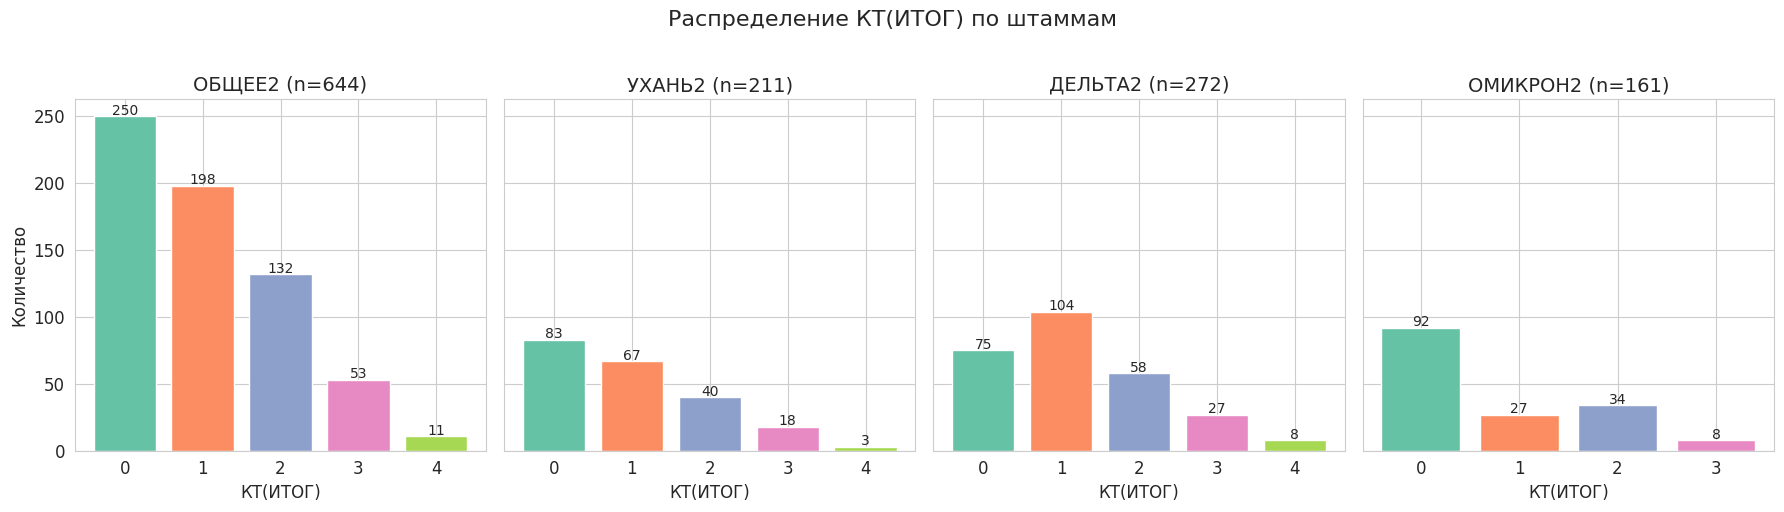

In [7]:
target_col = datasets['ОБЩЕЕ2'].columns[-1]  # КТ(ИТОГ)
feature_cols = datasets['ОБЩЕЕ2'].columns[:-1]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, name in zip(axes, SHEET_NAMES):
    df = datasets[name]
    counts = df[target_col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette('Set2', 5))
    ax.set_title(f'{name} (n={len(df)})', fontsize=14)
    ax.set_xlabel('КТ(ИТОГ)')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)
axes[0].set_ylabel('Количество')
fig.suptitle('Распределение КТ(ИТОГ) по штаммам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Матрицы корреляций

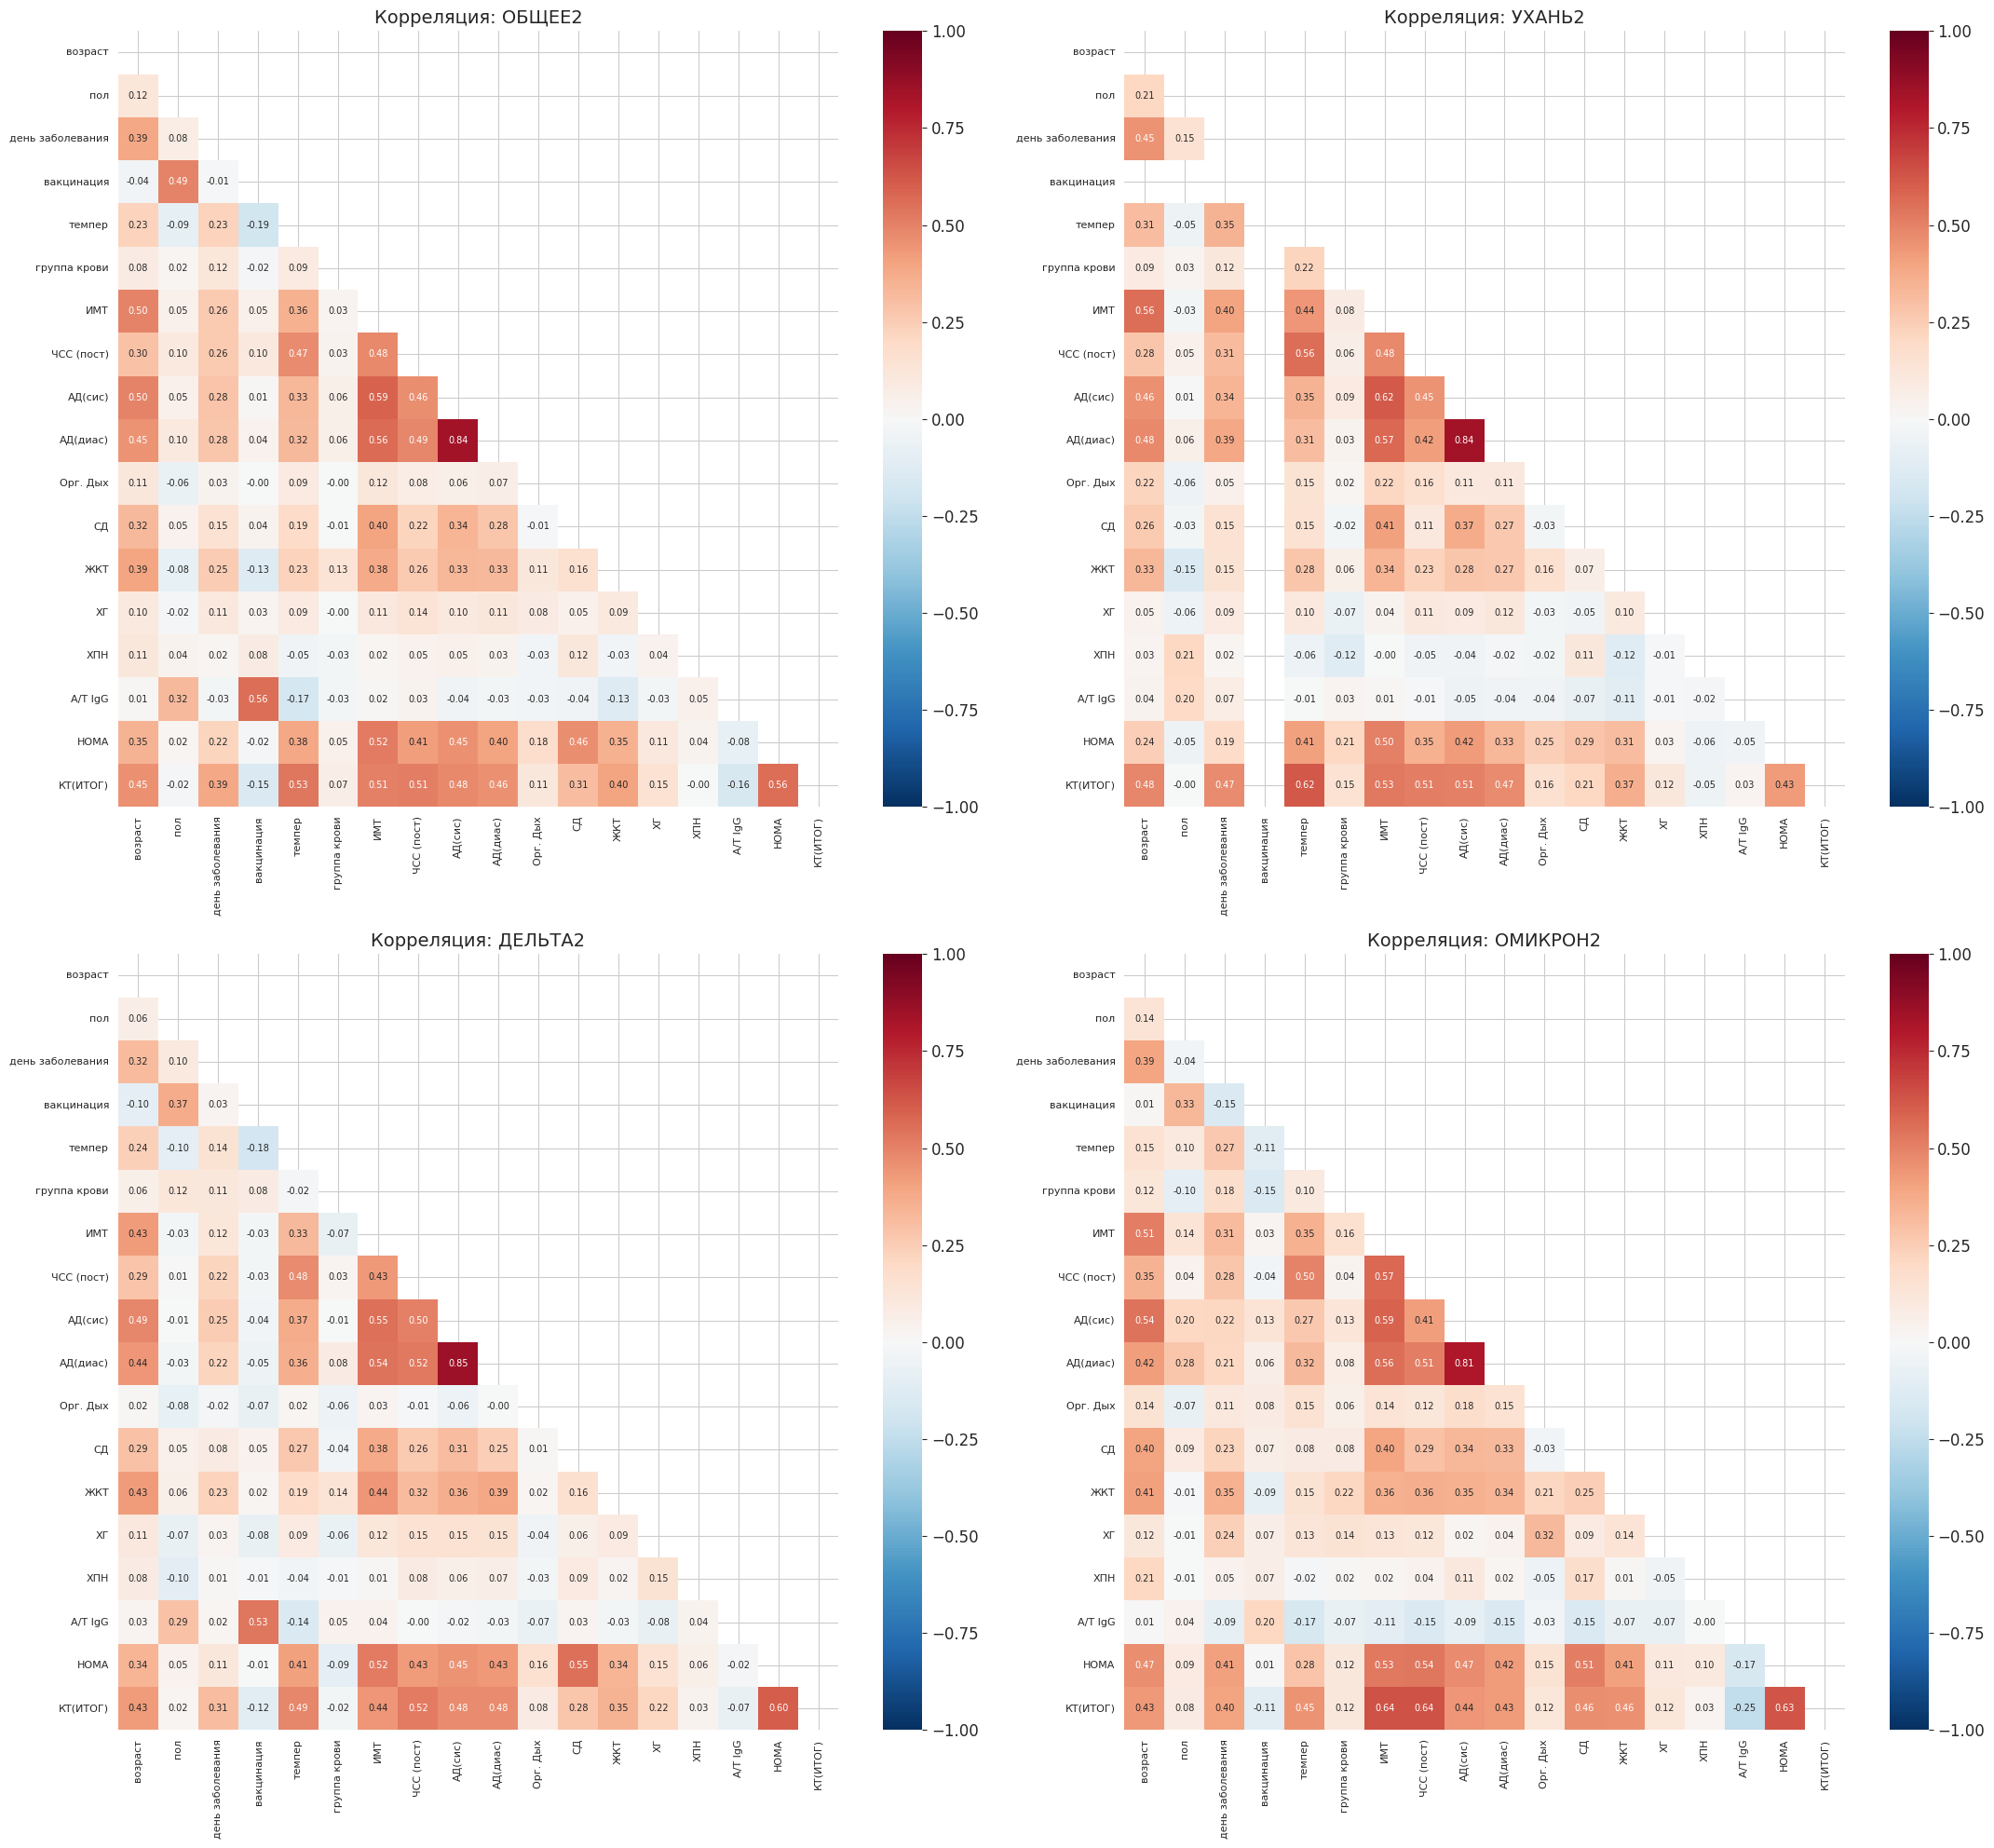

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(22, 20))
for ax, name in zip(axes.flatten(), SHEET_NAMES):
    corr = datasets[name].corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7},
                xticklabels=True, yticklabels=True)
    ax.set_title(f'Корреляция: {name}', fontsize=14)
    ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

### 3.3 Boxplot-ы признаков в разрезе КТ(ИТОГ)

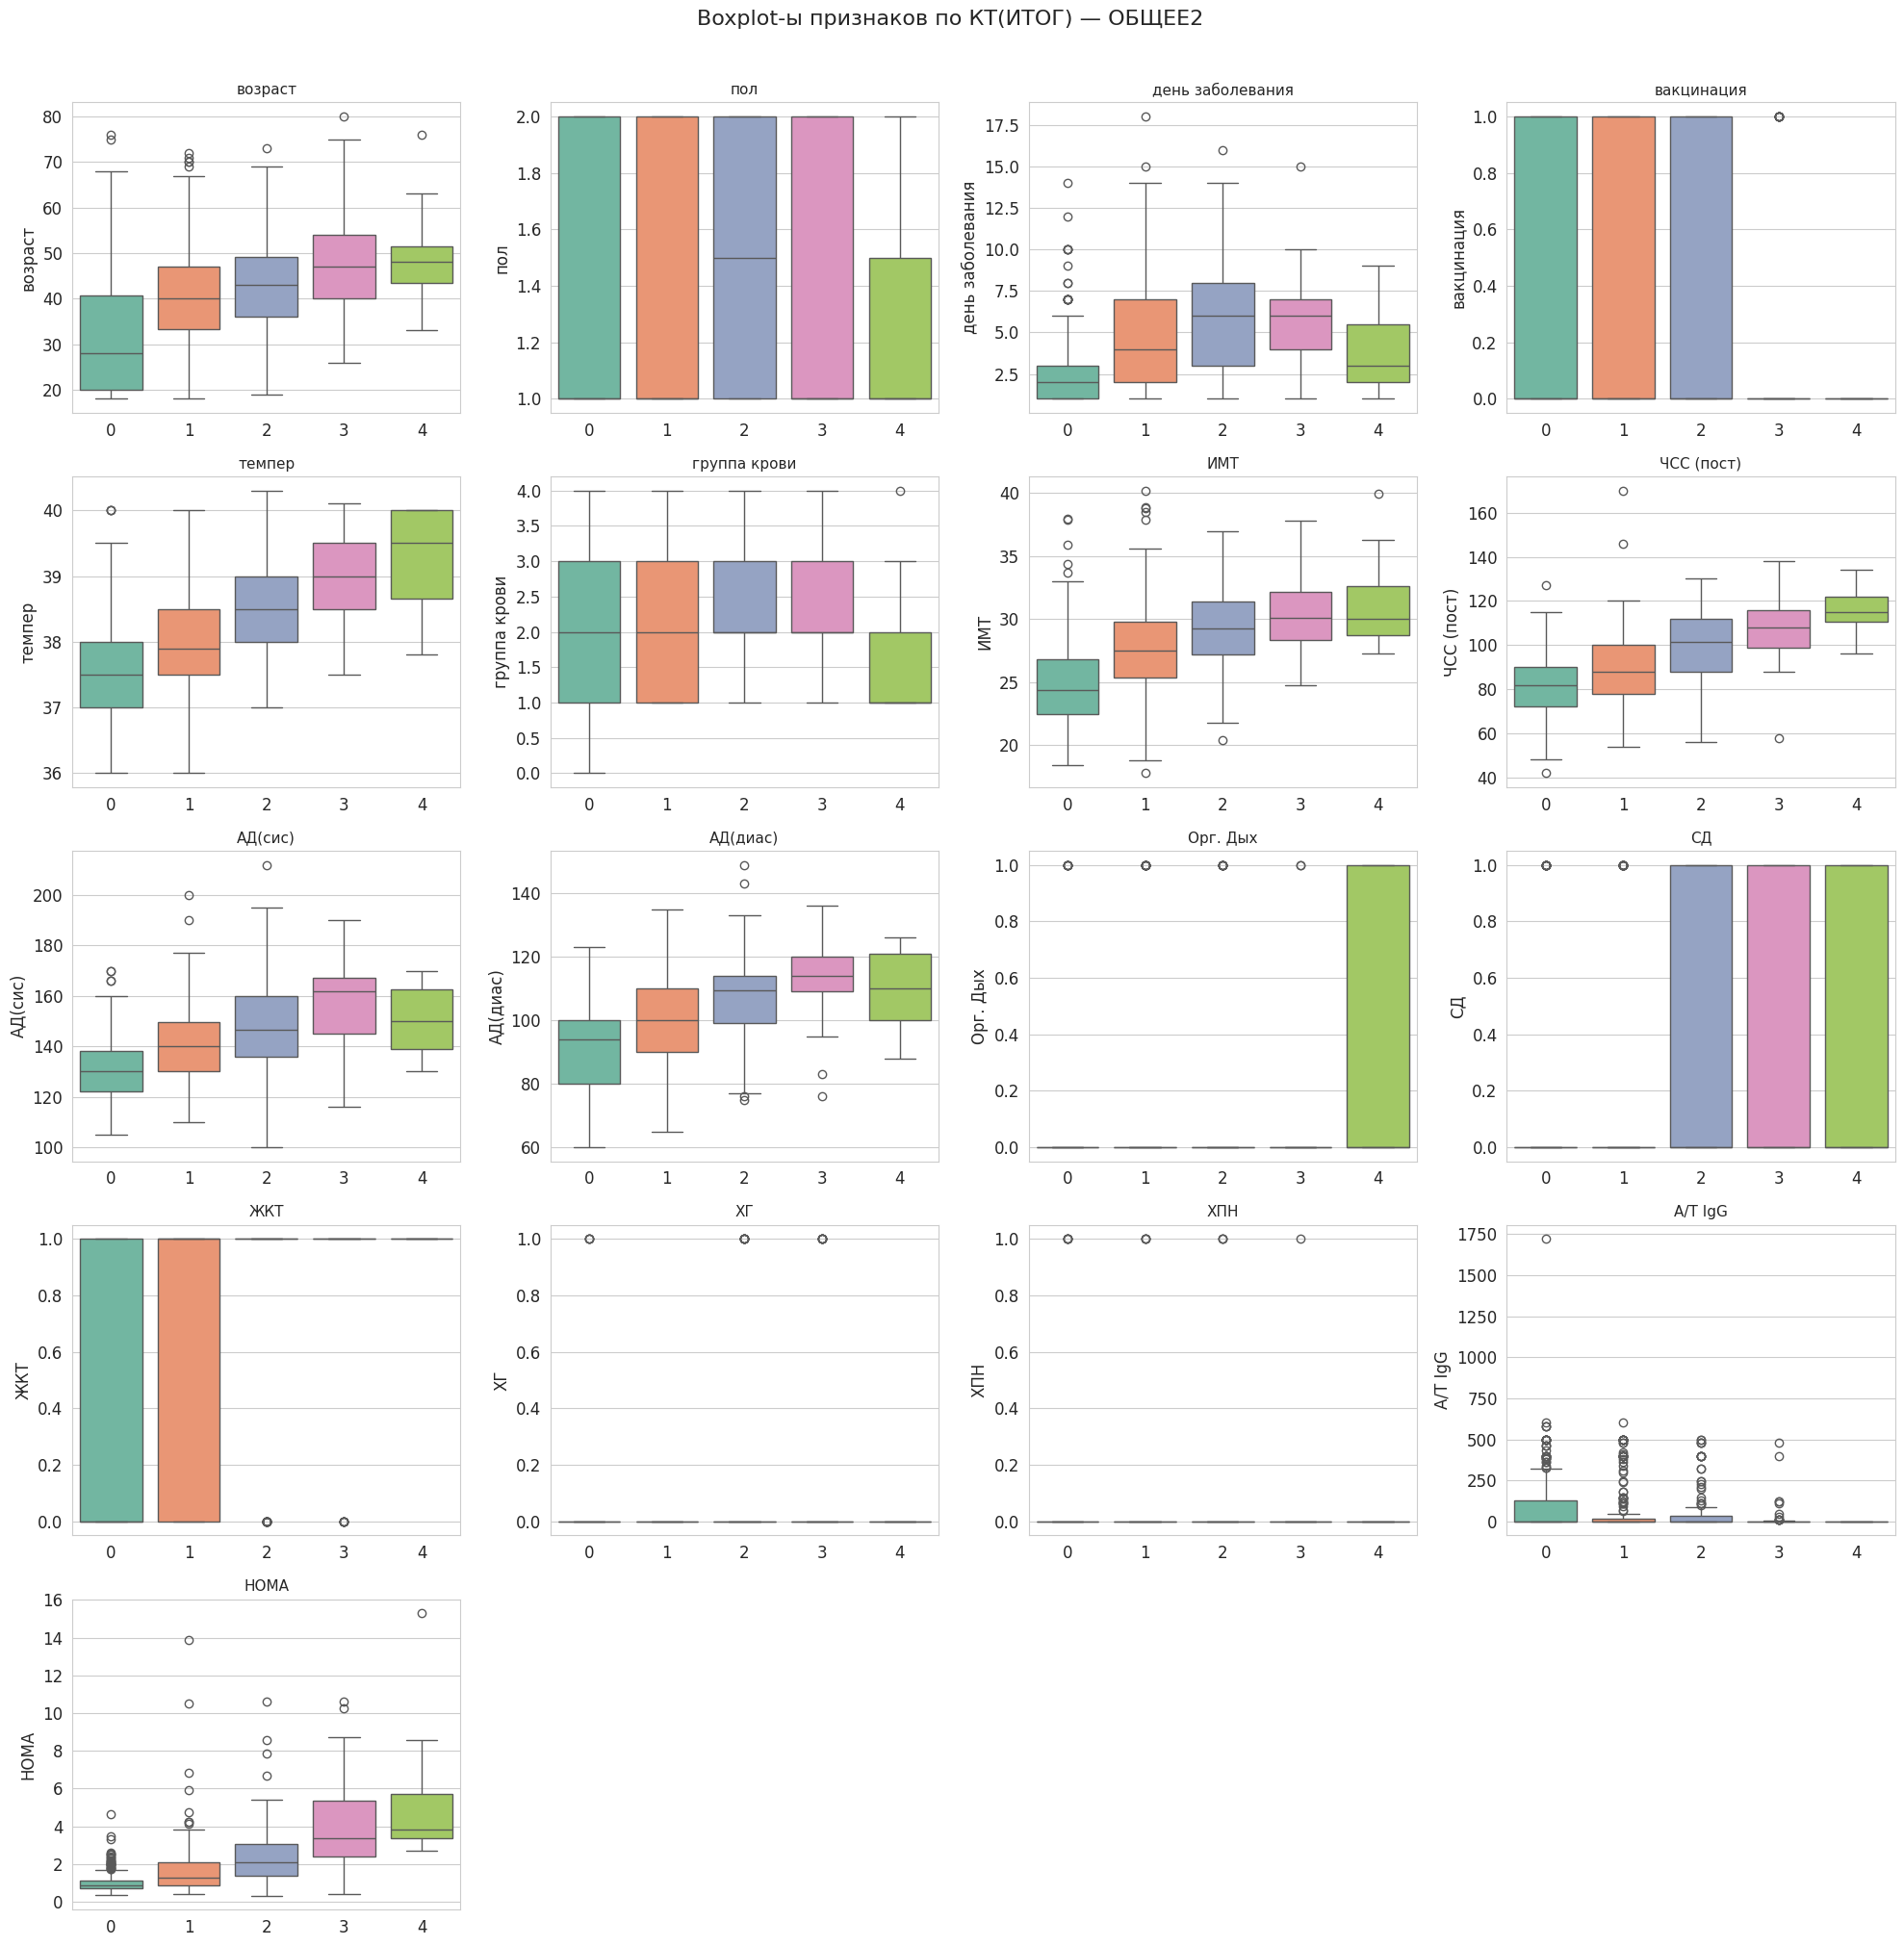

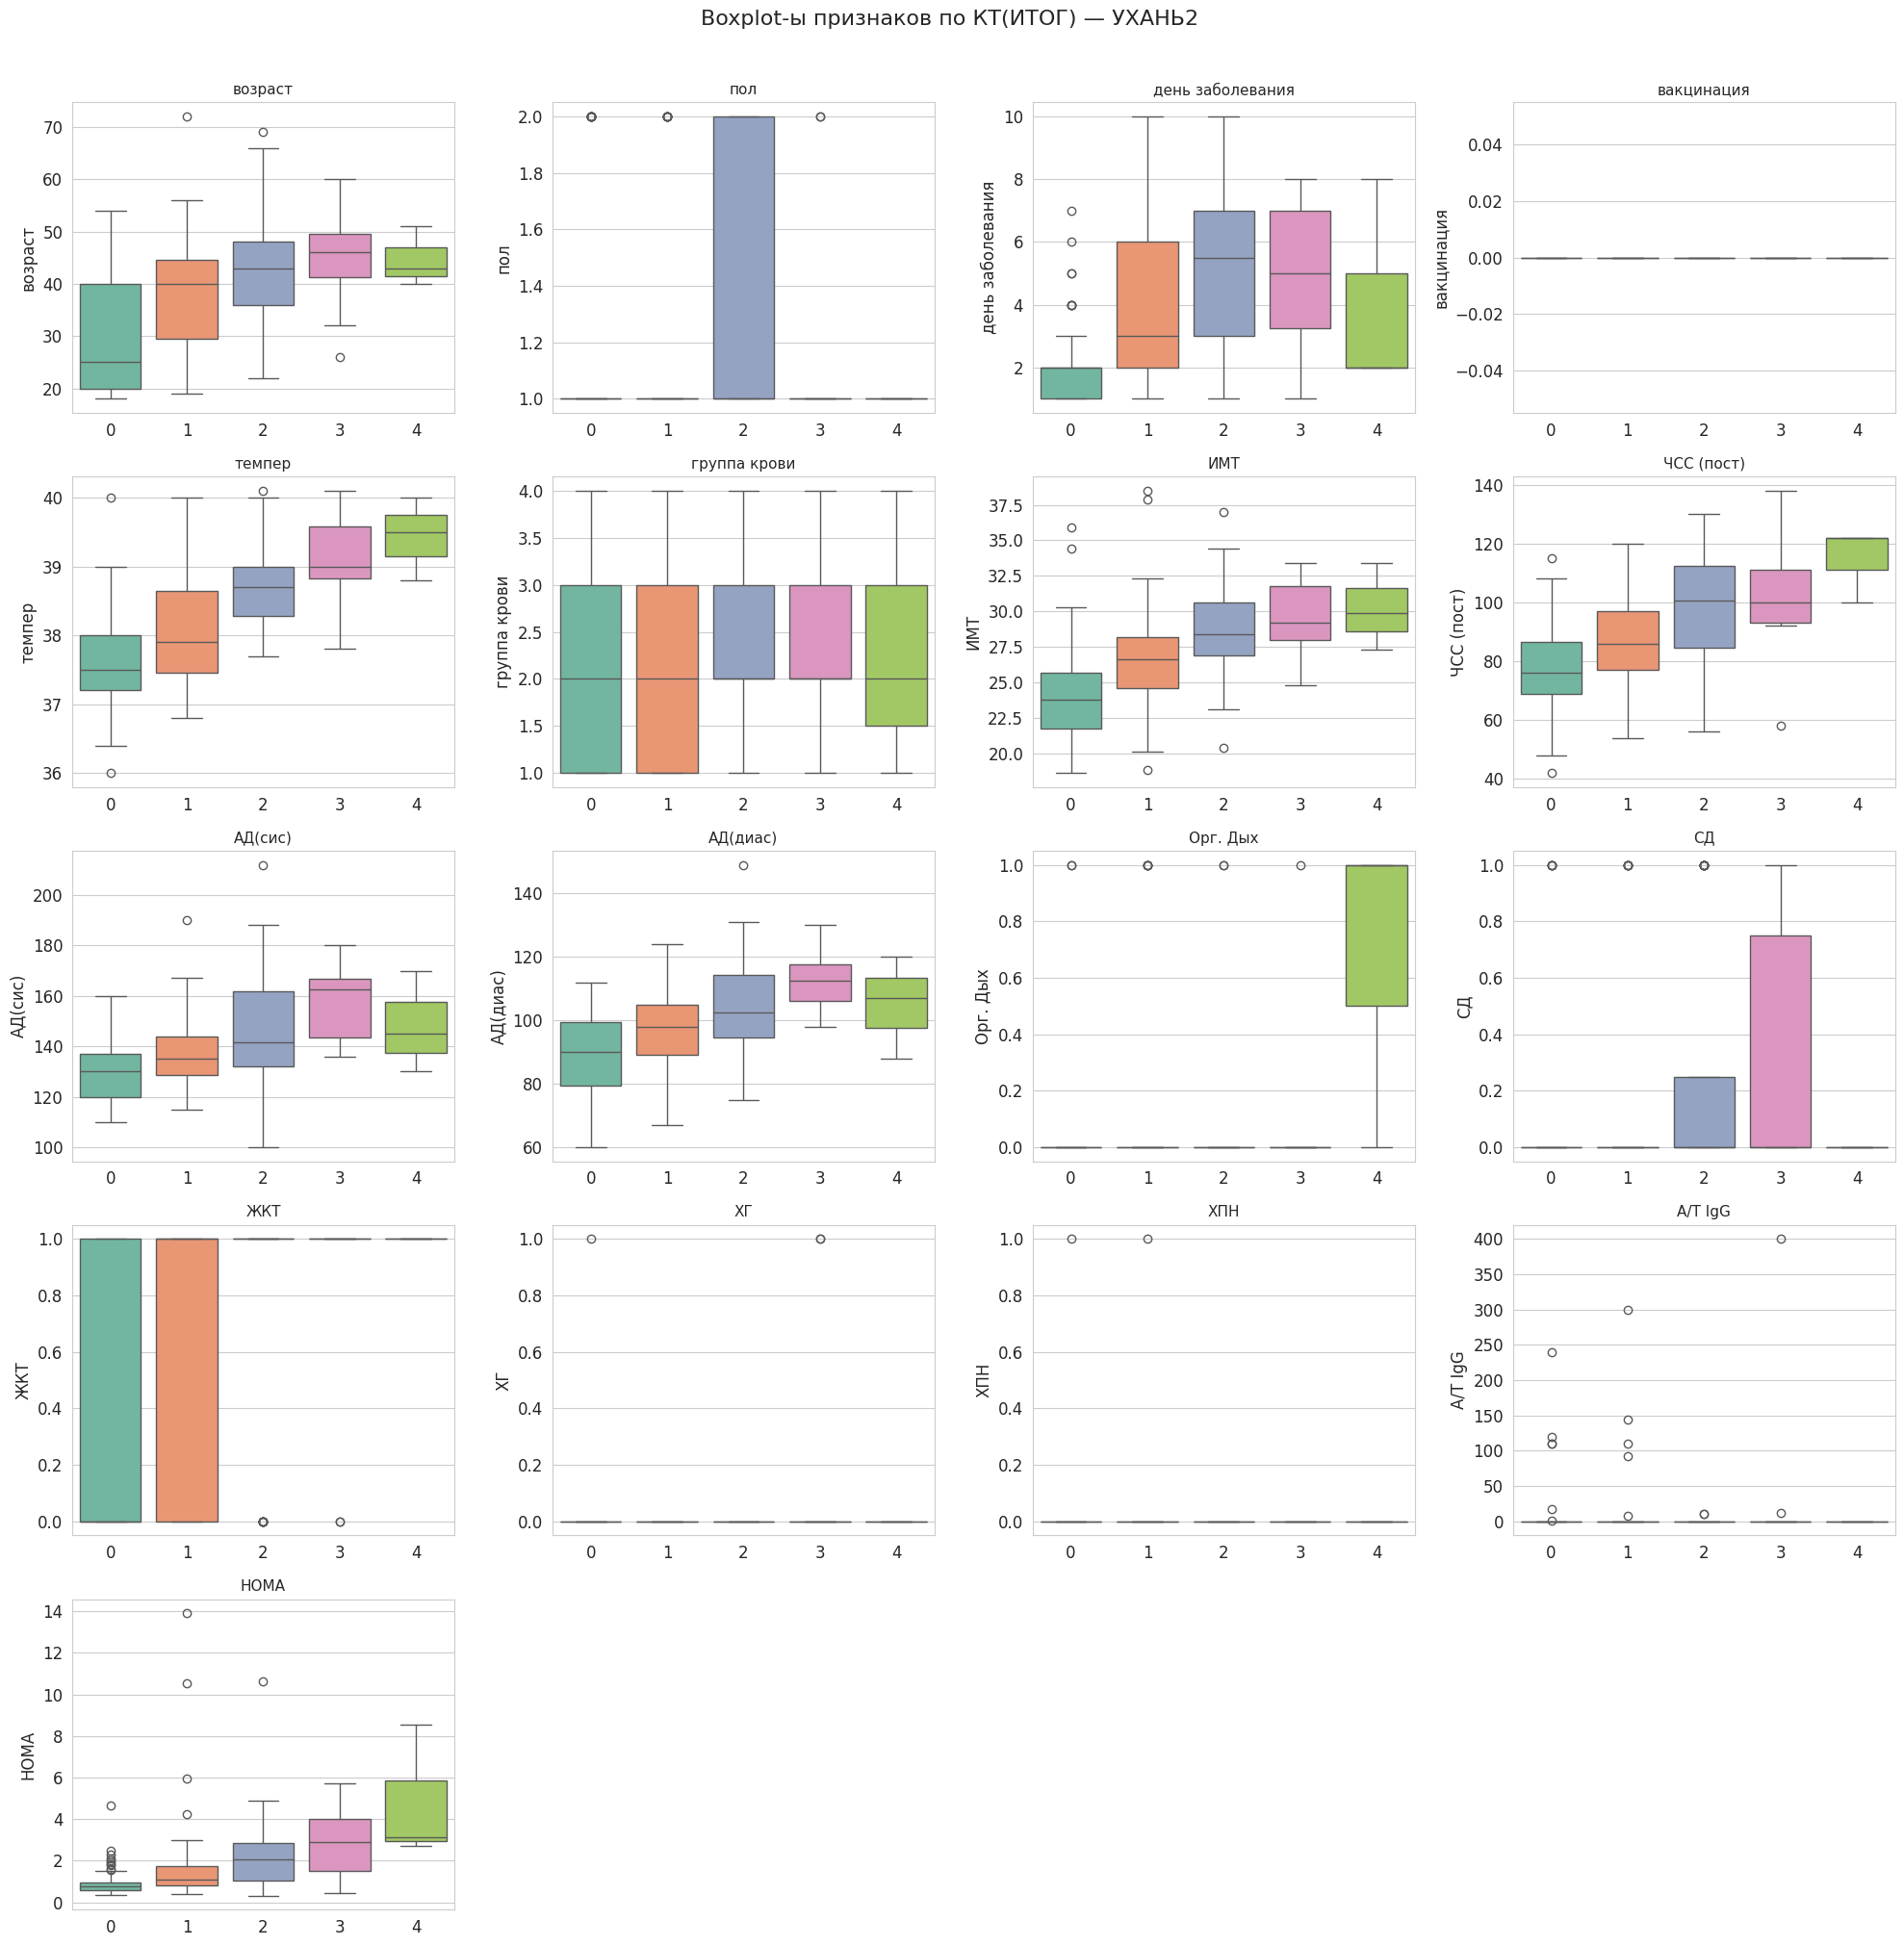

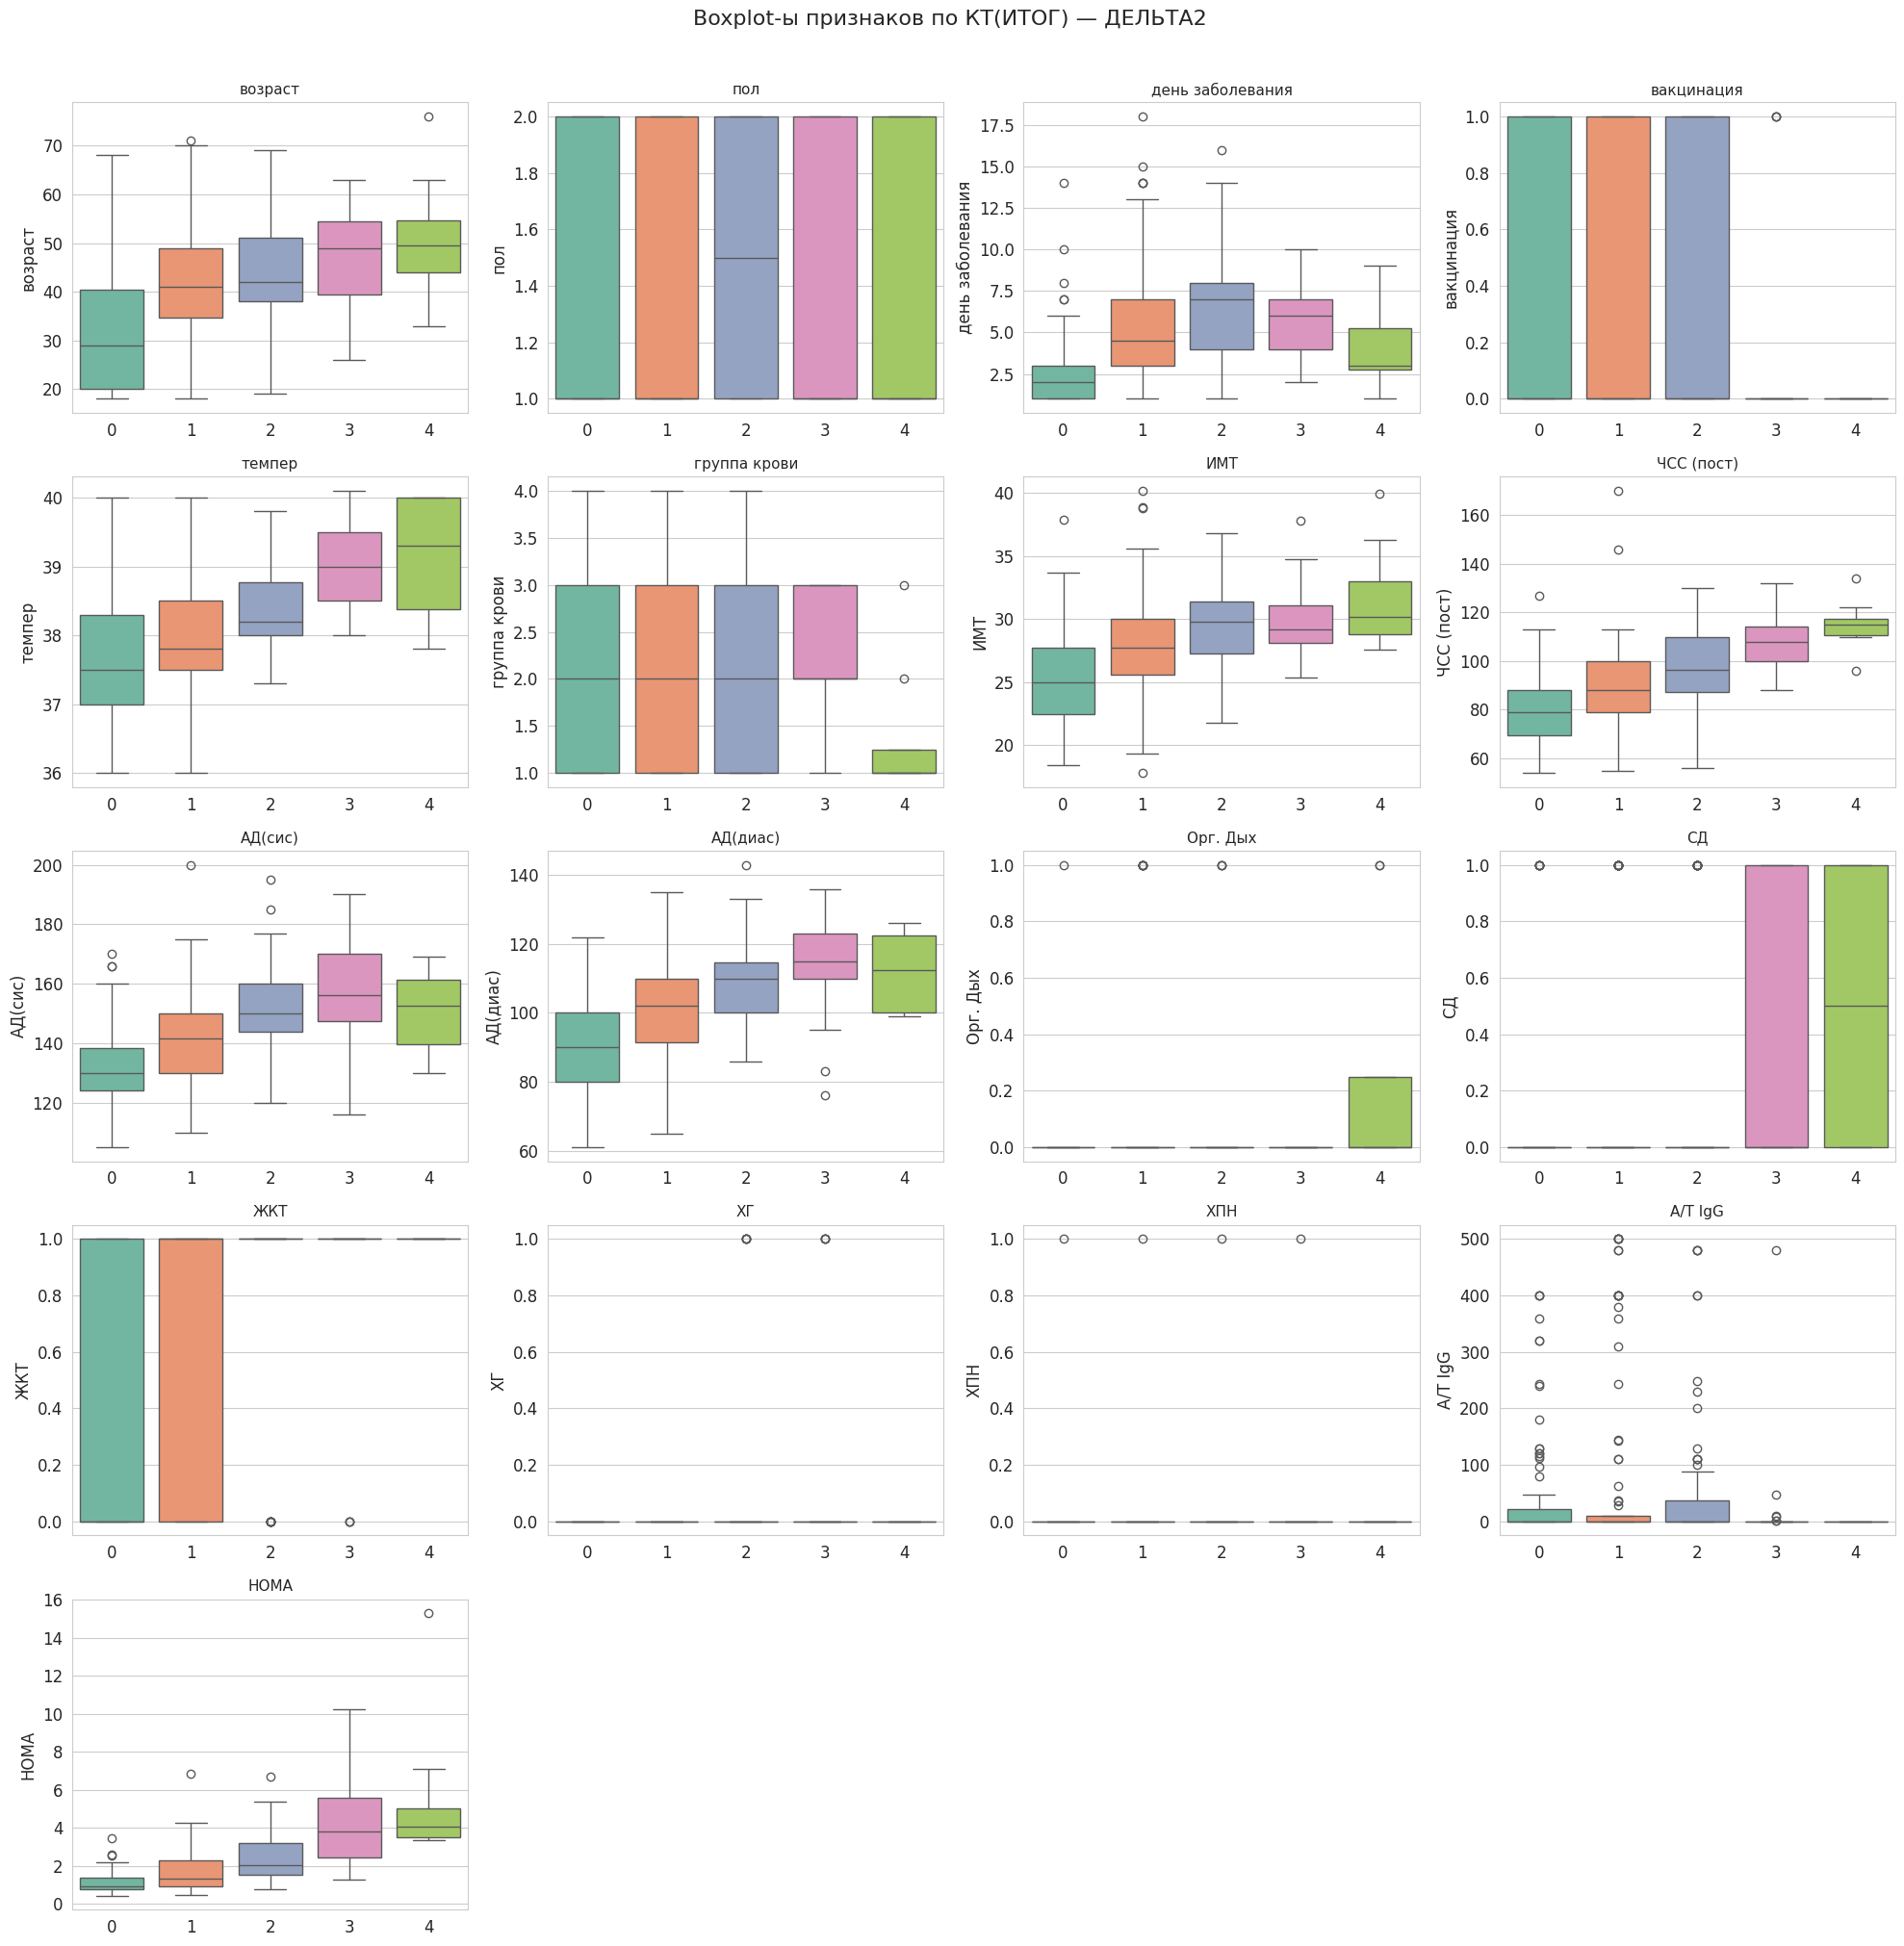

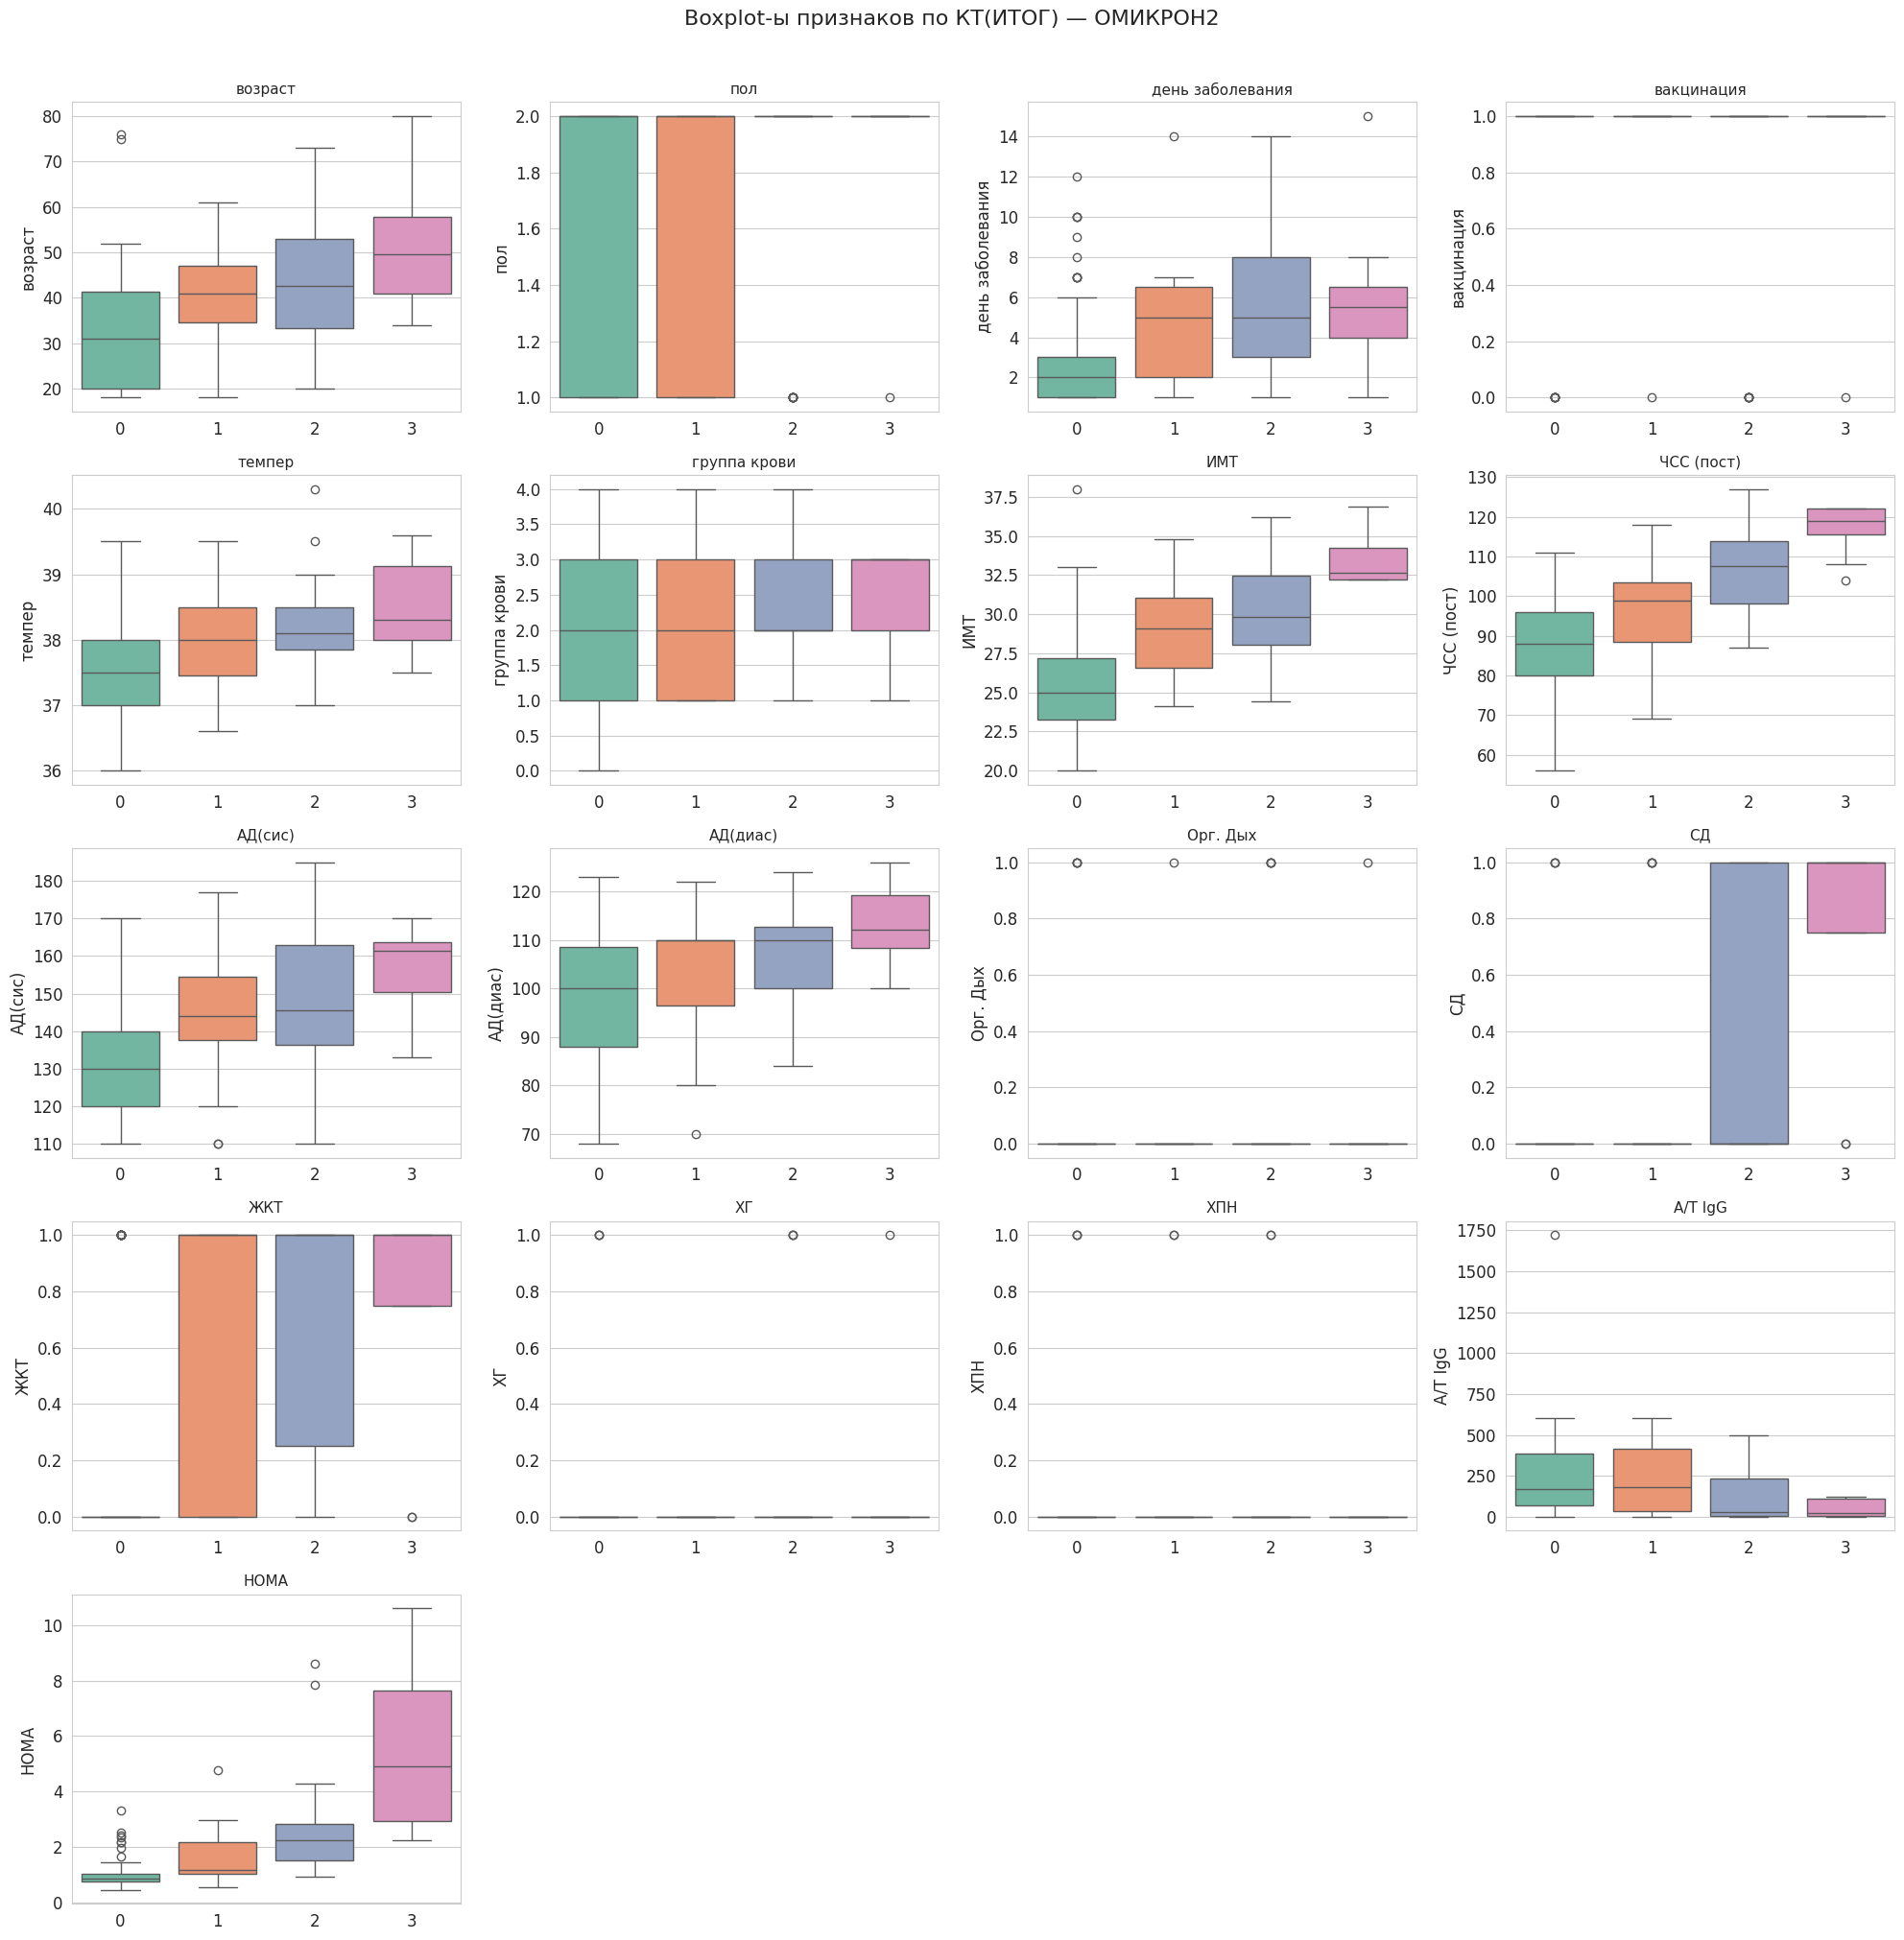

In [9]:
for name in SHEET_NAMES:
    df = datasets[name]
    n_features = len(feature_cols)
    n_cols = 4
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    fig.suptitle(f'Boxplot-ы признаков по КТ(ИТОГ) — {name}', fontsize=16, y=1.01)

    for i, feat in enumerate(feature_cols):
        ax = axes.flatten()[i]
        sns.boxplot(data=df, x=target_col, y=feat, ax=ax, palette='Set2')
        ax.set_title(feat, fontsize=11)
        ax.set_xlabel('')

    # Скрыть пустые подграфики
    for j in range(i + 1, len(axes.flatten())):
        axes.flatten()[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 3.4 Гистограммы распределений признаков

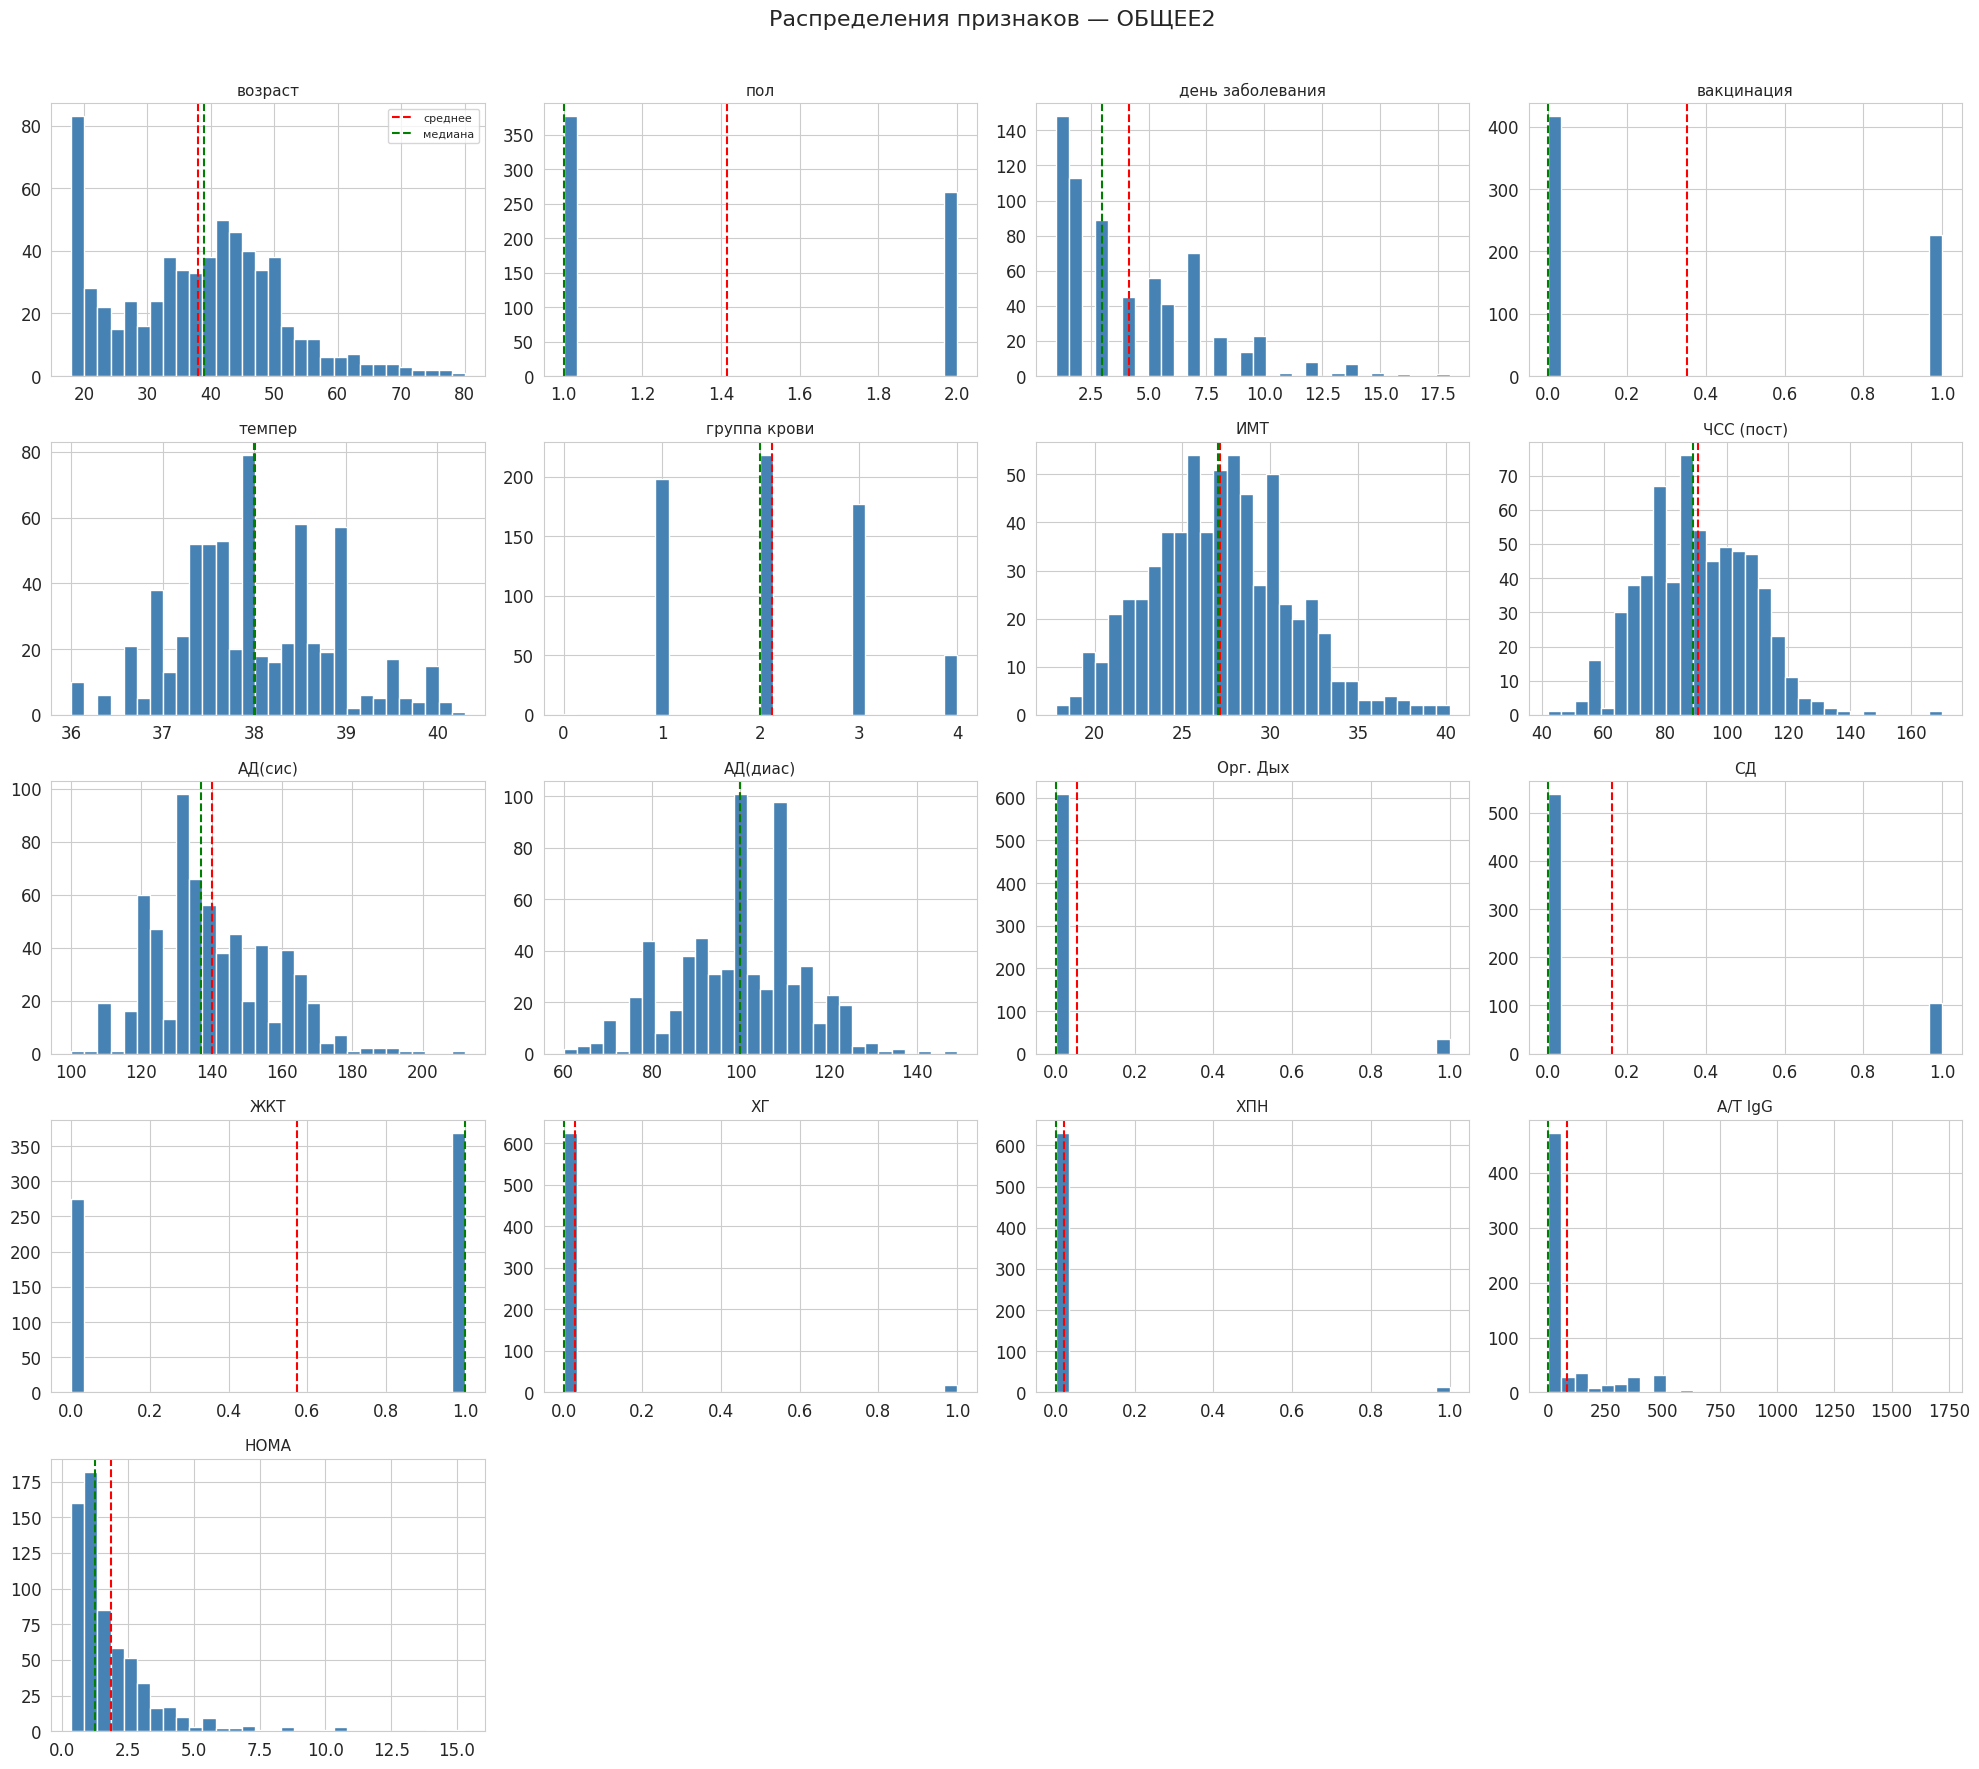

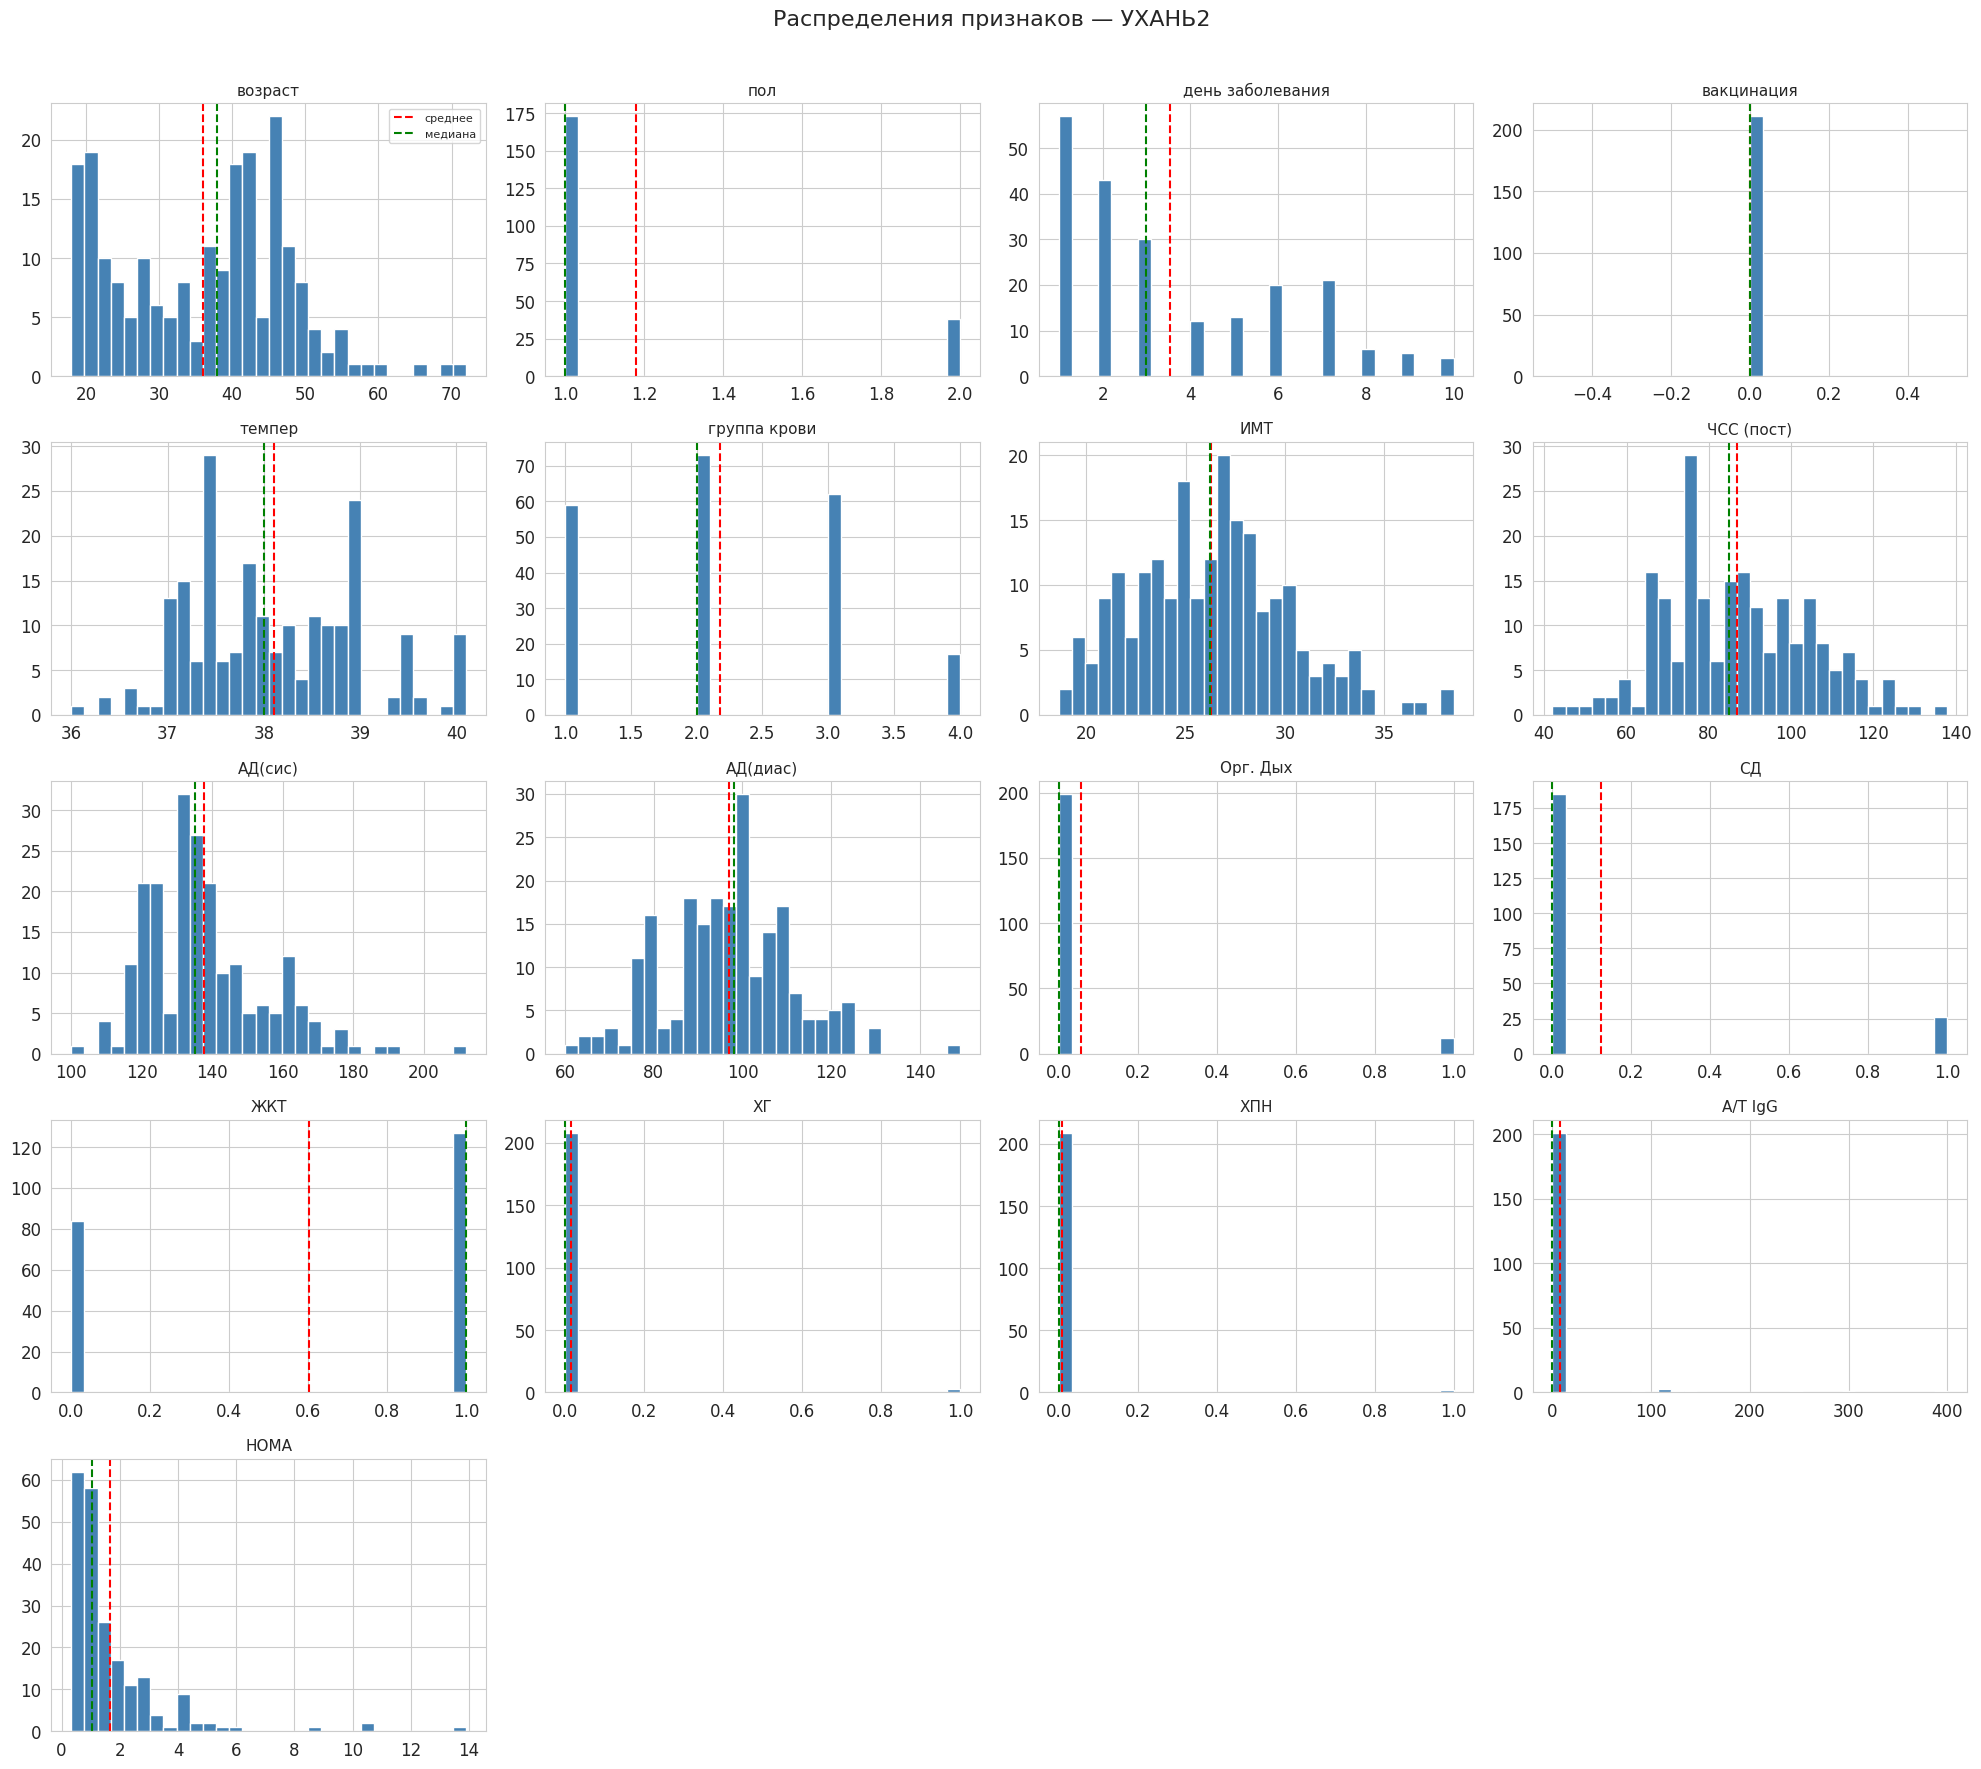

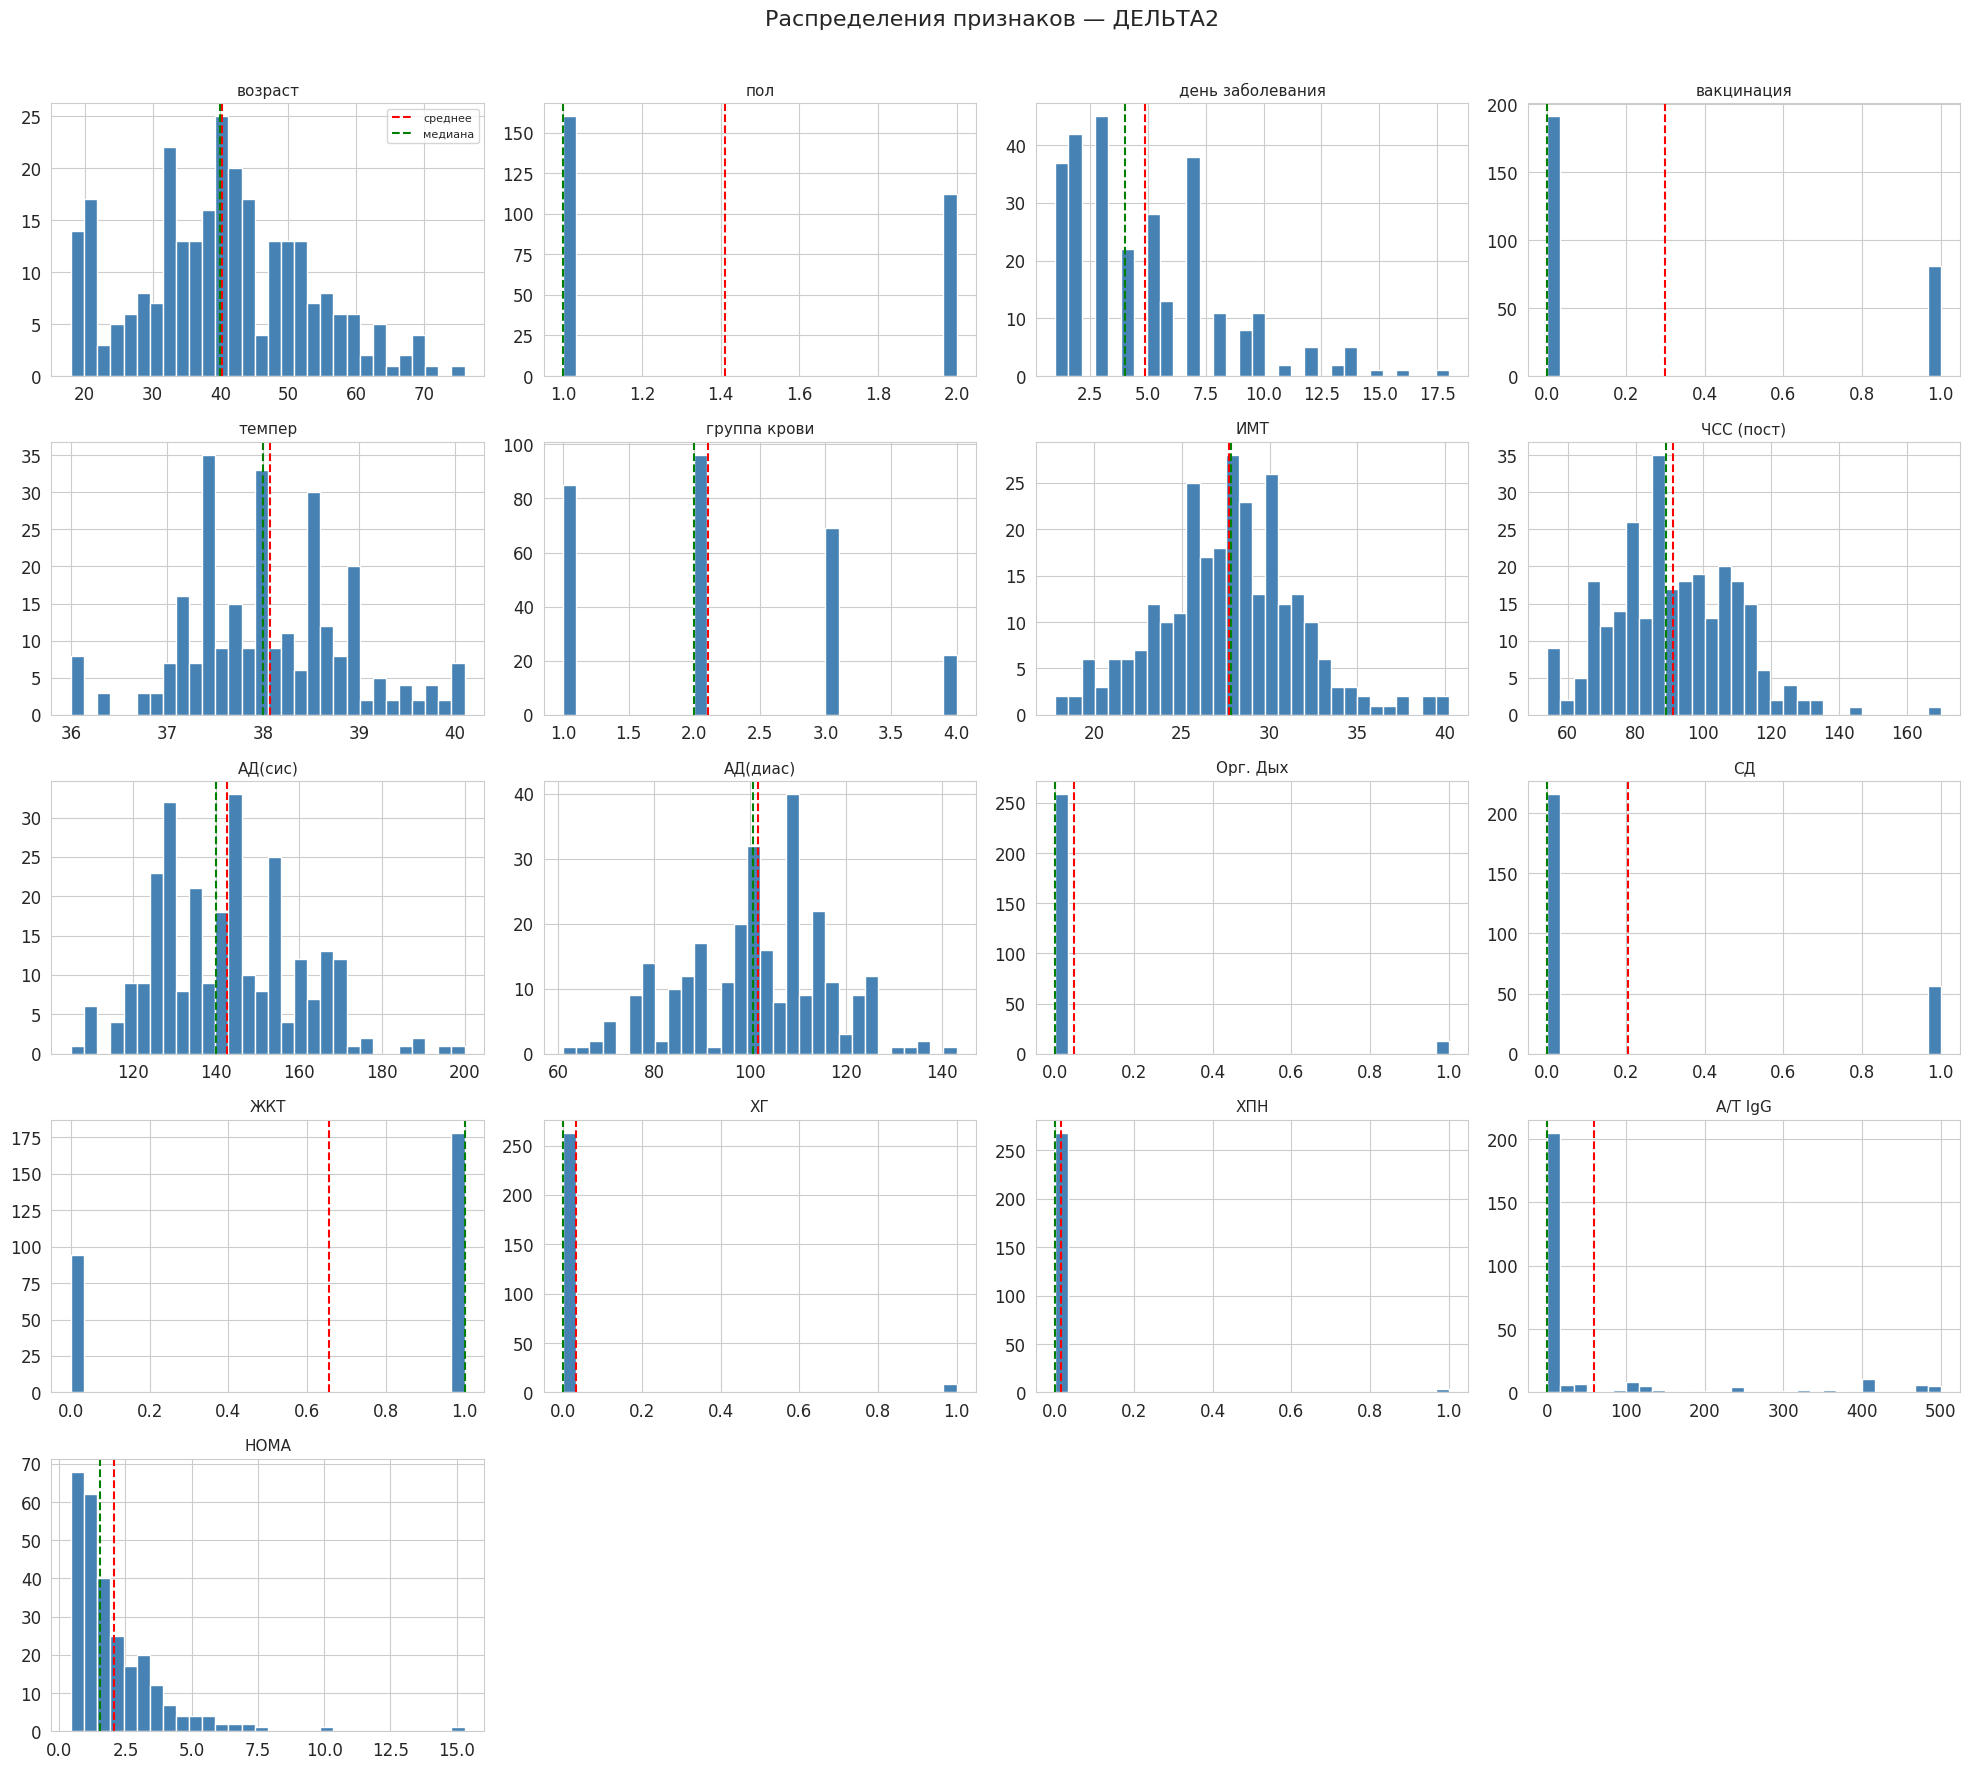

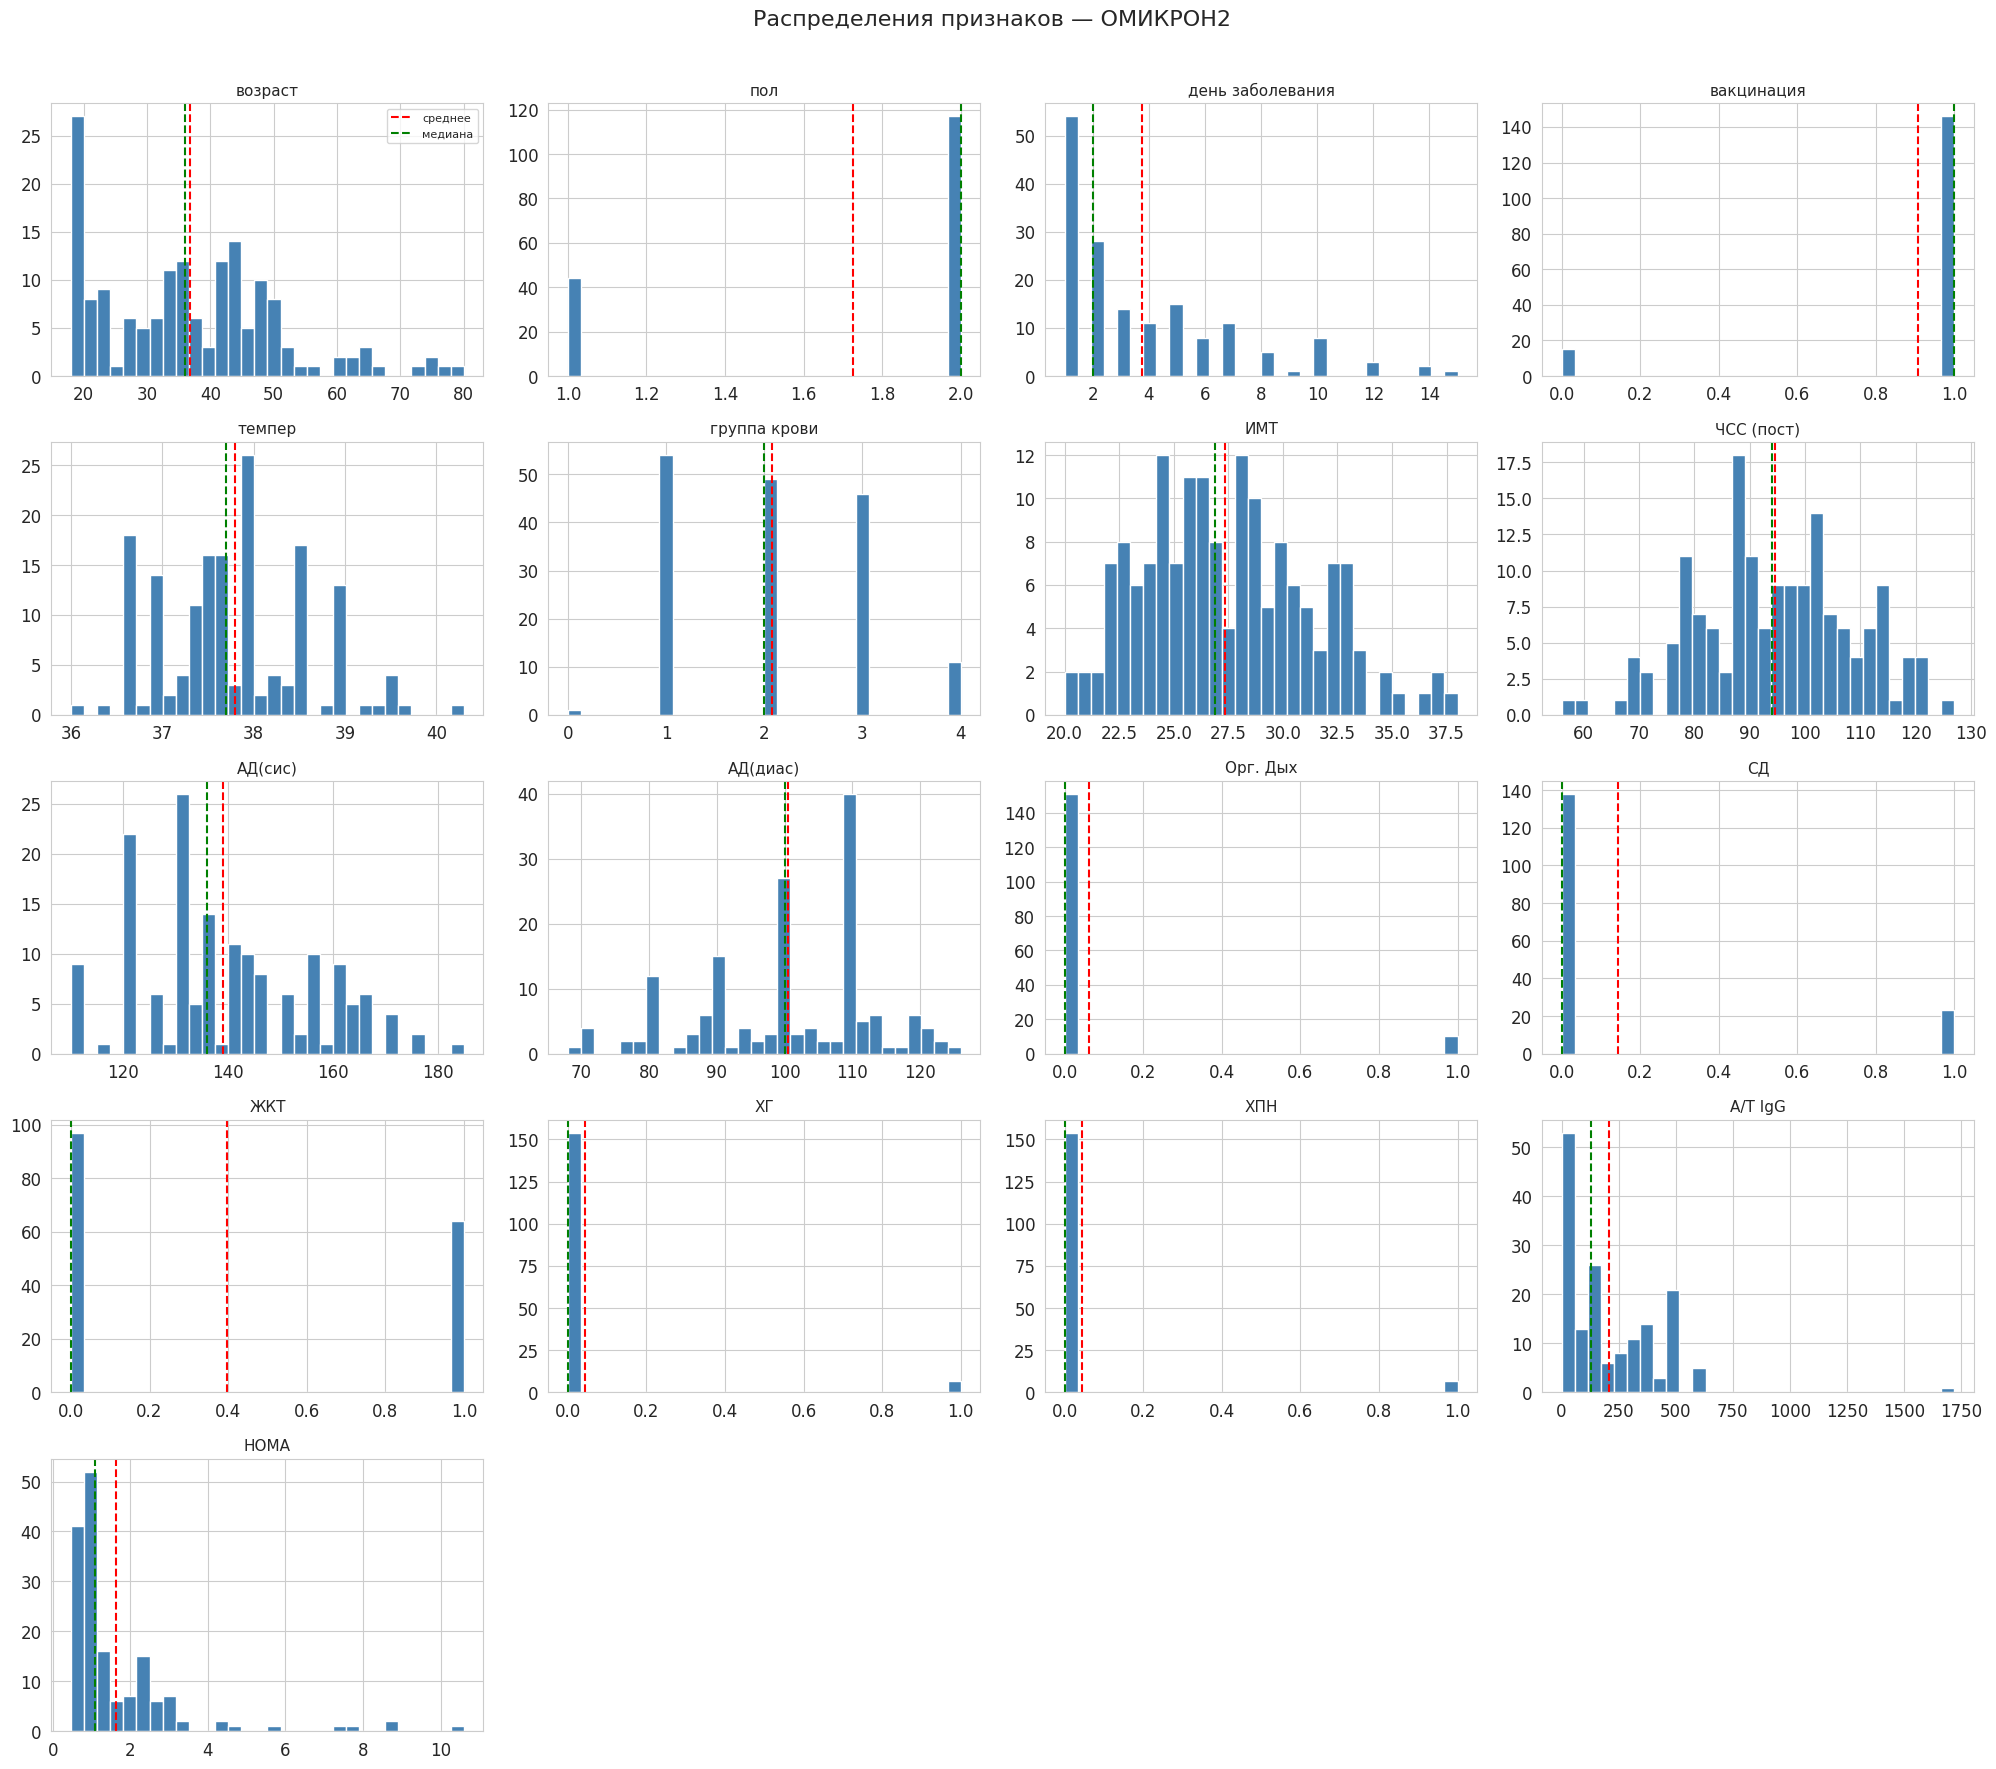

In [10]:
for name in SHEET_NAMES:
    df = datasets[name]
    n_cols = 4
    n_rows = (len(feature_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
    fig.suptitle(f'Распределения признаков — {name}', fontsize=16, y=1.01)

    for i, feat in enumerate(feature_cols):
        ax = axes.flatten()[i]
        df[feat].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(feat, fontsize=11)
        ax.axvline(df[feat].mean(), color='red', linestyle='--', label='среднее')
        ax.axvline(df[feat].median(), color='green', linestyle='--', label='медиана')
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(i + 1, len(axes.flatten())):
        axes.flatten()[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 3.5 Сравнительная таблица средних по штаммам

,ОБЩЕЕ2,УХАНЬ2,ДЕЛЬТА2,ОМИКРОН2
возраст,37.99,35.96,40.31,36.73
пол,1.41,1.18,1.41,1.73
день заболевания,4.15,3.54,4.87,3.75
вакцинация,0.35,0.00,0.30,0.91
темпер,38.01,38.11,38.07,37.79
группа крови,2.12,2.18,2.10,2.07
ИМТ,27.16,26.29,27.71,27.37
ЧСС (пост),90.60,86.82,91.18,94.60
АД(сис),140.12,137.73,142.64,138.97
АД(диас),99.79,96.95,101.52,100.58


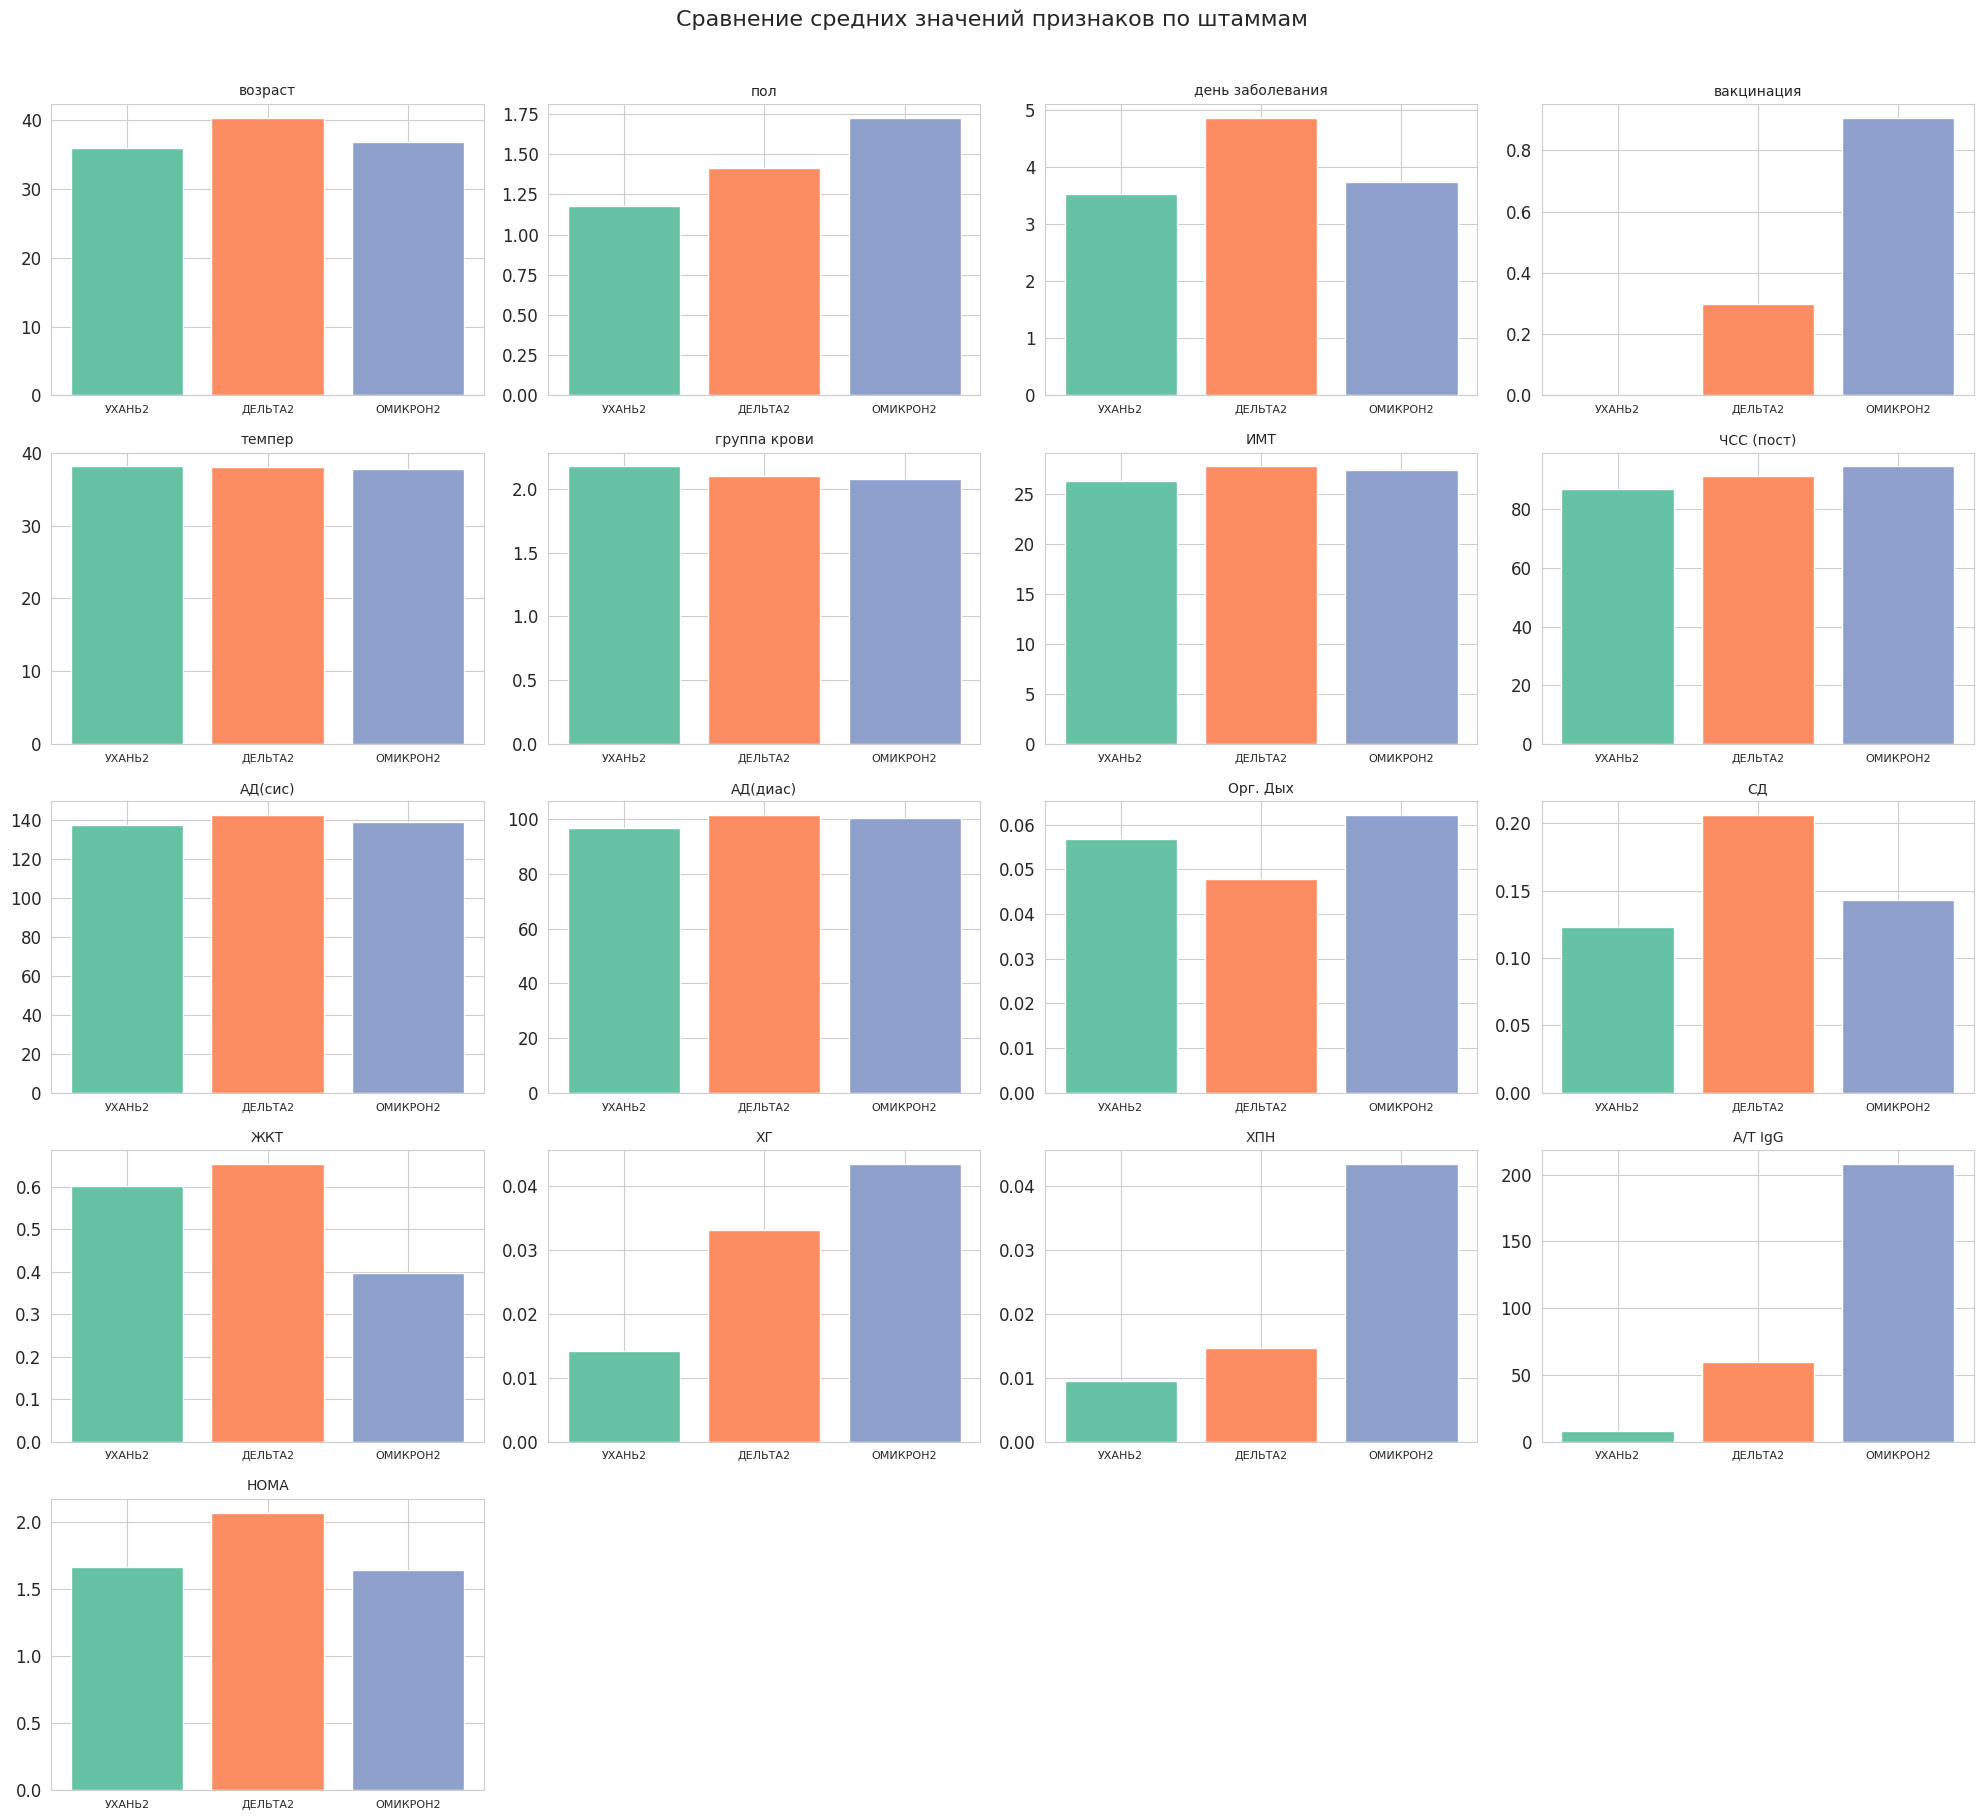

In [11]:
# Сравнение средних значений признаков между штаммами
means = pd.DataFrame({name: datasets[name][feature_cols].mean() for name in SHEET_NAMES})
display(means.round(2))

# Визуализация
fig, axes = plt.subplots(5, 4, figsize=(20, 18))
fig.suptitle('Сравнение средних значений признаков по штаммам', fontsize=16, y=1.01)
strain_names = ['УХАНЬ2', 'ДЕЛЬТА2', 'ОМИКРОН2']
colors = sns.color_palette('Set2', 3)

for i, feat in enumerate(feature_cols):
    ax = axes.flatten()[i]
    vals = [datasets[s][feat].mean() for s in strain_names]
    ax.bar(strain_names, vals, color=colors)
    ax.set_title(feat, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)

for j in range(i + 1, len(axes.flatten())):
    axes.flatten()[j].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Подготовка данных к моделированию

In [12]:
# Заполнение пропусков медианой (по train) и разделение на train/test
splits = {}

for name in SHEET_NAMES:
    df = datasets[name].copy()

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # Удаление строк, где целевая переменная пропущена
    mask = y.notna()
    X, y = X[mask], y[mask].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # Заполнение пропусков медианой ТОЛЬКО по обучающей выборке
    train_median = X_train.median()
    X_train = X_train.fillna(train_median)
    X_test = X_test.fillna(train_median)

    splits[name] = (X_train, X_test, y_train, y_test)
    print(f"{name:>10s}: train={len(X_train)}, test={len(X_test)}, "
          f"классы в train: {dict(y_train.value_counts().sort_index())}")

    ОБЩЕЕ2: train=515, test=129, классы в train: {0: np.int64(200), 1: np.int64(158), 2: np.int64(106), 3: np.int64(42), 4: np.int64(9)}
    УХАНЬ2: train=168, test=43, классы в train: {0: np.int64(66), 1: np.int64(53), 2: np.int64(32), 3: np.int64(14), 4: np.int64(3)}
   ДЕЛЬТА2: train=217, test=55, классы в train: {0: np.int64(60), 1: np.int64(83), 2: np.int64(46), 3: np.int64(22), 4: np.int64(6)}
  ОМИКРОН2: train=128, test=33, классы в train: {0: np.int64(73), 1: np.int64(22), 2: np.int64(27), 3: np.int64(6)}


## 5. Деревья решений — обучение и оценка

In [13]:
# Подбор гиперпараметров и обучение деревьев решений
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [5, 10, 15, 20],
    'min_samples_split': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

best_models = {}
results_summary = []

for name in SHEET_NAMES:
    print(f"\n{'='*60}")
    print(f"  Дерево решений: {name}")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test = splits[name]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        param_grid,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    print(f"\nЛучшие параметры: {grid.best_params_}")
    print(f"Лучший F1 (CV): {grid.best_score_:.4f}")

    # Предсказание на тесте
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')

    print(f"\nТестовые метрики:")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  F1 (weighted):   {f1_w:.4f}")
    print(f"  F1 (macro):      {f1_m:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    results_summary.append({
        'Accuracy (test)': round(acc, 4),
        'F1 test (weighted)': round(f1_w, 4),
        'F1 test (macro)': round(f1_m, 4)
    })


  Дерево решений: ОБЩЕЕ2



Лучшие параметры: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 5}
Лучший F1 (CV): 0.4698

Тестовые метрики:
  Accuracy:        0.4496
  F1 (weighted):   0.4607
  F1 (macro):      0.3232

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68        50
           1       0.39      0.30      0.34        40
           2       0.42      0.31      0.36        26
           3       0.18      0.36      0.24        11
           4       0.00      0.00      0.00         2

    accuracy                           0.45       129
   macro avg       0.33      0.33      0.32       129
weighted avg       0.48      0.45      0.46       129


  Дерево решений: УХАНЬ2



Лучшие параметры: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 5}
Лучший F1 (CV): 0.4634

Тестовые метрики:
  Accuracy:        0.4651
  F1 (weighted):   0.5056
  F1 (macro):      0.3191

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.59      0.69        17
           1       0.50      0.43      0.46        14
           2       0.40      0.50      0.44         8
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         0

    accuracy                           0.47        43
   macro avg       0.35      0.30      0.32        43
weighted avg       0.57      0.47      0.51        43


  Дерево решений: ДЕЛЬТА2



Лучшие параметры: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 5}
Лучший F1 (CV): 0.4651

Тестовые метрики:
  Accuracy:        0.3091
  F1 (weighted):   0.2971
  F1 (macro):      0.2218

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.60      0.46        15
           1       0.38      0.24      0.29        21
           2       0.29      0.17      0.21        12
           3       0.11      0.20      0.14         5
           4       0.00      0.00      0.00         2

    accuracy                           0.31        55
   macro avg       0.23      0.24      0.22        55
weighted avg       0.32      0.31      0.30        55


  Дерево решений: ОМИКРОН2



Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5}
Лучший F1 (CV): 0.6144

Тестовые метрики:
  Accuracy:        0.6364
  F1 (weighted):   0.6528
  F1 (macro):      0.4918

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82        19
           1       0.25      0.20      0.22         5
           2       0.50      0.71      0.59         7
           3       0.25      0.50      0.33         2

    accuracy                           0.64        33
   macro avg       0.48      0.54      0.49        33
weighted avg       0.70      0.64      0.65        33



### 5.1 Матрицы ошибок (Decision Tree)

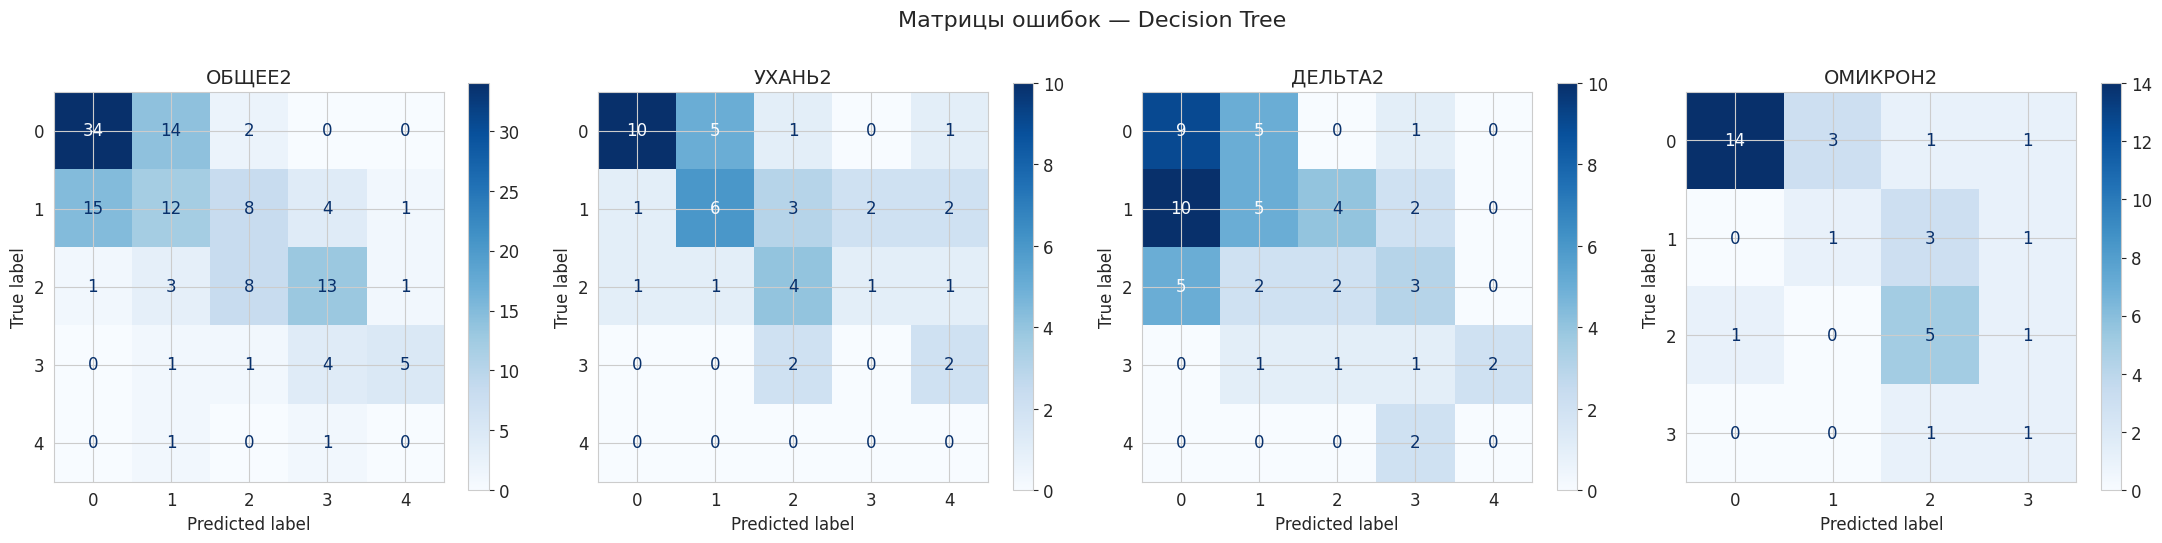

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, SHEET_NAMES):
    X_train, X_test, y_train, y_test = splits[name]
    y_pred = best_models[name].predict(X_test)
    all_labels = sorted(set(y_train.unique()) | set(y_test.unique()))
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    ConfusionMatrixDisplay(cm, display_labels=all_labels).plot(ax=ax, cmap='Blues')
    ax.set_title(f'{name}', fontsize=14)
fig.suptitle('Матрицы ошибок — Decision Tree', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Визуализация деревьев решений

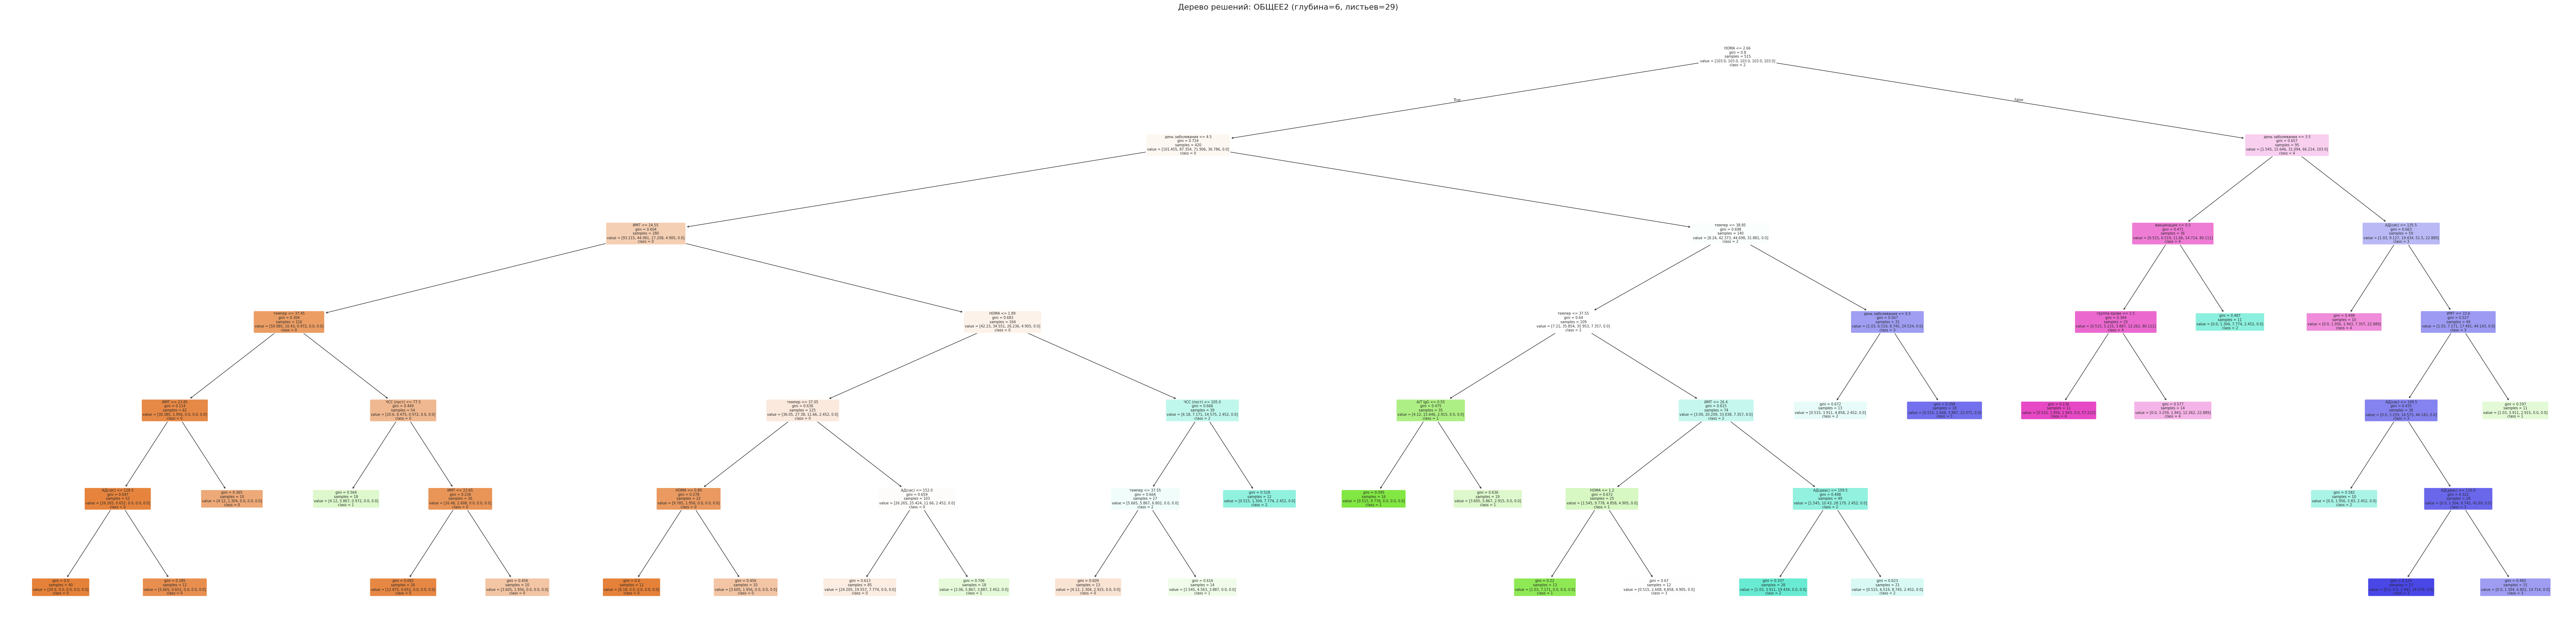

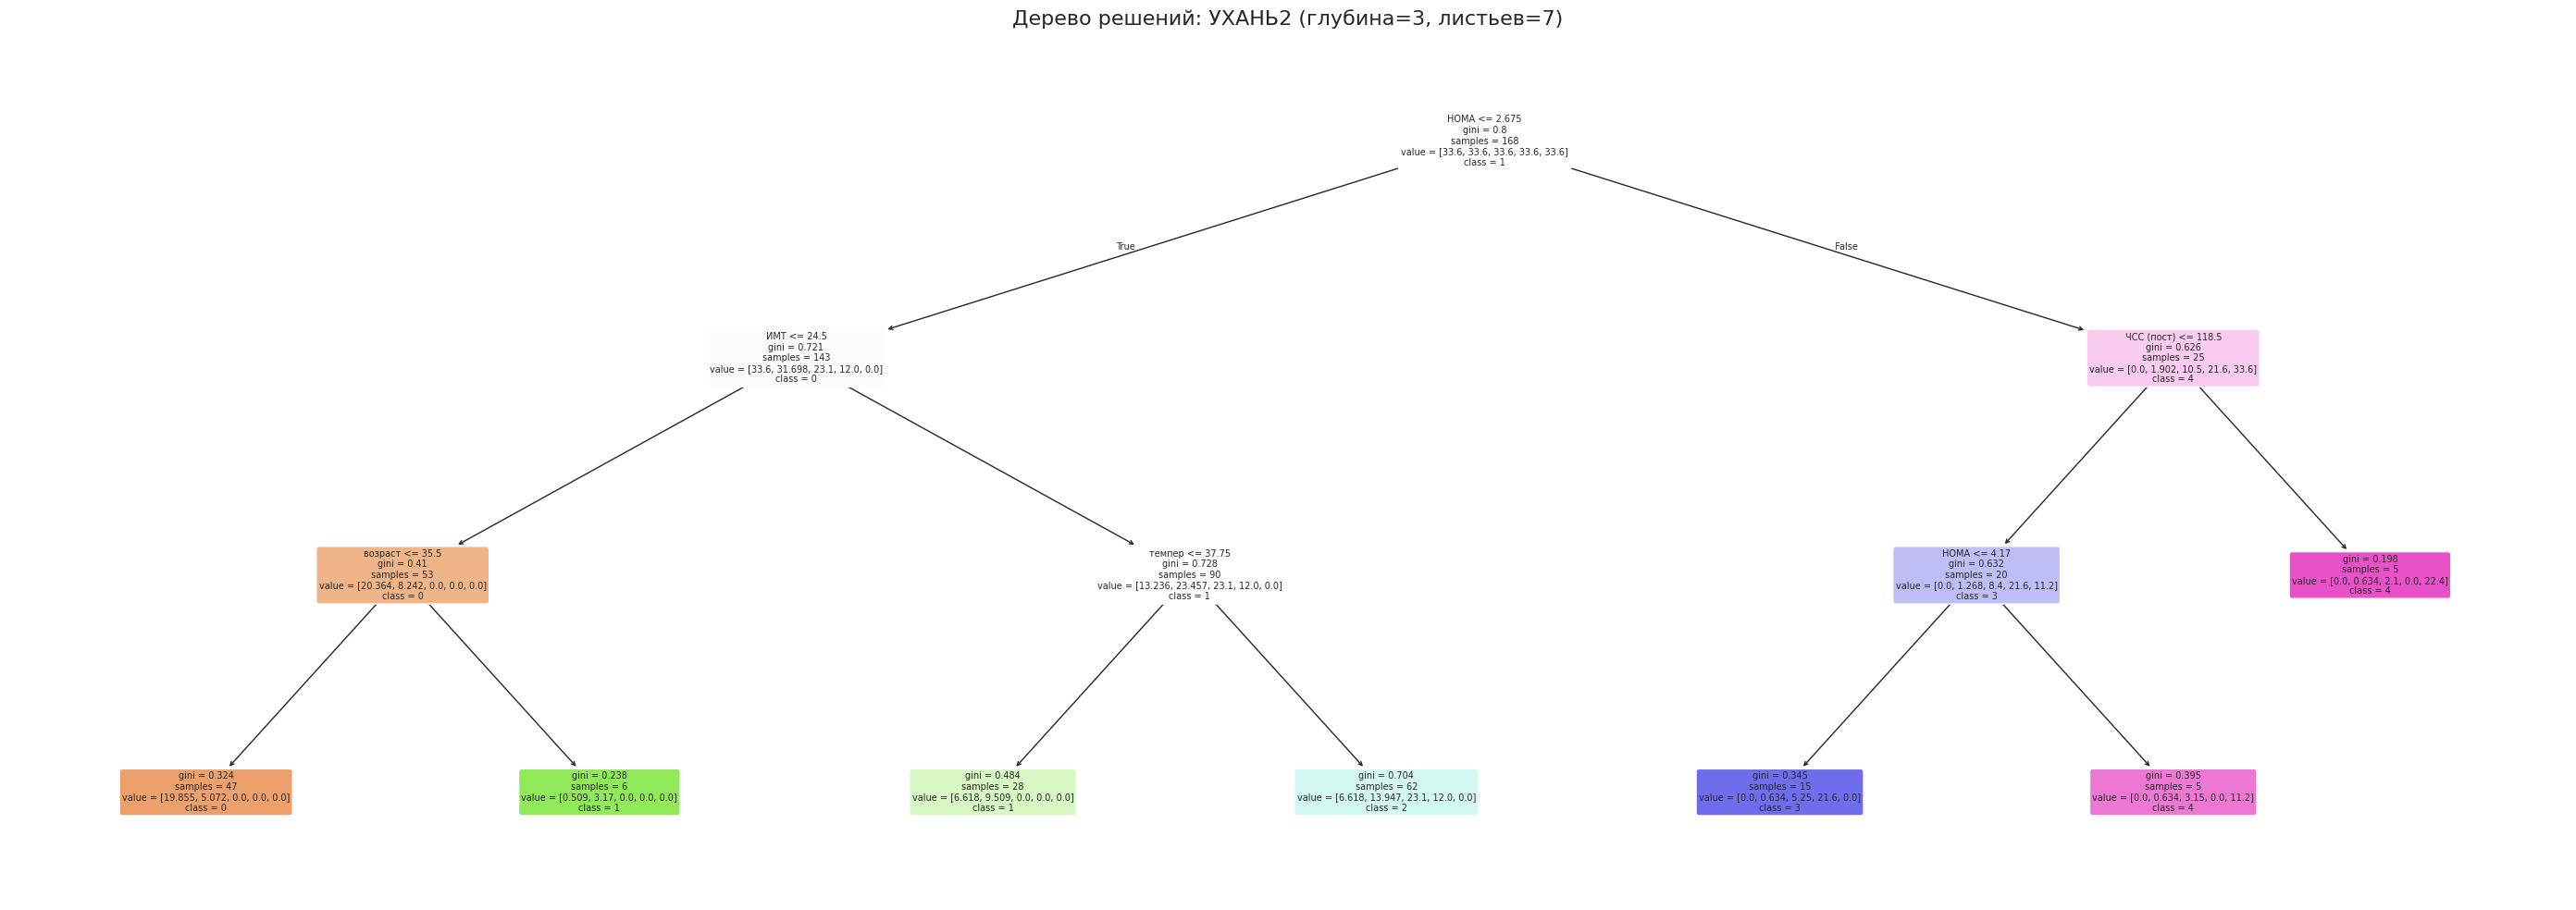

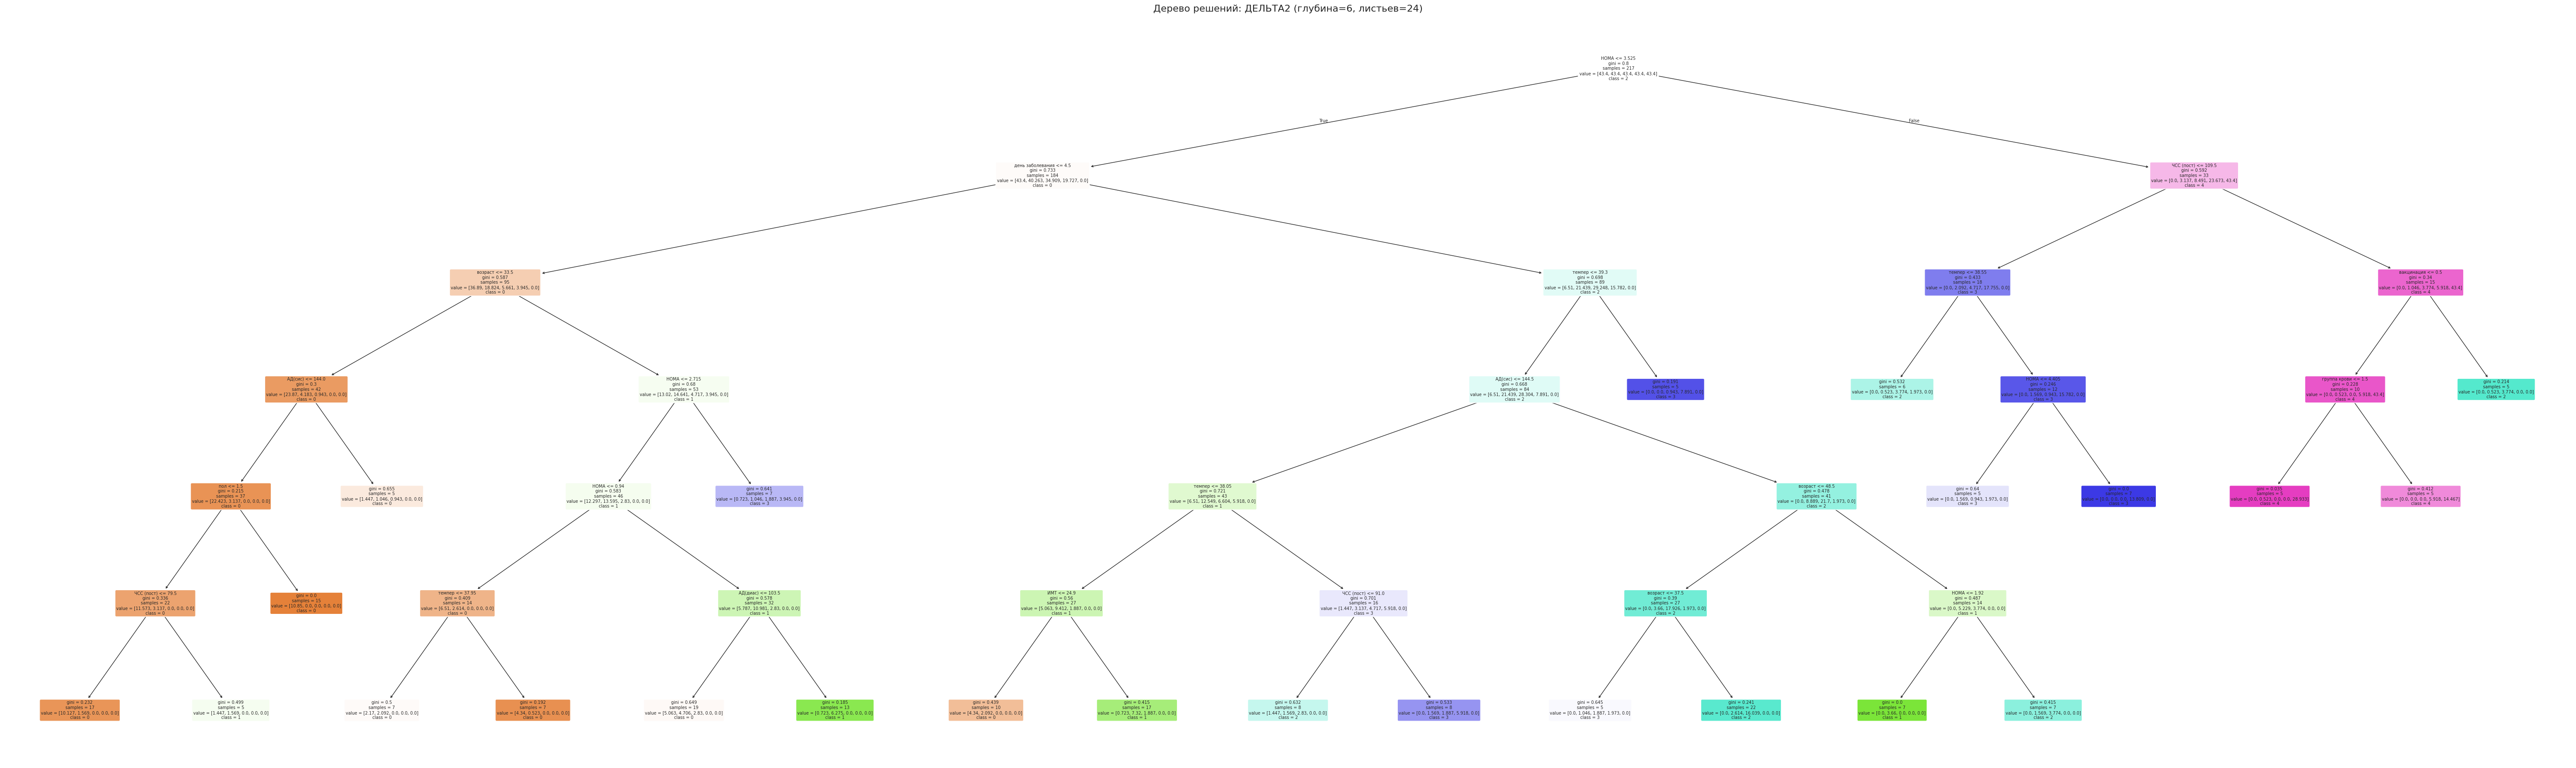

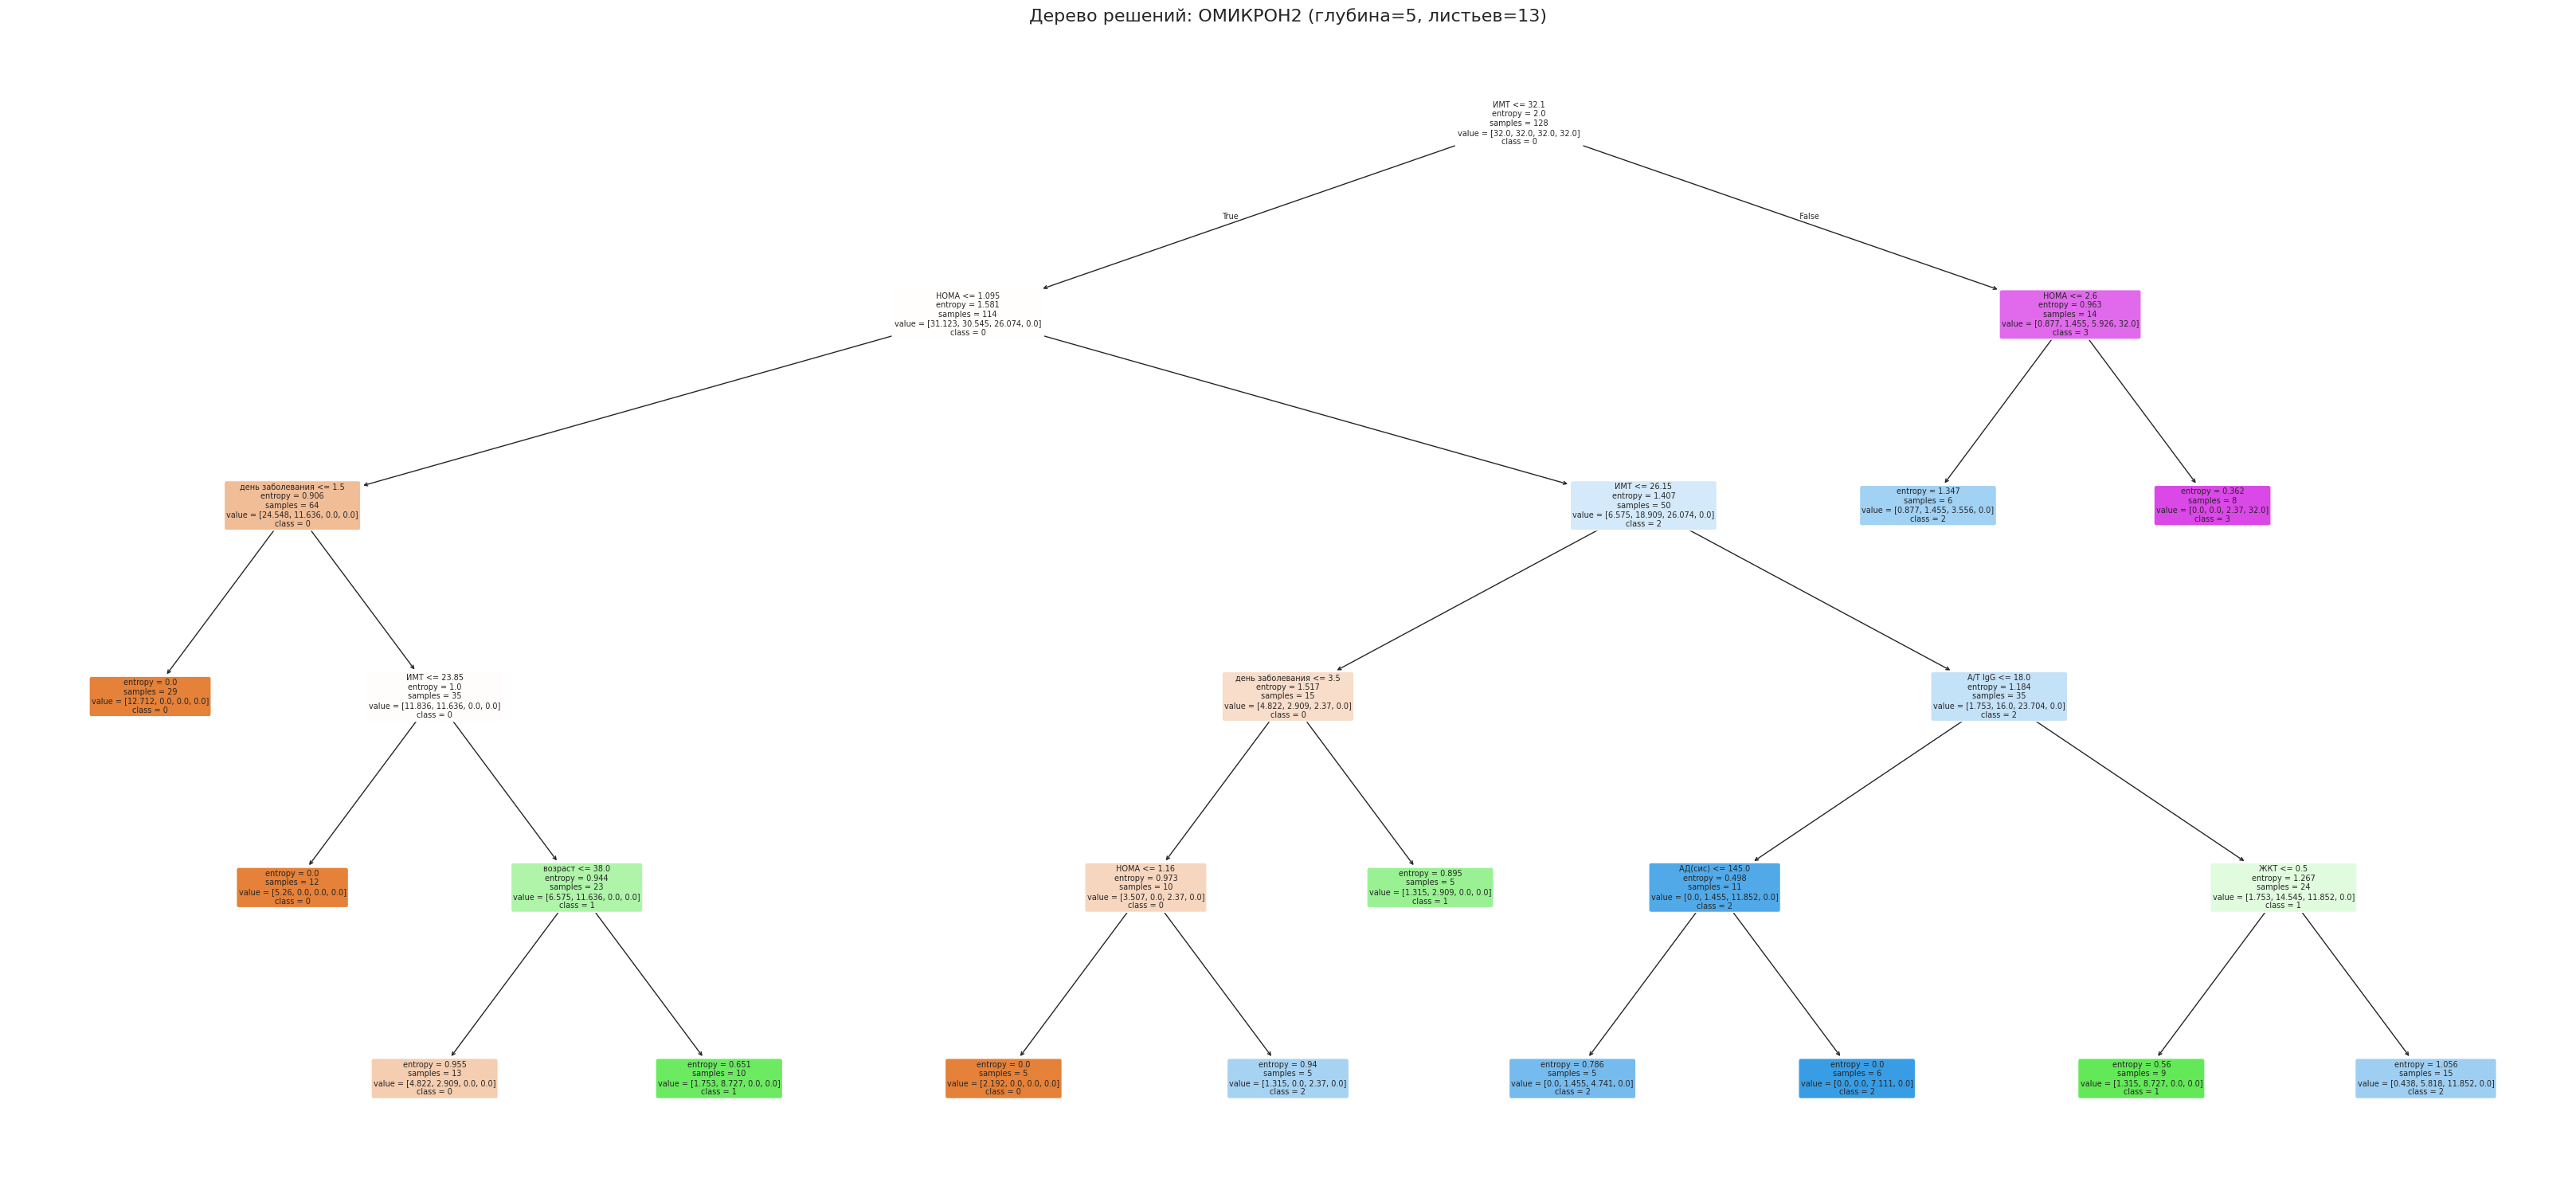

In [15]:
for name in SHEET_NAMES:
    model = best_models[name]
    depth = model.get_depth()
    n_leaves = model.get_n_leaves()

    # Масштабируем фигуру по глубине и количеству листьев
    fig_w = max(28, n_leaves * 2.5)
    fig_h = max(10, depth * 3)

    fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h))
    plot_tree(model, feature_names=list(feature_cols),
              class_names=[str(c) for c in sorted(splits[name][2].unique())],
              filled=True, rounded=True, ax=ax, fontsize=7)
    ax.set_title(f'Дерево решений: {name} (глубина={depth}, листьев={n_leaves})', fontsize=16)
    plt.tight_layout()
    plt.show()

### 5.3 Важность признаков (Decision Tree)

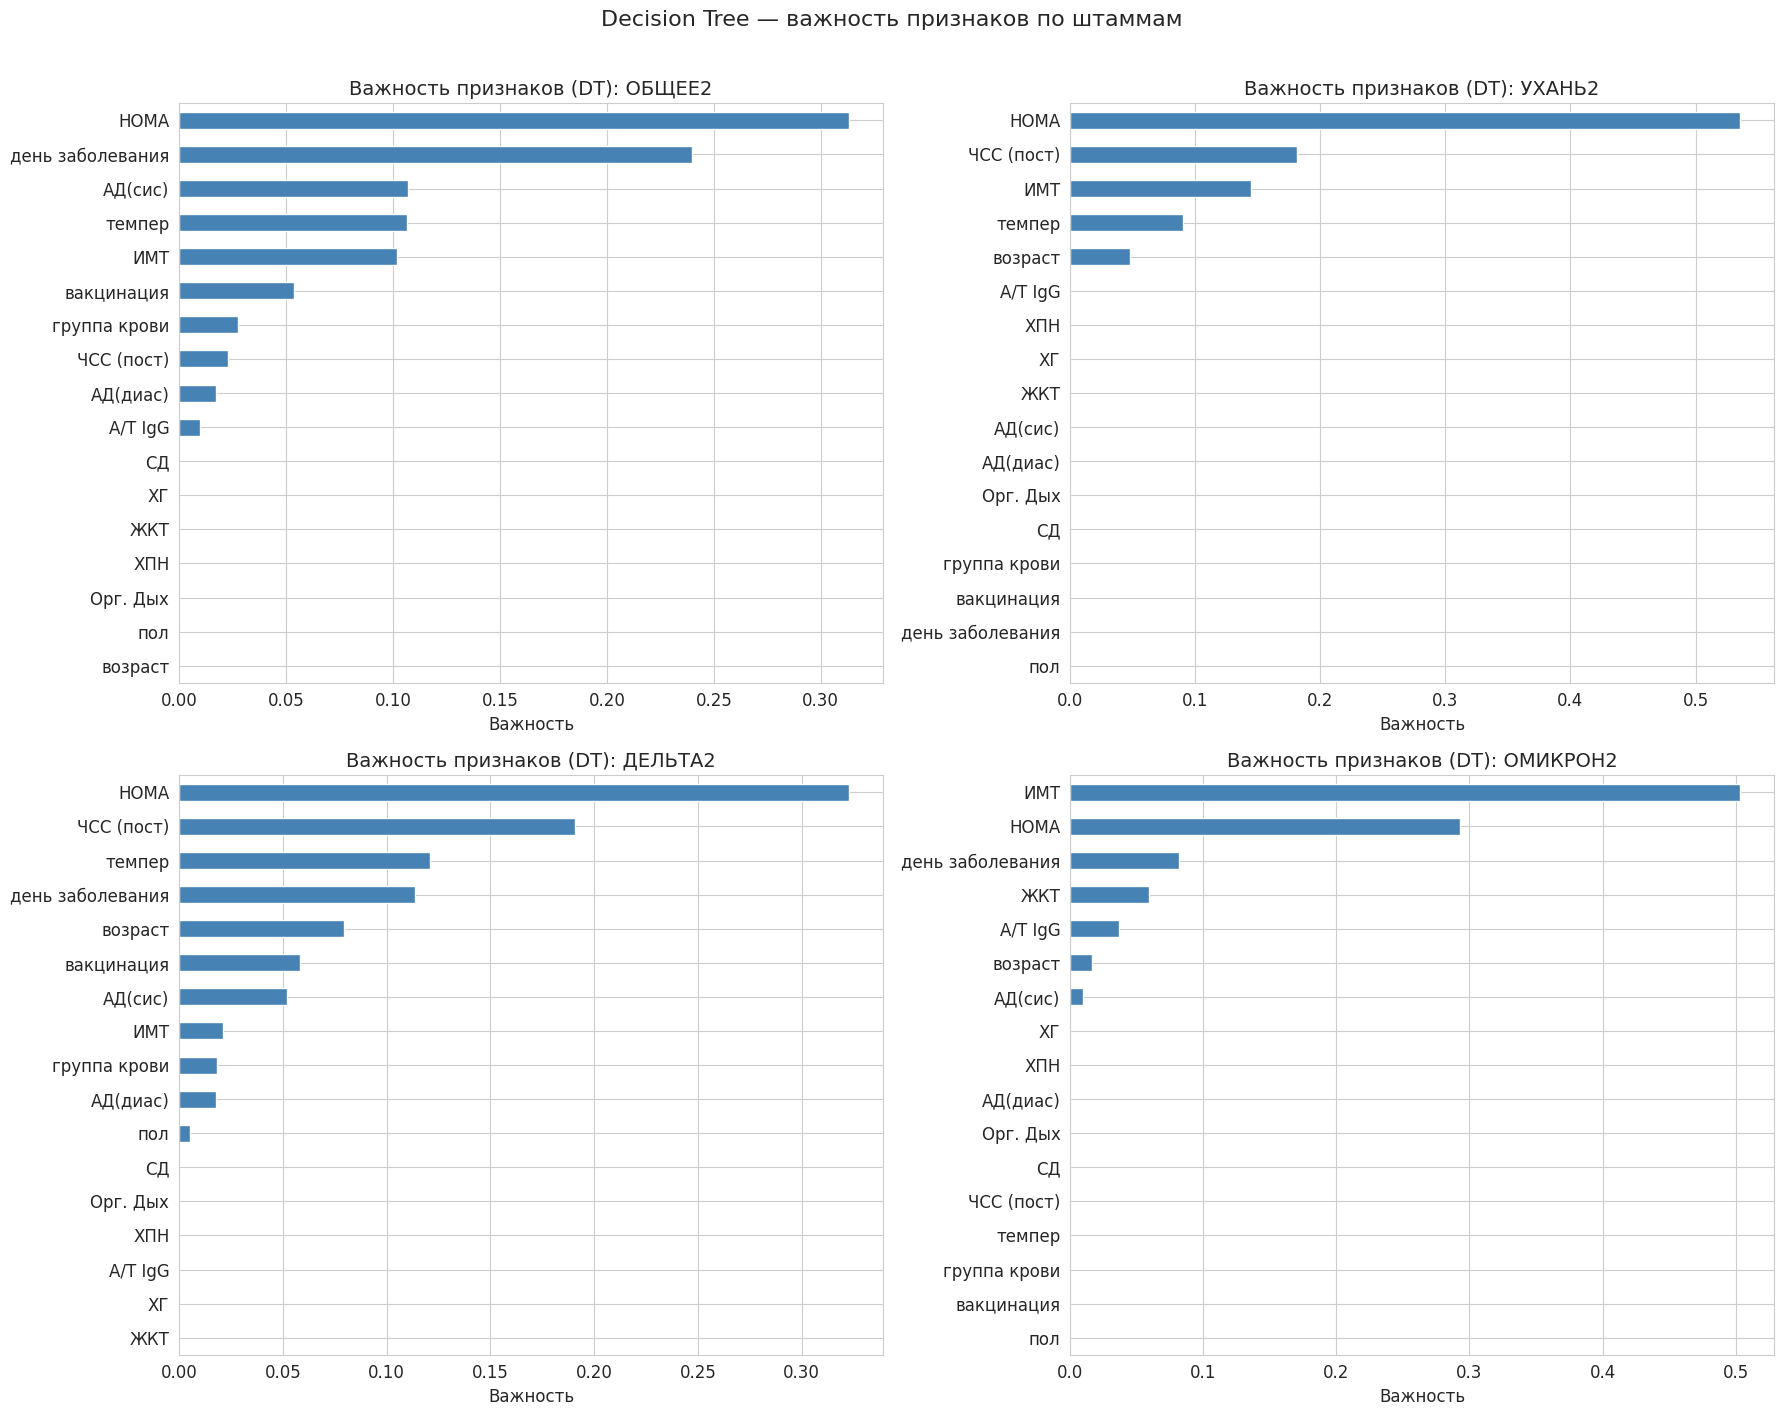

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, name in zip(axes.flatten(), SHEET_NAMES):
    model = best_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Важность признаков (DT): {name}', fontsize=14)
    ax.set_xlabel('Важность')
fig.suptitle('Decision Tree — важность признаков по штаммам', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Логистическая регрессия

In [17]:
# Логистическая регрессия с подбором гиперпараметров
lr_param_grid = {
    'classifier__C': [0.1, 0.5, 1, 5, 10, 50],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['saga'],
    'classifier__max_iter': [5000]
}

lr_models = {}
lr_results = []

for name in SHEET_NAMES:
    print(f"\n{'='*60}")
    print(f"  Логистическая регрессия: {name}")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test = splits[name]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE,
                                          class_weight='balanced'))
    ])

    grid = GridSearchCV(pipe, lr_param_grid, cv=cv,
                        scoring='f1_weighted', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)

    lr_models[name] = grid.best_estimator_

    print(f"\nЛучшие параметры: C={grid.best_params_['classifier__C']}, "
          f"penalty={grid.best_params_['classifier__penalty']}")
    print(f"Лучший F1 (CV): {grid.best_score_:.4f}")

    y_pred = grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')

    print(f"\nТестовые метрики:")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  F1 (weighted):   {f1_w:.4f}")
    print(f"  F1 (macro):      {f1_m:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    lr_results.append({
        'Accuracy (test)': round(acc, 4),
        'F1 test (weighted)': round(f1_w, 4),
        'F1 test (macro)': round(f1_m, 4)
    })


  Логистическая регрессия: ОБЩЕЕ2



Лучшие параметры: C=1, penalty=l1
Лучший F1 (CV): 0.5445

Тестовые метрики:
  Accuracy:        0.5581
  F1 (weighted):   0.5585
  F1 (macro):      0.5053

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73        50
           1       0.50      0.38      0.43        40
           2       0.48      0.46      0.47        26
           3       0.41      0.64      0.50        11
           4       0.25      1.00      0.40         2

    accuracy                           0.56       129
   macro avg       0.48      0.64      0.51       129
weighted avg       0.58      0.56      0.56       129


  Логистическая регрессия: УХАНЬ2



Лучшие параметры: C=50, penalty=l2
Лучший F1 (CV): 0.5047

Тестовые метрики:
  Accuracy:        0.5116
  F1 (weighted):   0.5056
  F1 (macro):      0.3171

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        17
           1       0.50      0.50      0.50        14
           2       0.00      0.00      0.00         8
           3       0.33      0.25      0.29         4
           4       0.00      0.00      0.00         0

    accuracy                           0.51        43
   macro avg       0.32      0.31      0.32        43
weighted avg       0.50      0.51      0.51        43


  Логистическая регрессия: ДЕЛЬТА2



Лучшие параметры: C=50, penalty=l2
Лучший F1 (CV): 0.5095

Тестовые метрики:
  Accuracy:        0.4727
  F1 (weighted):   0.4639
  F1 (macro):      0.4059

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.73      0.63        15
           1       0.60      0.43      0.50        21
           2       0.50      0.17      0.25        12
           3       0.33      0.60      0.43         5
           4       0.14      0.50      0.22         2

    accuracy                           0.47        55
   macro avg       0.43      0.49      0.41        55
weighted avg       0.52      0.47      0.46        55


  Логистическая регрессия: ОМИКРОН2



Лучшие параметры: C=0.1, penalty=l2
Лучший F1 (CV): 0.6233

Тестовые метрики:
  Accuracy:        0.6667
  F1 (weighted):   0.6824
  F1 (macro):      0.5891

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82        19
           1       0.43      0.60      0.50         5
           2       0.50      0.43      0.46         7
           3       0.40      1.00      0.57         2

    accuracy                           0.67        33
   macro avg       0.57      0.69      0.59        33
weighted avg       0.73      0.67      0.68        33



### 6.1 Коэффициенты логистической регрессии

Коэффициенты получены на **стандартизованных** признаках (StandardScaler). Величина коэффициента отражает силу влияния признака в единицах стандартного отклонения, а не в исходных единицах измерения. Знак показывает направление связи с классом.

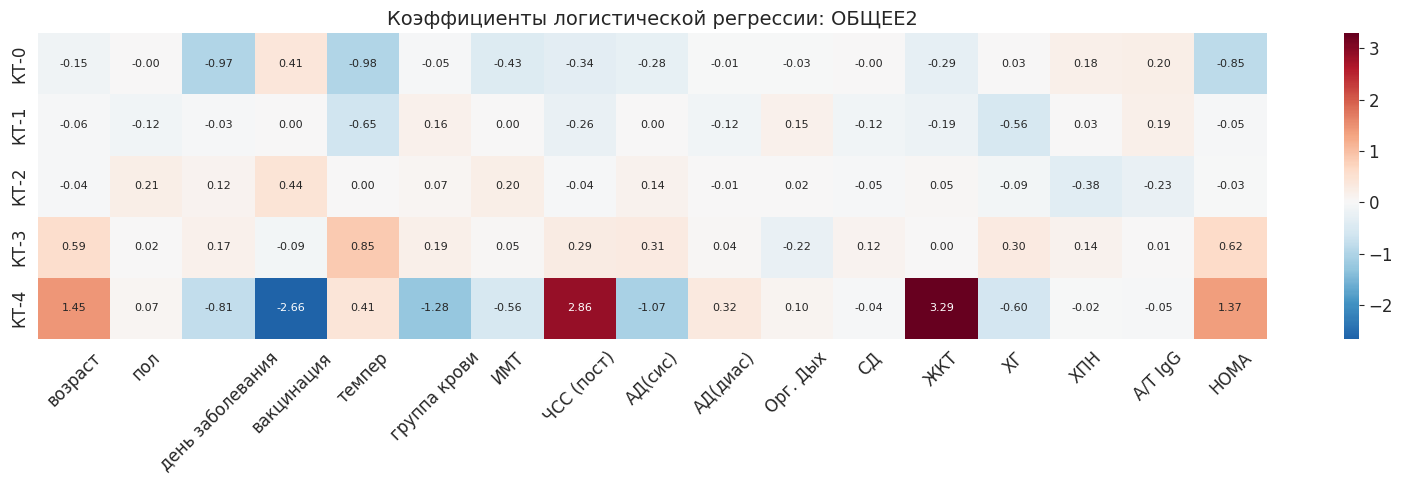

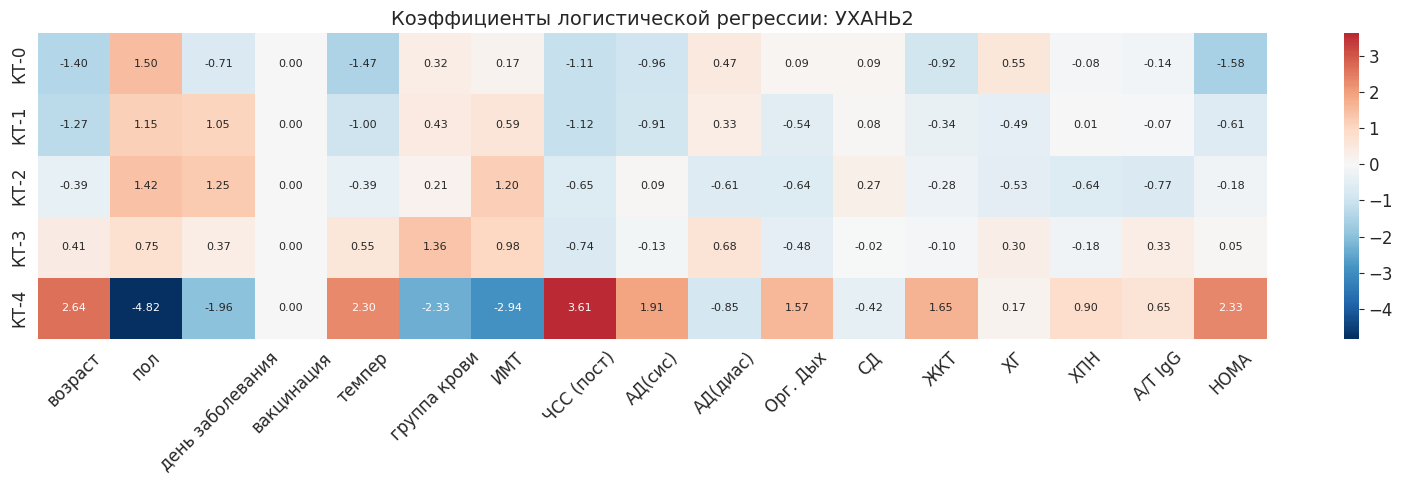

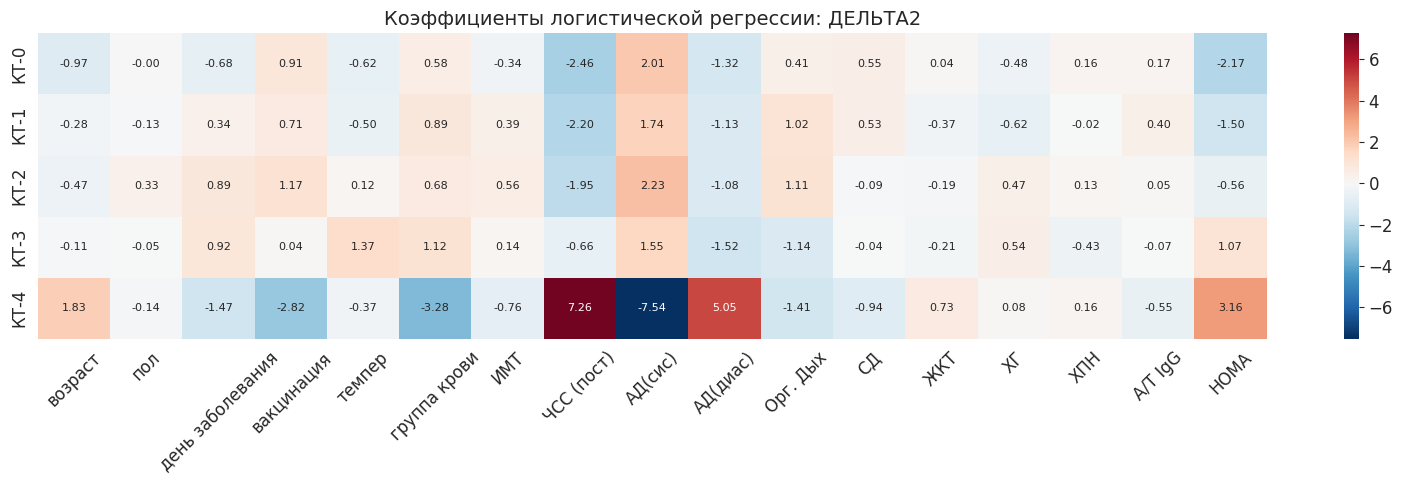

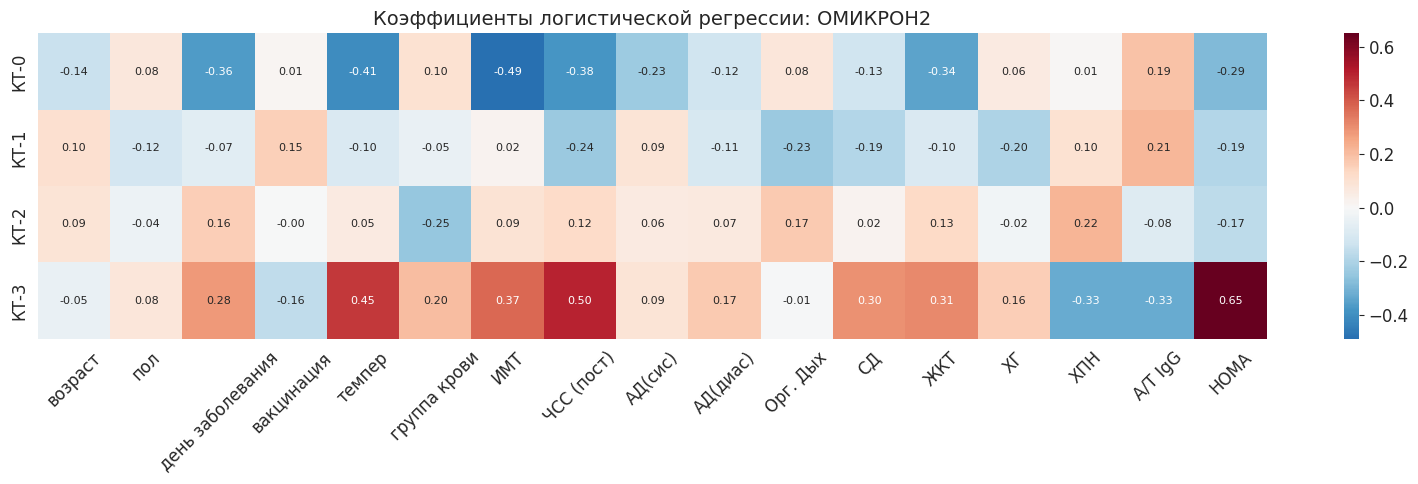

In [18]:
for name in SHEET_NAMES:
    model = lr_models[name]
    scaler = model.named_steps['scaler']
    clf = model.named_steps['classifier']

    coef_df = pd.DataFrame(
        clf.coef_,
        columns=feature_cols,
        index=[f'КТ-{c}' for c in clf.classes_]
    ).round(3)

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
                annot_kws={'size': 8})
    ax.set_title(f'Коэффициенты логистической регрессии: {name}', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

### 6.2 Матрицы ошибок (Logistic Regression)

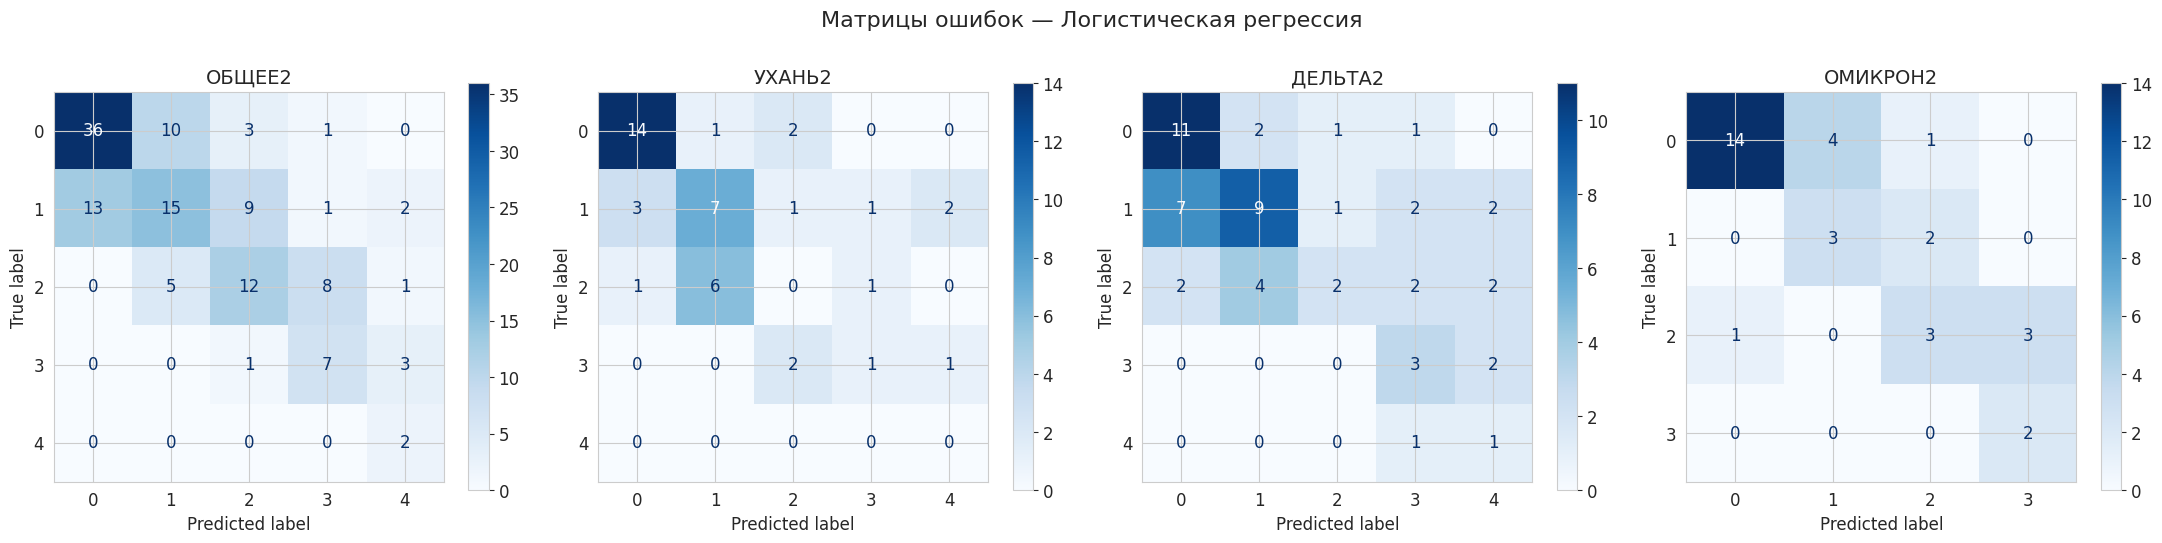

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, SHEET_NAMES):
    X_train, X_test, y_train, y_test = splits[name]
    y_pred = lr_models[name].predict(X_test)
    all_labels = sorted(set(y_train.unique()) | set(y_test.unique()))
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    ConfusionMatrixDisplay(cm, display_labels=all_labels).plot(ax=ax, cmap='Blues')
    ax.set_title(f'{name}', fontsize=14)
fig.suptitle('Матрицы ошибок — Логистическая регрессия', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. Случайный лес (Random Forest)

In [20]:
# Random Forest с подбором гиперпараметров
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt']
}

rf_models = {}
rf_results = []

for name in SHEET_NAMES:
    print(f"\n{'='*60}")
    print(f"  Random Forest: {name}")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test = splits[name]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
        rf_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, refit=True
    )
    grid.fit(X_train, y_train)

    rf_models[name] = grid.best_estimator_

    print(f"\nЛучшие параметры: {grid.best_params_}")
    print(f"Лучший F1 (CV): {grid.best_score_:.4f}")

    y_pred = grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')

    print(f"\nТестовые метрики:")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  F1 (weighted):   {f1_w:.4f}")
    print(f"  F1 (macro):      {f1_m:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    rf_results.append({
        'Accuracy (test)': round(acc, 4),
        'F1 test (weighted)': round(f1_w, 4),
        'F1 test (macro)': round(f1_m, 4)
    })


  Random Forest: ОБЩЕЕ2



Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Лучший F1 (CV): 0.5459

Тестовые метрики:
  Accuracy:        0.5814
  F1 (weighted):   0.5748
  F1 (macro):      0.4567

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.76      0.75        50
           1       0.44      0.40      0.42        40
           2       0.47      0.58      0.52        26
           3       0.67      0.55      0.60        11
           4       0.00      0.00      0.00         2

    accuracy                           0.58       129
   macro avg       0.46      0.46      0.46       129
weighted avg       0.57      0.58      0.57       129


  Random Forest: УХАНЬ2



Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 100}
Лучший F1 (CV): 0.5192

Тестовые метрики:
  Accuracy:        0.5581
  F1 (weighted):   0.5645
  F1 (macro):      0.4225

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.65      0.71        17
           1       0.47      0.64      0.55        14
           2       0.33      0.25      0.29         8
           3       0.67      0.50      0.57         4
           4       0.00      0.00      0.00         0

    accuracy                           0.56        43
   macro avg       0.45      0.41      0.42        43
weighted avg       0.59      0.56      0.56        43


  Random Forest: ДЕЛЬТА2



Лучшие параметры: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Лучший F1 (CV): 0.5311

Тестовые метрики:
  Accuracy:        0.4364
  F1 (weighted):   0.4276
  F1 (macro):      0.3498

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.67      0.62        15
           1       0.41      0.43      0.42        21
           2       0.27      0.25      0.26        12
           3       0.50      0.40      0.44         5
           4       0.00      0.00      0.00         2

    accuracy                           0.44        55
   macro avg       0.35      0.35      0.35        55
weighted avg       0.42      0.44      0.43        55


  Random Forest: ОМИКРОН2



Лучшие параметры: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
Лучший F1 (CV): 0.6776

Тестовые метрики:
  Accuracy:        0.6667
  F1 (weighted):   0.6537
  F1 (macro):      0.4788

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89        19
           1       0.00      0.00      0.00         5
           2       0.42      0.71      0.53         7
           3       0.50      0.50      0.50         2

    accuracy                           0.67        33
   macro avg       0.46      0.51      0.48        33
weighted avg       0.66      0.67      0.65        33



### 7.1 Важность признаков (Random Forest)

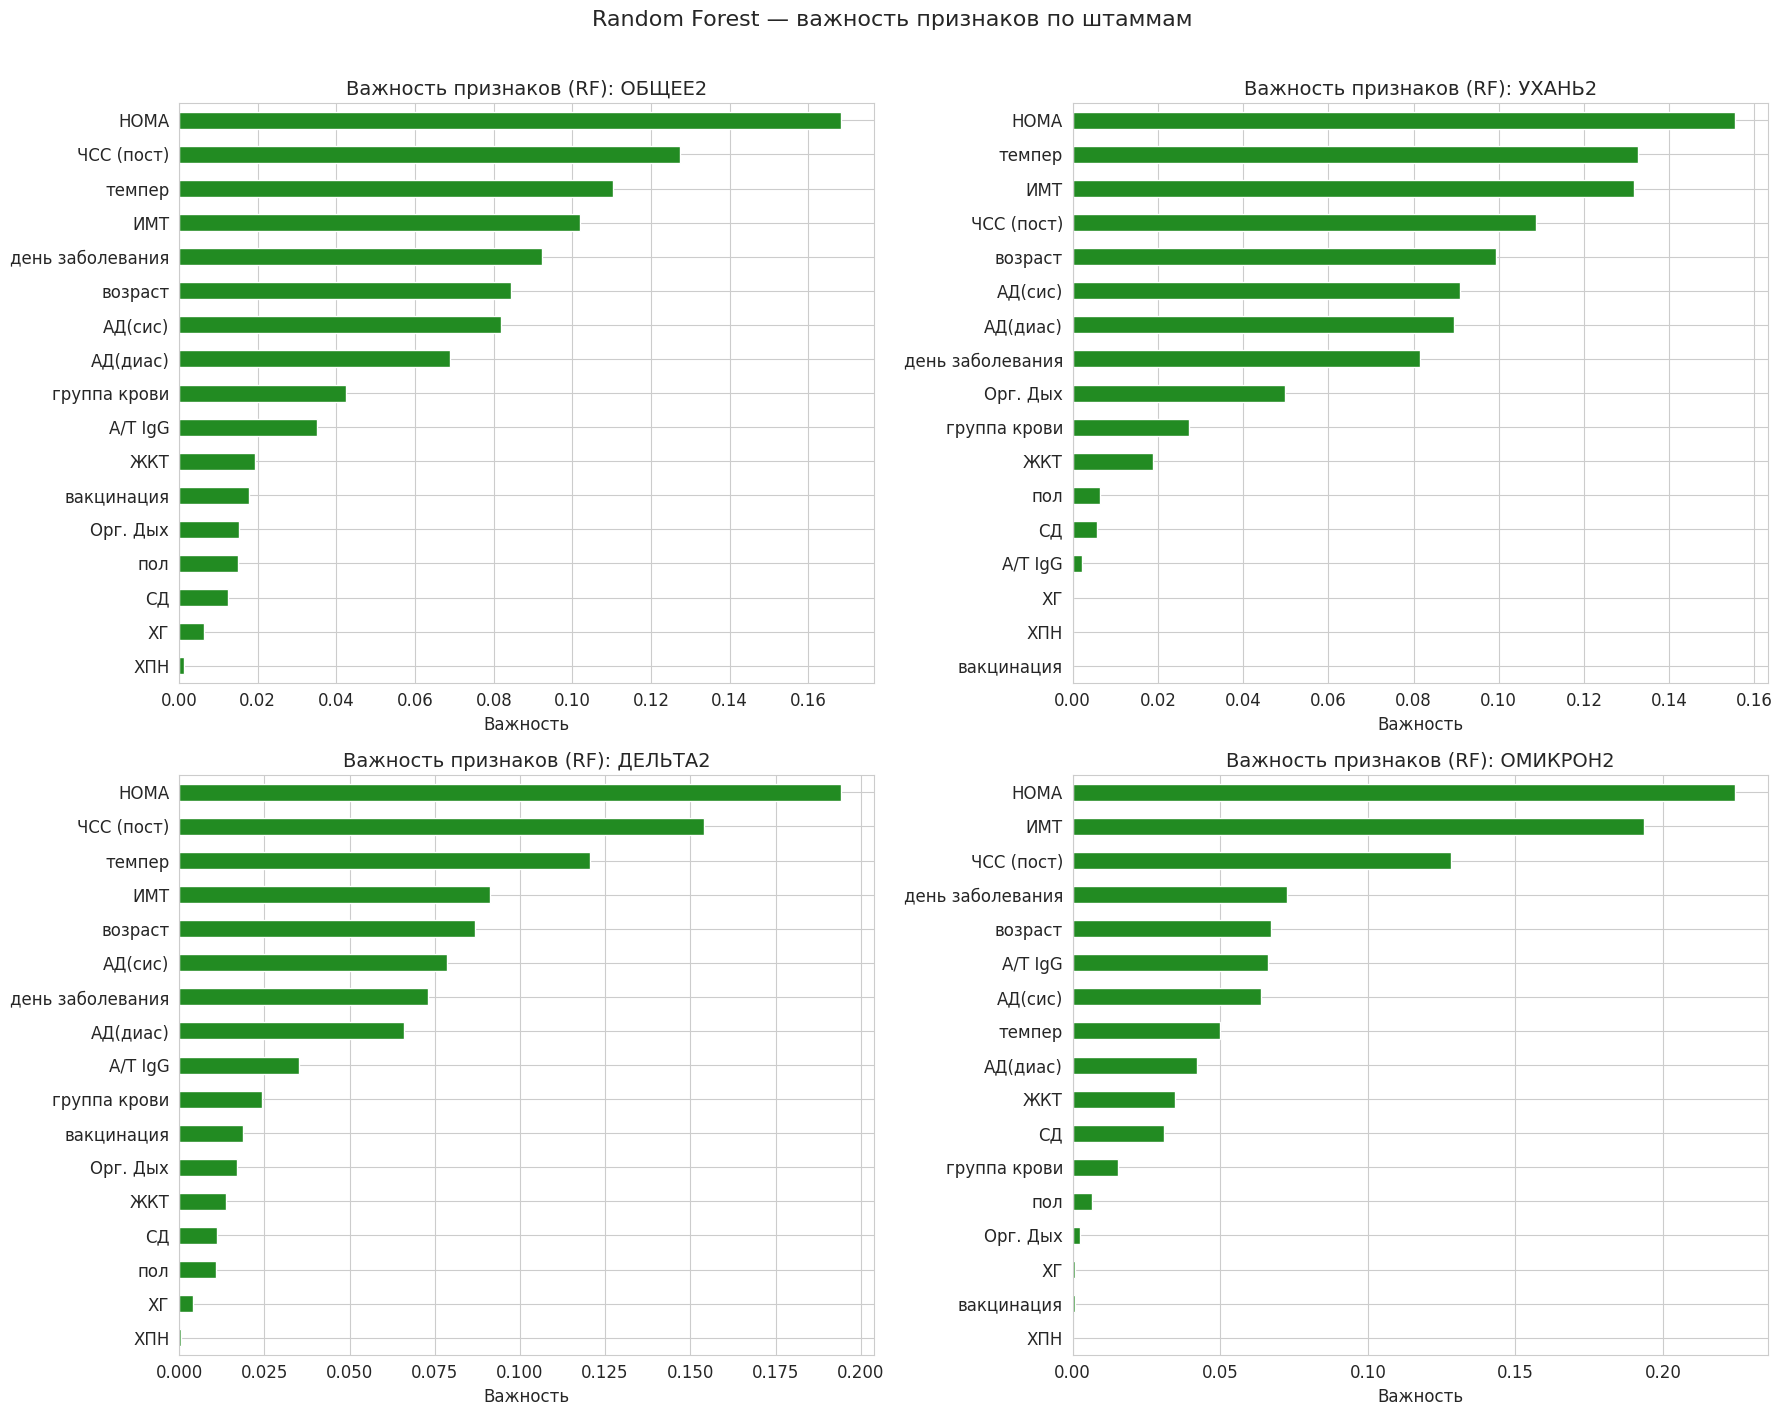

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, name in zip(axes.flatten(), SHEET_NAMES):
    model = rf_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='forestgreen')
    ax.set_title(f'Важность признаков (RF): {name}', fontsize=14)
    ax.set_xlabel('Важность')
fig.suptitle('Random Forest — важность признаков по штаммам', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 7.2 Матрицы ошибок (Random Forest)

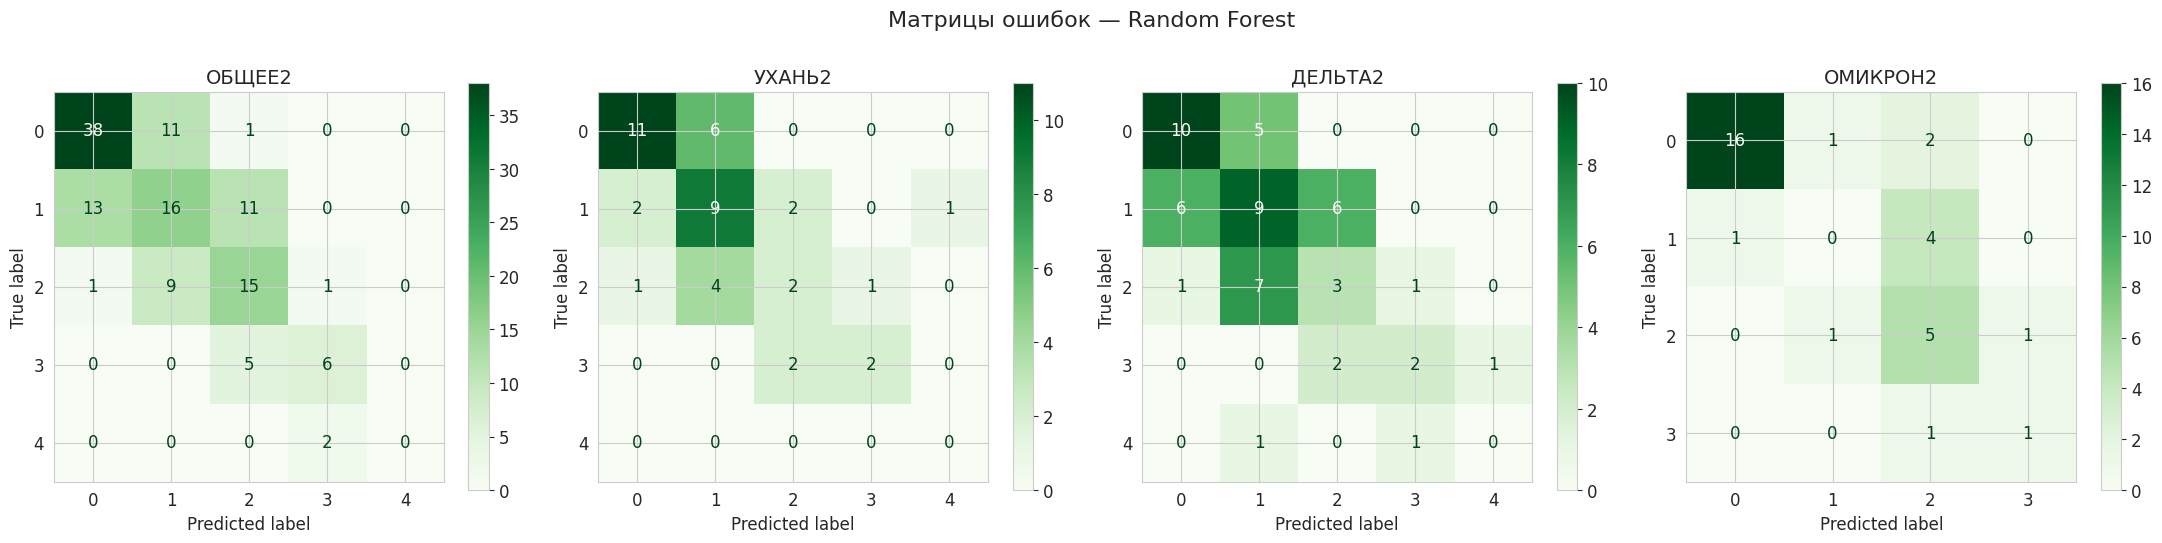

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, SHEET_NAMES):
    X_train, X_test, y_train, y_test = splits[name]
    y_pred = rf_models[name].predict(X_test)
    all_labels = sorted(set(y_train.unique()) | set(y_test.unique()))
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    ConfusionMatrixDisplay(cm, display_labels=all_labels).plot(ax=ax, cmap='Greens')
    ax.set_title(f'{name}', fontsize=14)
fig.suptitle('Матрицы ошибок — Random Forest', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Градиентный бустинг (Gradient Boosting)

In [23]:
# Gradient Boosting с подбором гиперпараметров
# GB не поддерживает class_weight, поэтому используем sample_weight
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.02, 0.05, 0.1],
    'min_samples_leaf': [5, 10],
    'subsample': [0.8, 1.0]
}

gb_models = {}
gb_results = []

for name in SHEET_NAMES:
    print(f"\n{'='*60}")
    print(f"  Gradient Boosting: {name}")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test = splits[name]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    sample_weights = compute_sample_weight('balanced', y_train)

    grid = GridSearchCV(
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        gb_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, refit=True
    )
    grid.fit(X_train, y_train, sample_weight=sample_weights)

    gb_models[name] = grid.best_estimator_

    print(f"\nЛучшие параметры: {grid.best_params_}")
    print(f"Лучший F1 (CV): {grid.best_score_:.4f}")

    y_pred = grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')

    print(f"\nТестовые метрики:")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  F1 (weighted):   {f1_w:.4f}")
    print(f"  F1 (macro):      {f1_m:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    gb_results.append({
        'Accuracy (test)': round(acc, 4),
        'F1 test (weighted)': round(f1_w, 4),
        'F1 test (macro)': round(f1_m, 4)
    })


  Gradient Boosting: ОБЩЕЕ2



Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100, 'subsample': 0.8}
Лучший F1 (CV): 0.4579

Тестовые метрики:
  Accuracy:        0.5349
  F1 (weighted):   0.5232
  F1 (macro):      0.4068

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73        50
           1       0.43      0.33      0.37        40
           2       0.38      0.38      0.38        26
           3       0.41      0.82      0.55        11
           4       0.00      0.00      0.00         2

    accuracy                           0.53       129
   macro avg       0.39      0.45      0.41       129
weighted avg       0.53      0.53      0.52       129


  Gradient Boosting: УХАНЬ2



Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 100, 'subsample': 1.0}
Лучший F1 (CV): 0.3839

Тестовые метрики:
  Accuracy:        0.5116
  F1 (weighted):   0.5169
  F1 (macro):      0.3577

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        17
           1       0.47      0.50      0.48        14
           2       0.29      0.25      0.27         8
           3       0.50      0.25      0.33         4
           4       0.00      0.00      0.00         0

    accuracy                           0.51        43
   macro avg       0.39      0.34      0.36        43
weighted avg       0.53      0.51      0.52        43


  Gradient Boosting: ДЕЛЬТА2



Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100, 'subsample': 0.8}
Лучший F1 (CV): 0.4859

Тестовые метрики:
  Accuracy:        0.4909
  F1 (weighted):   0.4692
  F1 (macro):      0.3756

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.87      0.70        15
           1       0.54      0.33      0.41        21
           2       0.38      0.42      0.40        12
           3       0.33      0.40      0.36         5
           4       0.00      0.00      0.00         2

    accuracy                           0.49        55
   macro avg       0.37      0.40      0.38        55
weighted avg       0.48      0.49      0.47        55


  Gradient Boosting: ОМИКРОН2



Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100, 'subsample': 1.0}
Лучший F1 (CV): 0.5301

Тестовые метрики:
  Accuracy:        0.6364
  F1 (weighted):   0.6693
  F1 (macro):      0.5205

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85        19
           1       0.29      0.40      0.33         5
           2       0.44      0.57      0.50         7
           3       0.33      0.50      0.40         2

    accuracy                           0.64        33
   macro avg       0.52      0.55      0.52        33
weighted avg       0.73      0.64      0.67        33



### 8.1 Важность признаков (Gradient Boosting)

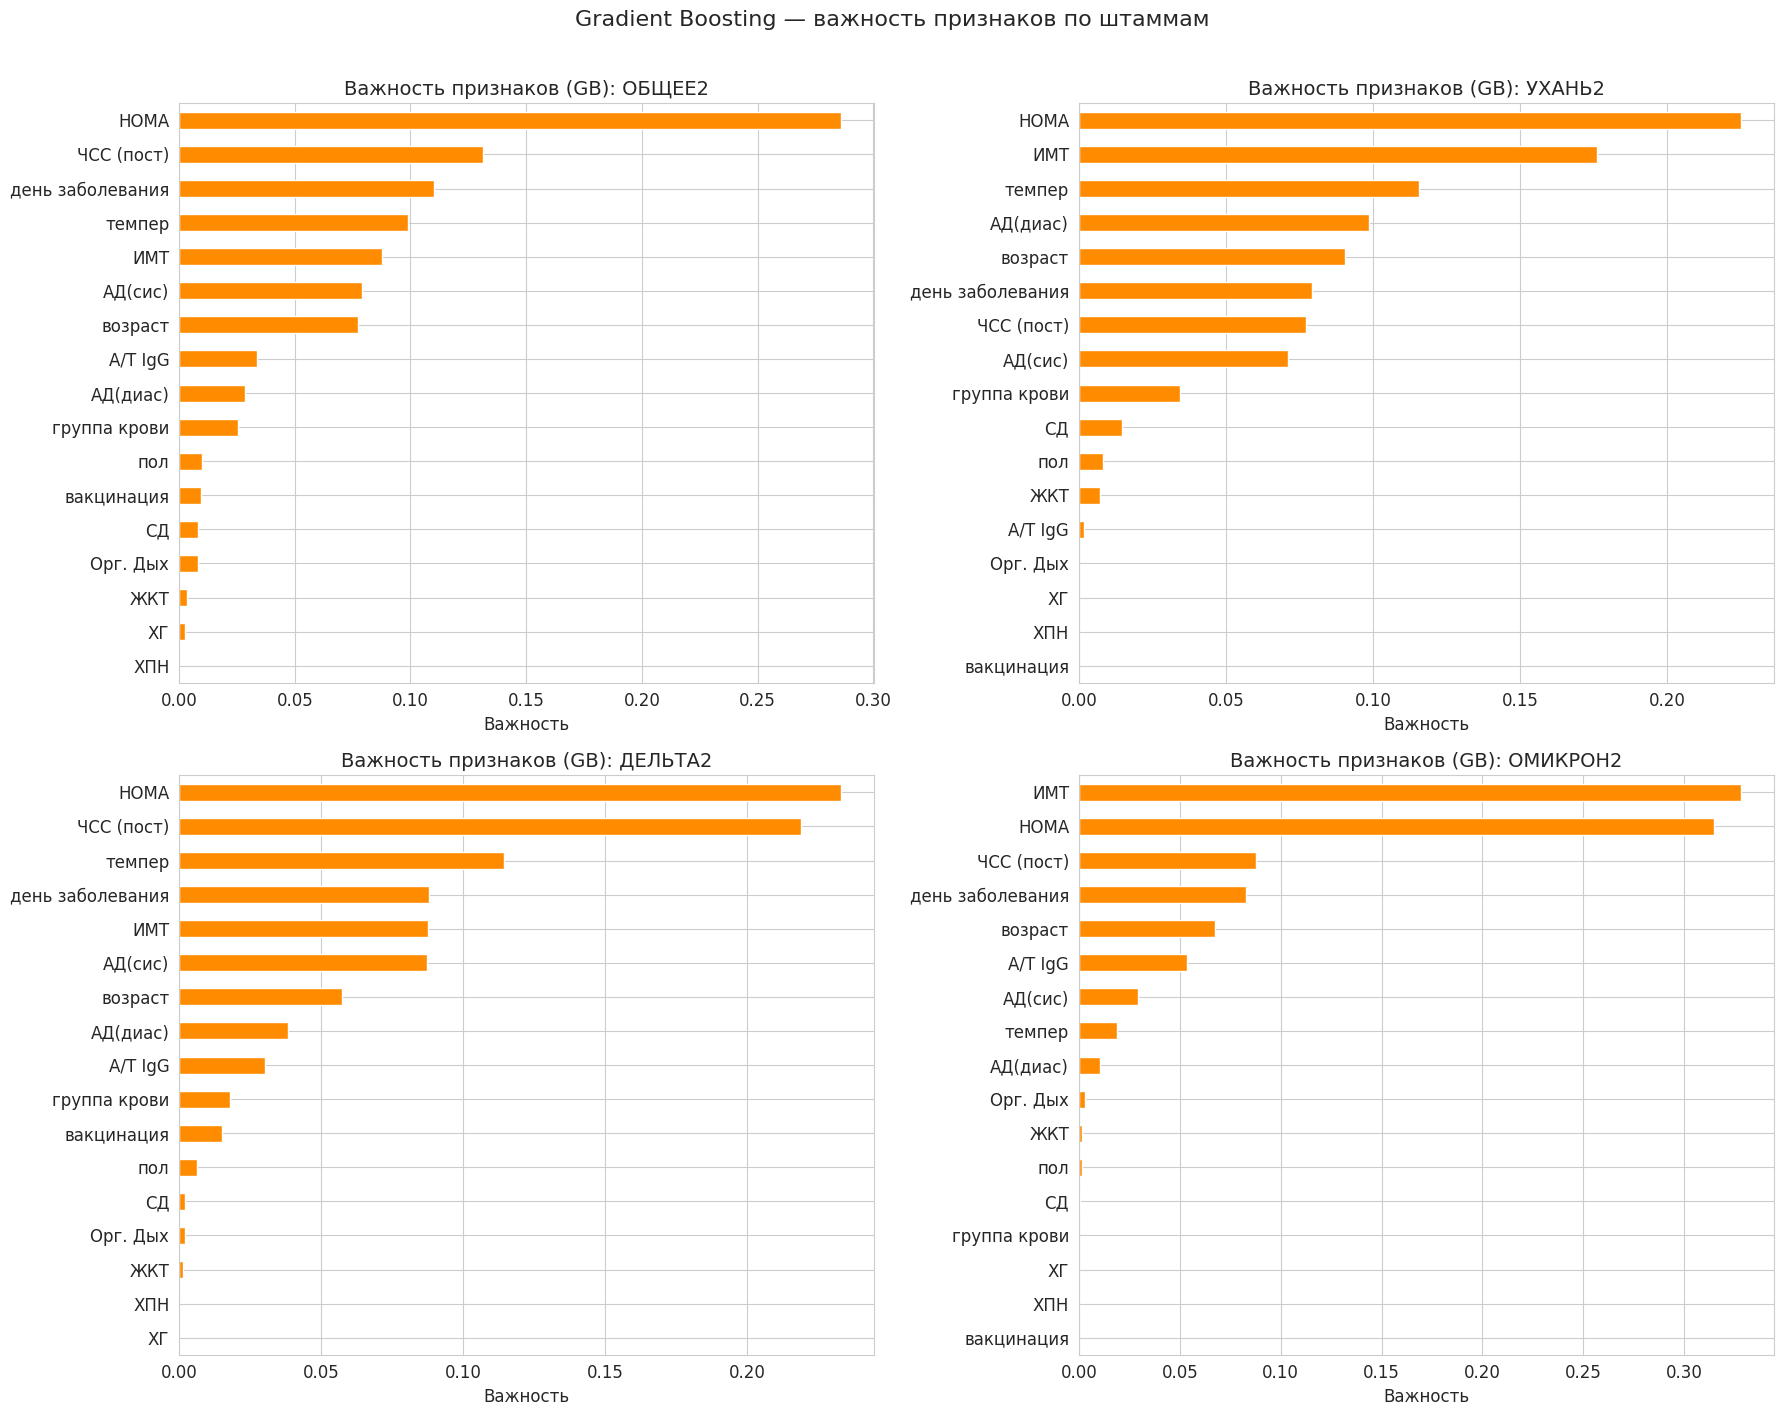

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, name in zip(axes.flatten(), SHEET_NAMES):
    model = gb_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title(f'Важность признаков (GB): {name}', fontsize=14)
    ax.set_xlabel('Важность')
fig.suptitle('Gradient Boosting — важность признаков по штаммам', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 8.2 Матрицы ошибок (Gradient Boosting)

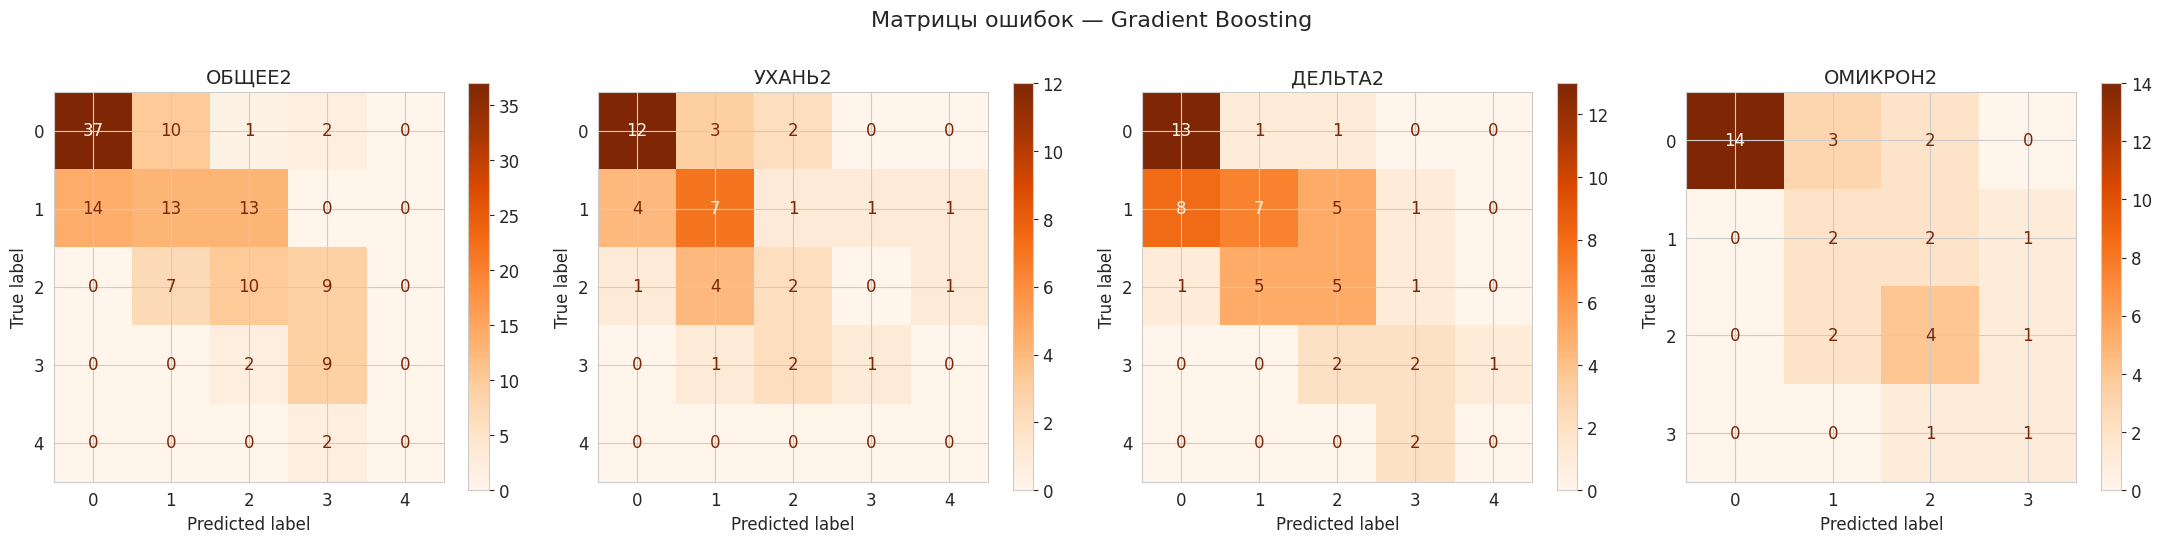

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, SHEET_NAMES):
    X_train, X_test, y_train, y_test = splits[name]
    y_pred = gb_models[name].predict(X_test)
    all_labels = sorted(set(y_train.unique()) | set(y_test.unique()))
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    ConfusionMatrixDisplay(cm, display_labels=all_labels).plot(ax=ax, cmap='Oranges')
    ax.set_title(f'{name}', fontsize=14)
fig.suptitle('Матрицы ошибок — Gradient Boosting', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Сравнение всех моделей

In [26]:
# Сводная таблица метрик всех моделей
all_results = []

for i, name in enumerate(SHEET_NAMES):
    all_results.append({'Штамм': name, 'Модель': 'Decision Tree', **results_summary[i]})
    all_results.append({'Штамм': name, 'Модель': 'Logistic Regression', **lr_results[i]})
    all_results.append({'Штамм': name, 'Модель': 'Random Forest', **rf_results[i]})
    all_results.append({'Штамм': name, 'Модель': 'Gradient Boosting', **gb_results[i]})

all_results_df = pd.DataFrame(all_results)
display(all_results_df.pivot_table(index='Штамм', columns='Модель',
                                    values=['Accuracy (test)', 'F1 test (weighted)', 'F1 test (macro)'])
        .round(4))

Accuracy (test)                                                      \
Модель     Decision Tree Gradient Boosting Logistic Regression Random Forest   
Штамм                                                                          
ДЕЛЬТА2           0.3091            0.4909              0.4727        0.4364   
ОБЩЕЕ2            0.4496            0.5349              0.5581        0.5814   
ОМИКРОН2          0.6364            0.6364              0.6667        0.6667   
УХАНЬ2            0.4651            0.5116              0.5116        0.5581   

         F1 test (macro)                                                      \
Модель     Decision Tree Gradient Boosting Logistic Regression Random Forest   
Штамм                                                                          
ДЕЛЬТА2           0.2218            0.3756              0.4059        0.3498   
ОБЩЕЕ2            0.3232            0.4068              0.5053        0.4567   
ОМИКРОН2          0.4918            0.5205              0.5891        0.4788   
УХАНЬ2            0.3191            0.3577              0.3171        0.4225   

         F1 test (weighted)                                        \
Модель        Decision Tree Gradient Boosting Logistic Regression   
Штамм                                                               
ДЕЛЬТА2              0.2971            0.4692              0.4639   
ОБЩЕЕ2               0.4607            0.5232              0.5585   
ОМИКРОН2             0.6528            0.6693              0.6824   
УХАНЬ2               0.5056            0.5169              0.5056   

                        
Модель   Random Forest  
Штамм                   
ДЕЛЬТА2         0.4276  
ОБЩЕЕ2          0.5748  
ОМИКРОН2        0.6537  
УХАНЬ2          0.5645

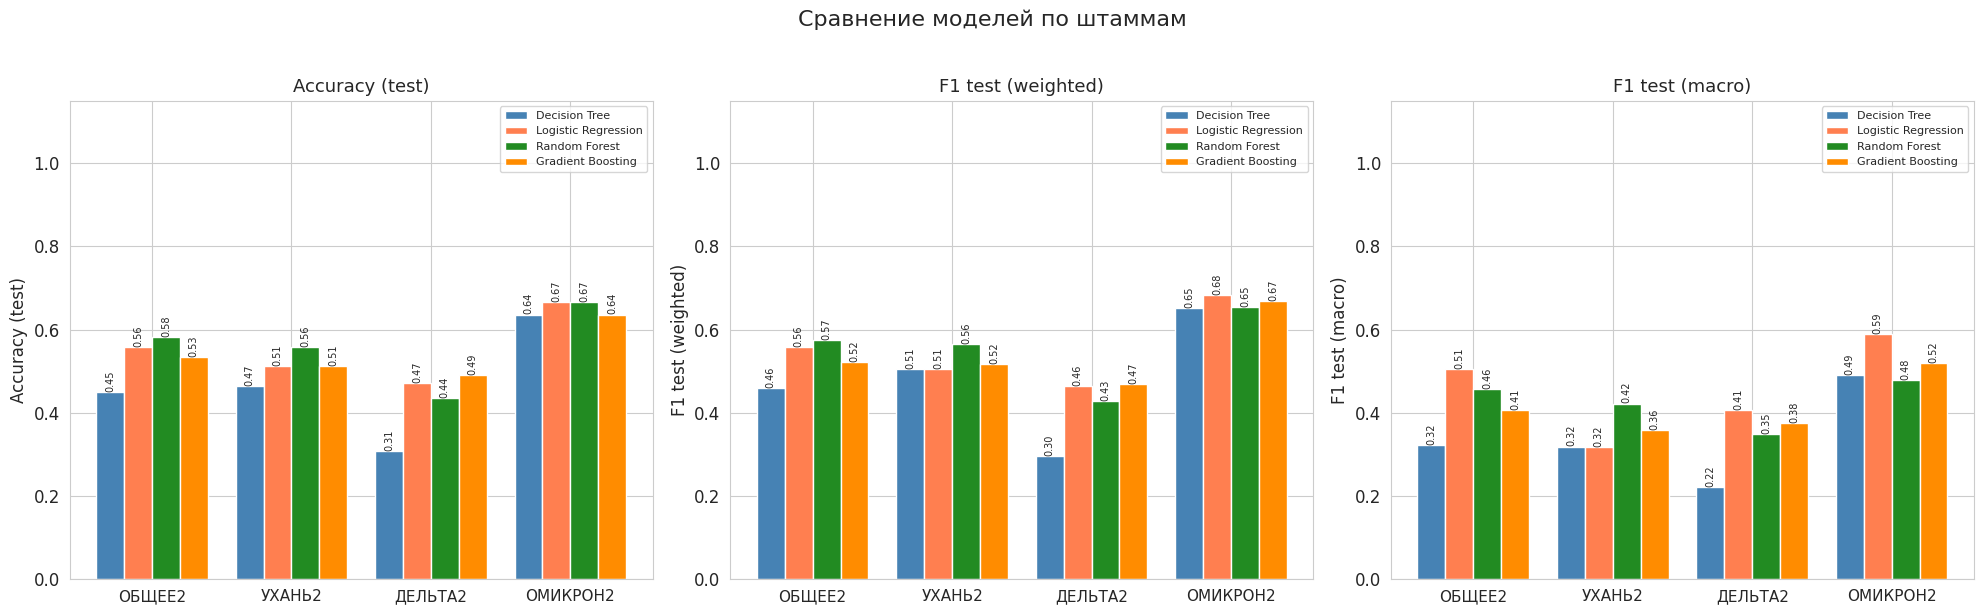

In [27]:
# Сравнительный график: Accuracy по моделям и штаммам
models_list = ['Decision Tree', 'Logistic Regression', 'Random Forest', 'Gradient Boosting']
colors_models = ['steelblue', 'coral', 'forestgreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics_to_plot = ['Accuracy (test)', 'F1 test (weighted)', 'F1 test (macro)']

for ax, metric in zip(axes, metrics_to_plot):
    x = np.arange(len(SHEET_NAMES))
    width = 0.2
    for i, model in enumerate(models_list):
        vals = all_results_df[all_results_df['Модель'] == model][metric].values
        bars = ax.bar(x + i * width, vals, width, label=model, color=colors_models[i])
        for j, v in enumerate(vals):
            ax.text(x[j] + i * width, v + 0.005, f'{v:.2f}', ha='center', fontsize=7, rotation=90)
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(SHEET_NAMES, fontsize=11)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.15)
    ax.set_title(metric, fontsize=13)
    ax.legend(fontsize=8)

fig.suptitle('Сравнение моделей по штаммам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

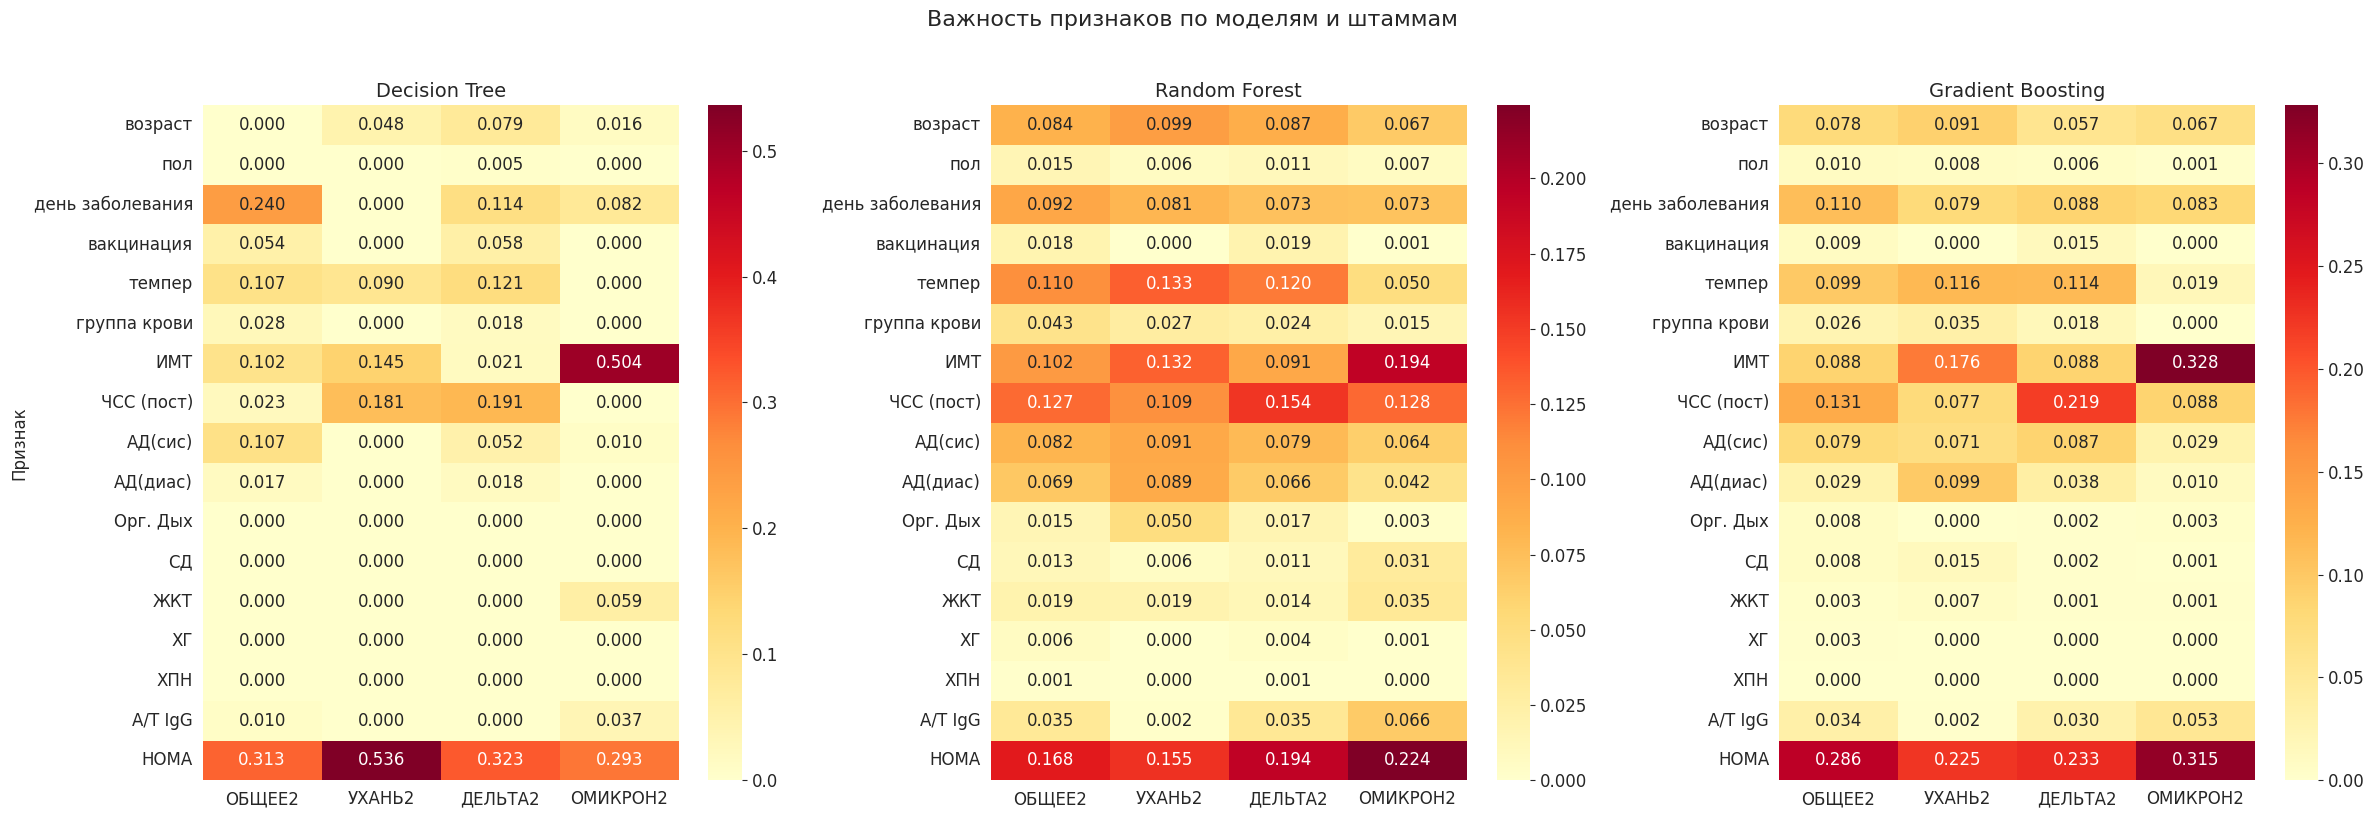

In [28]:
# Сравнение важности признаков: Decision Tree vs Random Forest vs Gradient Boosting
# (Логистическая регрессия использует коэффициенты, не feature_importances_)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
model_dicts = [
    ('Decision Tree', best_models),
    ('Random Forest', rf_models),
    ('Gradient Boosting', gb_models)
]

for ax, (model_name, model_dict) in zip(axes, model_dicts):
    imp_df = pd.DataFrame({
        name: pd.Series(model_dict[name].feature_importances_, index=feature_cols)
        for name in SHEET_NAMES
    })
    sns.heatmap(imp_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'{model_name}', fontsize=14)
    ax.set_ylabel('Признак' if ax == axes[0] else '')

fig.suptitle('Важность признаков по моделям и штаммам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 10. Permutation Importance — надёжная оценка важности признаков

**Permutation importance** — модельно-независимый метод: оценивает важность признака как падение качества модели при случайной перетасовке его значений. В отличие от встроенного `feature_importances_` (который зависит от структуры конкретной модели), permutation importance напрямую измеряет вклад признака в **обобщающую способность** модели.

Считаем по тестовой выборке (n_repeats=20, scoring='f1_weighted') для трёх моделей: **Logistic Regression**, **Random Forest**, **Gradient Boosting**. Decision Tree исключён из итогового агрегирования как наименее устойчивая модель.

In [29]:
# Расчёт permutation importance для LR, RF, GB по всем штаммам
perm_results = {}  # perm_results[model_name][sheet] = pd.Series of importances

model_dicts_for_perm = [
    ('Logistic Regression', lr_models),
    ('Random Forest', rf_models),
    ('Gradient Boosting', gb_models)
]

for model_name, model_dict in model_dicts_for_perm:
    perm_results[model_name] = {}
    for name in SHEET_NAMES:
        X_train, X_test, y_train, y_test = splits[name]
        result = permutation_importance(
            model_dict[name], X_test, y_test,
            n_repeats=20, random_state=RANDOM_STATE,
            scoring='f1_weighted', n_jobs=-1
        )
        perm_results[model_name][name] = pd.Series(
            result.importances_mean, index=feature_cols
        )
    print(f'{model_name}: готово')

Logistic Regression: готово


Random Forest: готово


Gradient Boosting: готово


### 10.1 Permutation importance по моделям

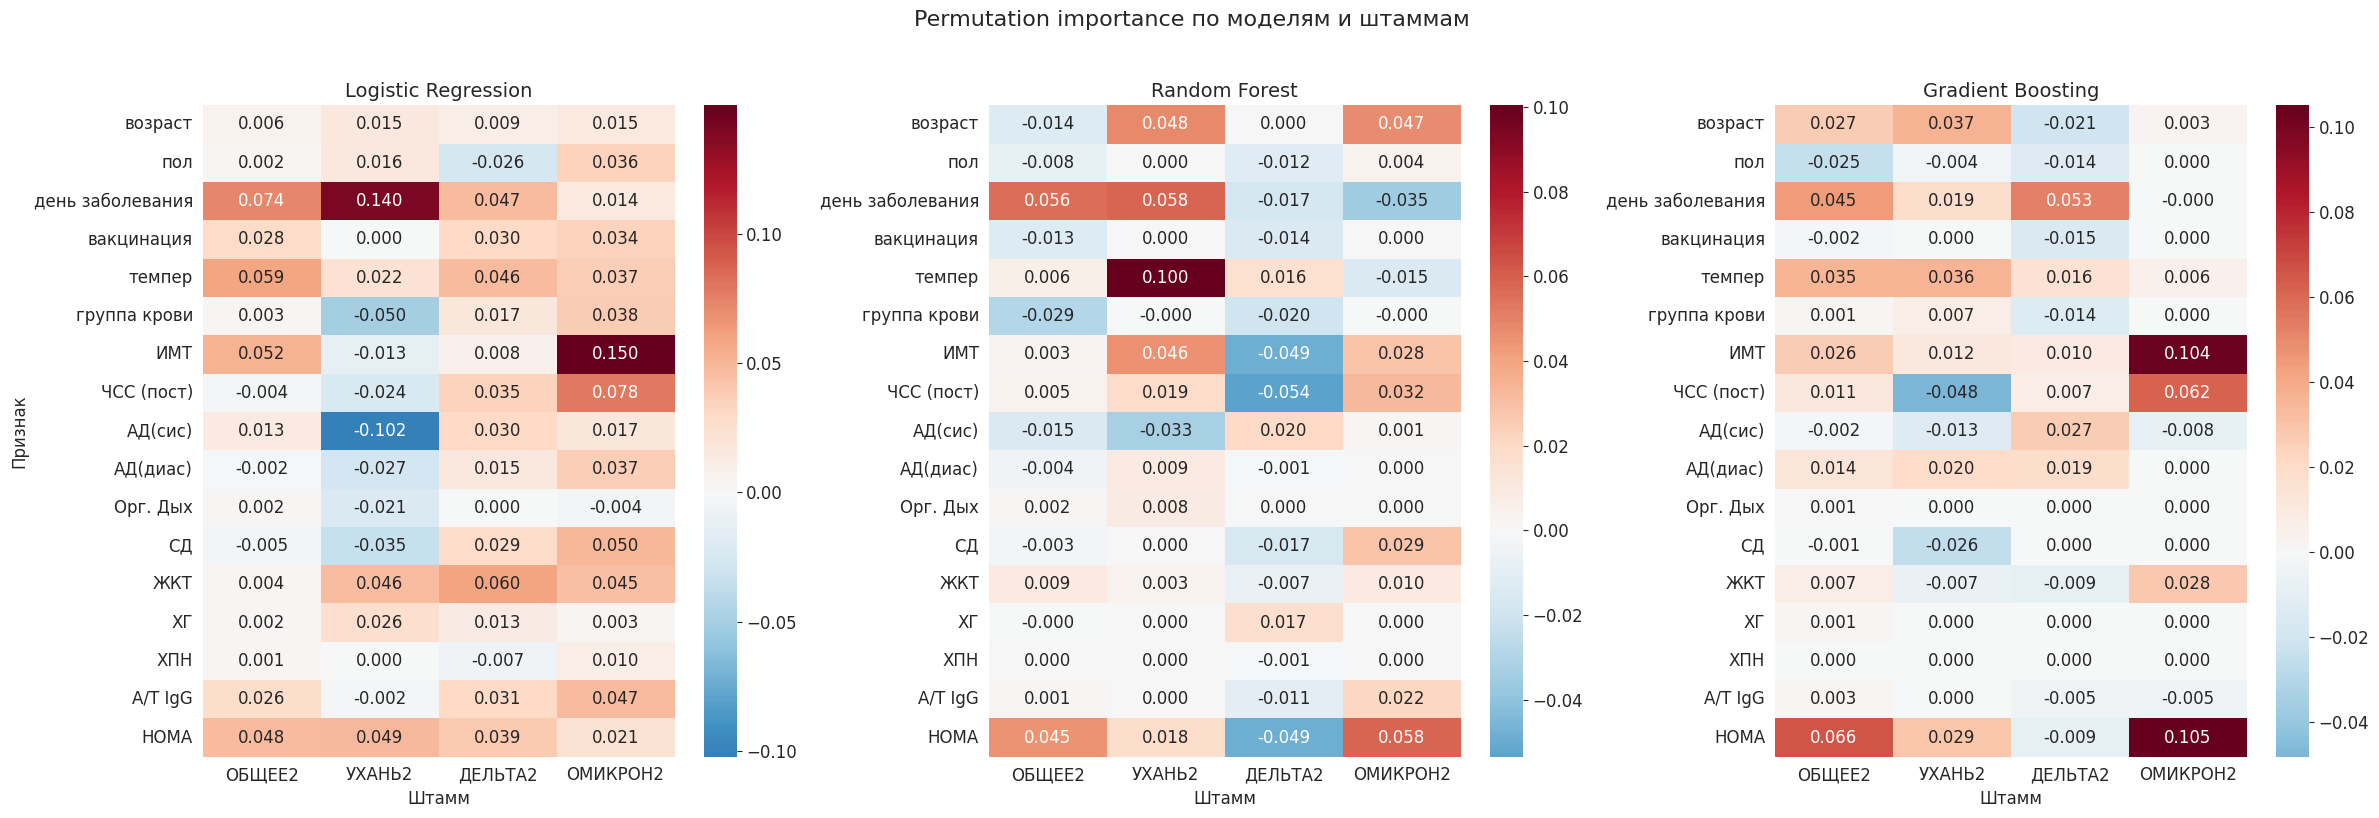

In [30]:
# Heatmap по моделям
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, (model_name, _) in zip(axes, model_dicts_for_perm):
    imp_df = pd.DataFrame(perm_results[model_name])
    sns.heatmap(imp_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax)
    ax.set_title(f'{model_name}', fontsize=14)
    ax.set_ylabel('Признак' if ax == axes[0] else '')
    ax.set_xlabel('Штамм')
fig.suptitle('Permutation importance по моделям и штаммам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 10.2 Консенсус-важность (среднее по LR, RF, GB)

Усредняем permutation importance по трём моделям для каждого штамма — это финальная оценка значимости признаков.

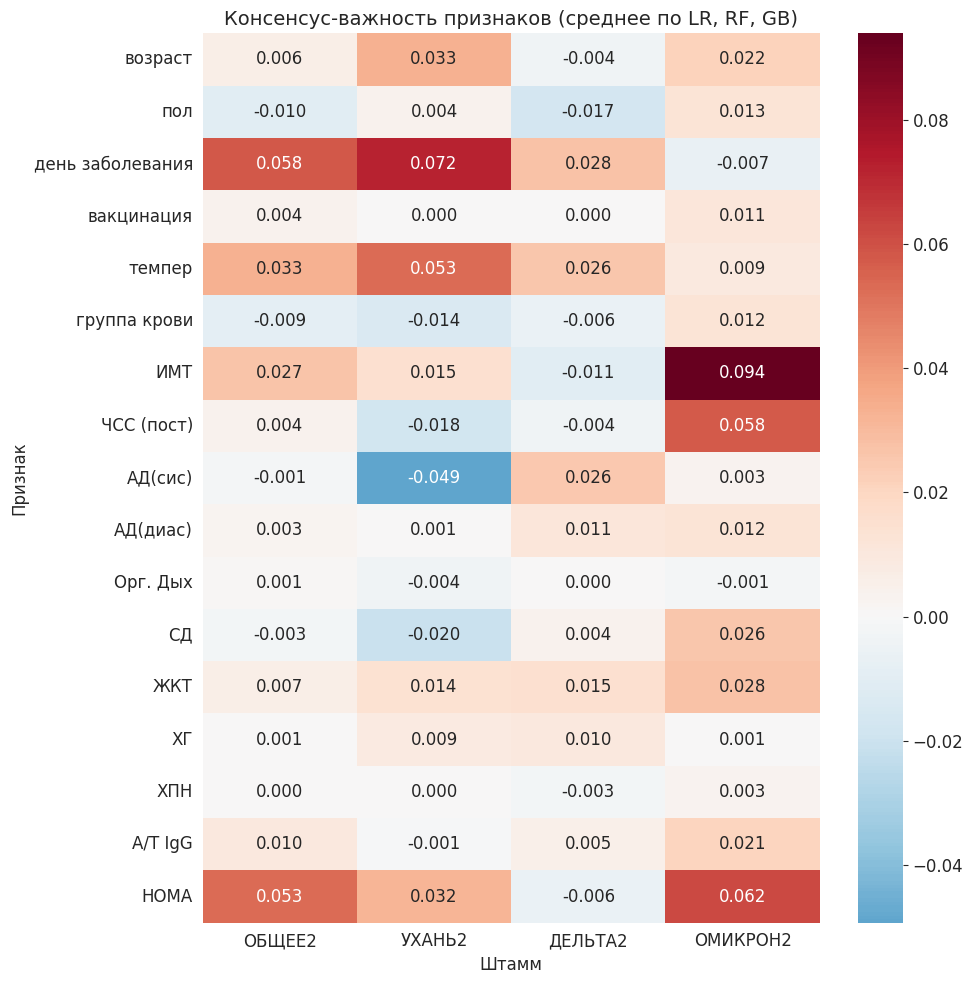


Топ-5 признаков по консенсус-важности (среднее по штаммам):
  день заболевания: 0.0377
  HOMA: 0.0351
  ИМТ: 0.0313
  темпер: 0.0304
  ЖКТ: 0.0158


In [31]:
# Усреднение permutation importance по трём моделям (LR, RF, GB)
consensus_imp = pd.DataFrame(index=feature_cols, columns=SHEET_NAMES, dtype=float)
for name in SHEET_NAMES:
    arr = np.mean([perm_results[m][name].values for m, _ in model_dicts_for_perm], axis=0)
    consensus_imp[name] = arr

# Heatmap
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(consensus_imp, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Консенсус-важность признаков (среднее по LR, RF, GB)', fontsize=14)
ax.set_xlabel('Штамм')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

# Топ-5 признаков по среднему по штаммам
print('\nТоп-5 признаков по консенсус-важности (среднее по штаммам):')
overall_imp = consensus_imp.mean(axis=1).sort_values(ascending=False)
for feat, val in overall_imp.head(5).items():
    print(f'  {feat}: {val:.4f}')

### 10.3 Group permutation importance

Перемешиваем **группы коррелированных признаков совместно**. Это решает проблему «ложно-нулевой важности» из-за коллинеарности: если HOMA, СД и ИМТ несут общий сигнал метаболического синдрома, мы измеряем важность всей группы, а не каждого признака отдельно.

**Группы (на основе медицинской логики и корреляций):**
- **Метаболическая**: HOMA, СД, ИМТ
- **Гемодинамическая**: ЧСС, АД(сис), АД(диас)
- **Демография**: возраст, пол, группа крови
- **Клиническая фаза**: день заболевания, темпер, вакцинация
- **Коморбидности**: Орг. Дых, ЖКТ, ХГ, ХПН

Logistic Regression: готово


Random Forest: готово


Gradient Boosting: готово


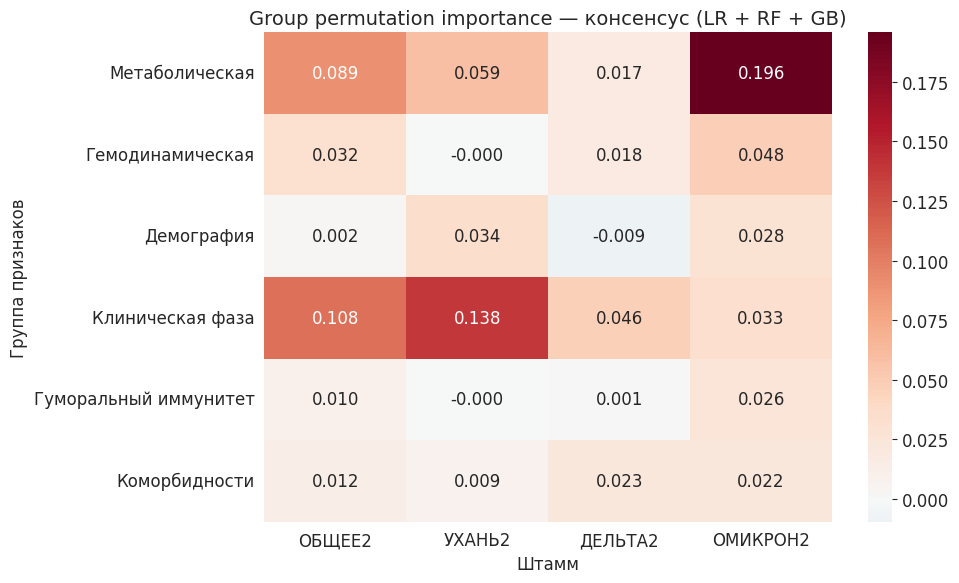


Топ групп по среднему по штаммам:
  Метаболическая: 0.0903
  Клиническая фаза: 0.0816
  Гемодинамическая: 0.0245
  Коморбидности: 0.0166
  Демография: 0.0136
  Гуморальный иммунитет: 0.0093


In [32]:
FEATURE_GROUPS = {
    'Метаболическая': ['HOMA', 'СД', 'ИМТ'],
    'Гемодинамическая': ['ЧСС (пост)', 'АД(сис)', 'АД(диас)'],
    'Демография': ['возраст', 'пол', 'группа крови'],
    'Клиническая фаза': ['день заболевания', 'темпер', 'вакцинация'],
    'Гуморальный иммунитет': ['А/Т IgG'],
    'Коморбидности': ['Орг. Дых', 'ЖКТ', 'ХГ', 'ХПН']
}

from sklearn.metrics import f1_score

def group_permutation_importance(model, X, y, groups, n_repeats=20, random_state=42):
    """Перемешивает все признаки в группе одновременно и измеряет падение F1_weighted."""
    rng = np.random.default_rng(random_state)
    baseline = f1_score(y, model.predict(X), average='weighted')
    result = {}
    for group_name, group_feats in groups.items():
        cols = [c for c in group_feats if c in X.columns]
        if not cols:
            continue
        scores = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            idx = rng.permutation(len(X_perm))
            X_perm[cols] = X_perm[cols].iloc[idx].values
            scores.append(f1_score(y, model.predict(X_perm), average='weighted'))
        result[group_name] = baseline - np.mean(scores)
    return pd.Series(result)

# Расчёт по моделям и штаммам
group_perm_results = {}
for model_name, model_dict in model_dicts_for_perm:
    group_perm_results[model_name] = {}
    for name in SHEET_NAMES:
        _, X_test, _, y_test = splits[name]
        group_perm_results[model_name][name] = group_permutation_importance(
            model_dict[name], X_test, y_test, FEATURE_GROUPS,
            n_repeats=20, random_state=RANDOM_STATE
        )
    print(f'{model_name}: готово')

# Консенсус: среднее по моделям
group_consensus = pd.DataFrame(
    index=list(FEATURE_GROUPS.keys()), columns=SHEET_NAMES, dtype=float
)
for name in SHEET_NAMES:
    arr = np.mean([group_perm_results[m][name].values for m, _ in model_dicts_for_perm], axis=0)
    group_consensus[name] = arr

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(group_consensus, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Group permutation importance — консенсус (LR + RF + GB)', fontsize=14)
ax.set_xlabel('Штамм')
ax.set_ylabel('Группа признаков')
plt.tight_layout()
plt.show()

print('\nТоп групп по среднему по штаммам:')
overall = group_consensus.mean(axis=1).sort_values(ascending=False)
for grp, val in overall.items():
    print(f'  {grp}: {val:.4f}')

### 10.4 Drop-column importance

Самая «честная» оценка важности: для каждого признака **переобучаем** модель без него и измеряем падение F1 на тесте. Гиперпараметры берём из ранее подобранных моделей (без повторного GridSearch — иначе расчёт занял бы часы).

Drop-column importance даёт абсолютную оценку **уникального** вклада признака. В отличие от permutation, она не страдает от артефактов перемешивания, но всё ещё может занижать важность коллинеарных признаков (модель компенсирует через корреляты).

Logistic Regression: готово


Random Forest: готово


Gradient Boosting: готово


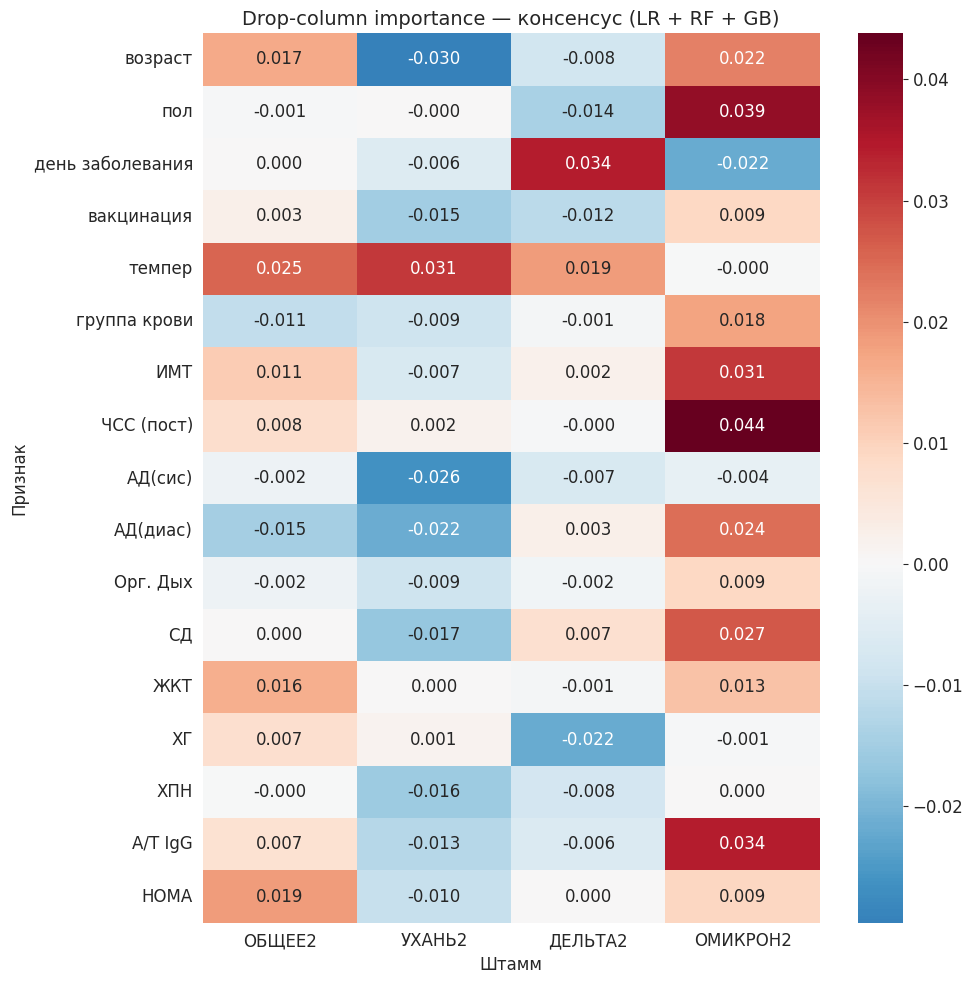


Топ-5 признаков по drop-column importance (среднее по штаммам):
  темпер: 0.0187
  ЧСС (пост): 0.0133
  ИМТ: 0.0093
  ЖКТ: 0.0070
  пол: 0.0060


In [33]:
def drop_column_importance(base_estimator, X_train, y_train, X_test, y_test,
                            features, use_sample_weight=False):
    """Drop-column importance: переобучает модель без каждого признака."""
    # Baseline: обучить на всех признаках
    est_full = clone(base_estimator)
    if use_sample_weight:
        sw = compute_sample_weight('balanced', y_train)
        est_full.fit(X_train, y_train, sample_weight=sw)
    else:
        est_full.fit(X_train, y_train)
    baseline = f1_score(y_test, est_full.predict(X_test), average='weighted')

    importances = {}
    for feat in features:
        cols = [c for c in features if c != feat]
        est = clone(base_estimator)
        if use_sample_weight:
            est.fit(X_train[cols], y_train, sample_weight=sw)
        else:
            est.fit(X_train[cols], y_train)
        score = f1_score(y_test, est.predict(X_test[cols]), average='weighted')
        importances[feat] = baseline - score
    return pd.Series(importances)

drop_col_results = {}
for model_name, model_dict in model_dicts_for_perm:
    drop_col_results[model_name] = {}
    use_sw = (model_name == 'Gradient Boosting')
    for name in SHEET_NAMES:
        X_train, X_test, y_train, y_test = splits[name]
        drop_col_results[model_name][name] = drop_column_importance(
            model_dict[name], X_train, y_train, X_test, y_test,
            list(feature_cols), use_sample_weight=use_sw
        )
    print(f'{model_name}: готово')

# Консенсус: среднее по моделям
drop_col_consensus = pd.DataFrame(index=feature_cols, columns=SHEET_NAMES, dtype=float)
for name in SHEET_NAMES:
    arr = np.mean([drop_col_results[m][name].values for m, _ in model_dicts_for_perm], axis=0)
    drop_col_consensus[name] = arr

# Heatmap
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(drop_col_consensus, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Drop-column importance — консенсус (LR + RF + GB)', fontsize=14)
ax.set_xlabel('Штамм')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

print('\nТоп-5 признаков по drop-column importance (среднее по штаммам):')
overall = drop_col_consensus.mean(axis=1).sort_values(ascending=False)
for feat, val in overall.head(5).items():
    print(f'  {feat}: {val:.4f}')

### 10.5 Сводная таблица: четыре метрики важности

Сравним все метрики важности рядом, чтобы выявить устойчивые признаки и эффекты коллинеарности.

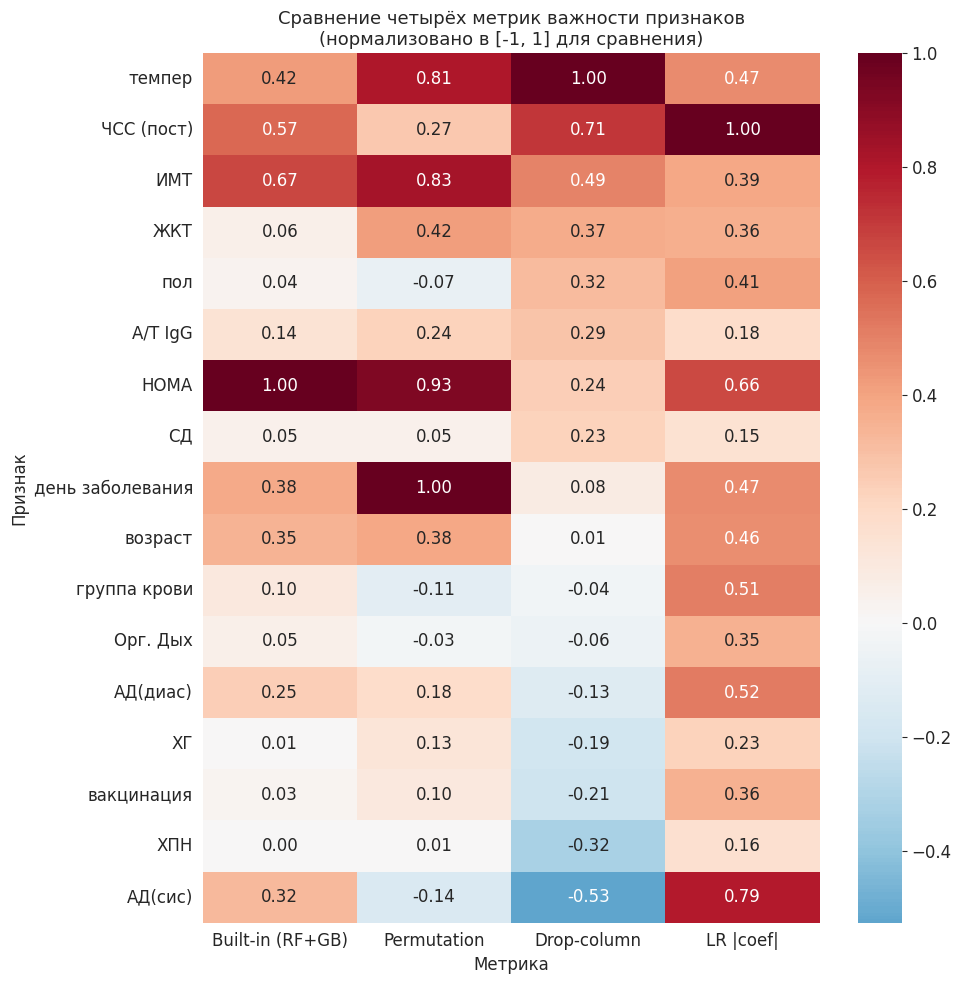


Исходные значения (без нормализации):


,Built-in (RF+GB),Permutation,Drop-column,LR |coef|
темпер,0.0952,0.0304,0.0187,0.6425
ЧСС (пост),0.1292,0.0101,0.0133,1.3547
ИМТ,0.1498,0.0313,0.0093,0.5273
ЖКТ,0.0125,0.0158,0.0070,0.4881
пол,0.0080,-0.0025,0.0060,0.5550
А/Т IgG,0.0322,0.0089,0.0054,0.2458
HOMA,0.2252,0.0351,0.0046,0.8877
СД,0.0108,0.0018,0.0043,0.2080
день заболевания,0.0850,0.0377,0.0015,0.6417
возраст,0.0788,0.0144,0.0002,0.6267


In [34]:
# Сводная таблица: важность каждого признака по 4 метрикам (среднее по штаммам)
summary = pd.DataFrame(index=feature_cols)

# 1. Built-in (среднее RF + GB; LR не имеет feature_importances_)
builtin = np.mean([
    np.mean([rf_models[s].feature_importances_ for s in SHEET_NAMES], axis=0),
    np.mean([gb_models[s].feature_importances_ for s in SHEET_NAMES], axis=0)
], axis=0)
summary['Built-in (RF+GB)'] = builtin

# 2. Permutation (среднее по штаммам)
summary['Permutation'] = consensus_imp.mean(axis=1)

# 3. Drop-column (среднее по штаммам)
summary['Drop-column'] = drop_col_consensus.mean(axis=1)

# 4. LR коэффициенты (среднее |coef| по штаммам)
lr_coefs = np.mean([
    np.abs(lr_models[s].named_steps['classifier'].coef_).mean(axis=0)
    for s in SHEET_NAMES
], axis=0)
summary['LR |coef|'] = lr_coefs

# Нормализуем все метрики в [0, 1] для удобства сравнения
summary_norm = summary.copy()
for col in summary_norm.columns:
    vmax = summary_norm[col].abs().max()
    if vmax > 0:
        summary_norm[col] = summary_norm[col] / vmax

summary_norm = summary_norm.sort_values('Drop-column', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(summary_norm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Сравнение четырёх метрик важности признаков\n(нормализовано в [-1, 1] для сравнения)', fontsize=13)
ax.set_xlabel('Метрика')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

print('\nИсходные значения (без нормализации):')
display(summary.sort_values('Drop-column', ascending=False).round(4))

## 11. SHAP — индивидуальные и глобальные объяснения

**SHAP** (SHapley Additive exPlanations) основан на теории кооперативных игр: каждый признак — игрок, его SHAP-значение — справедливый предельный вклад в предсказание. Это единственный метод, удовлетворяющий аксиомам эффективности, симметрии, аддитивности и линейности одновременно.

**В отличие от permutation importance**, SHAP позволяет:
- объяснить **отдельное предсказание** для конкретного пациента (waterfall plot)
- показать **направление** влияния признака (повышает/понижает риск)
- использовать TreeSHAP — точный и быстрый алгоритм для tree-based моделей

Считаем SHAP для **Random Forest** через TreeSHAP. Для multiclass GradientBoostingClassifier текущая версия SHAP не поддерживает TreeSHAP, поэтому ограничиваемся одной моделью.

In [35]:
import shap

# Расчёт SHAP-значений для Random Forest по всем штаммам
shap_data = {}

for name in SHEET_NAMES:
    _, X_test, _, _ = splits[name]
    explainer = shap.TreeExplainer(rf_models[name])
    sv = explainer.shap_values(X_test)
    shap_data[name] = {
        'shap_values': sv,
        'X_test': X_test,
        'expected_value': explainer.expected_value
    }
    print(f'{name}: shape={np.array(sv).shape}')

ОБЩЕЕ2: shape=(129, 17, 5)
УХАНЬ2: shape=(43, 17, 5)
ДЕЛЬТА2: shape=(55, 17, 5)
ОМИКРОН2: shape=(33, 17, 4)


### 11.1 Глобальная SHAP-важность по штаммам

Сравнение глобальной SHAP-важности (среднее модуля SHAP-значений) с уже рассчитанными метриками. Видно направление и распределение вклада признаков.

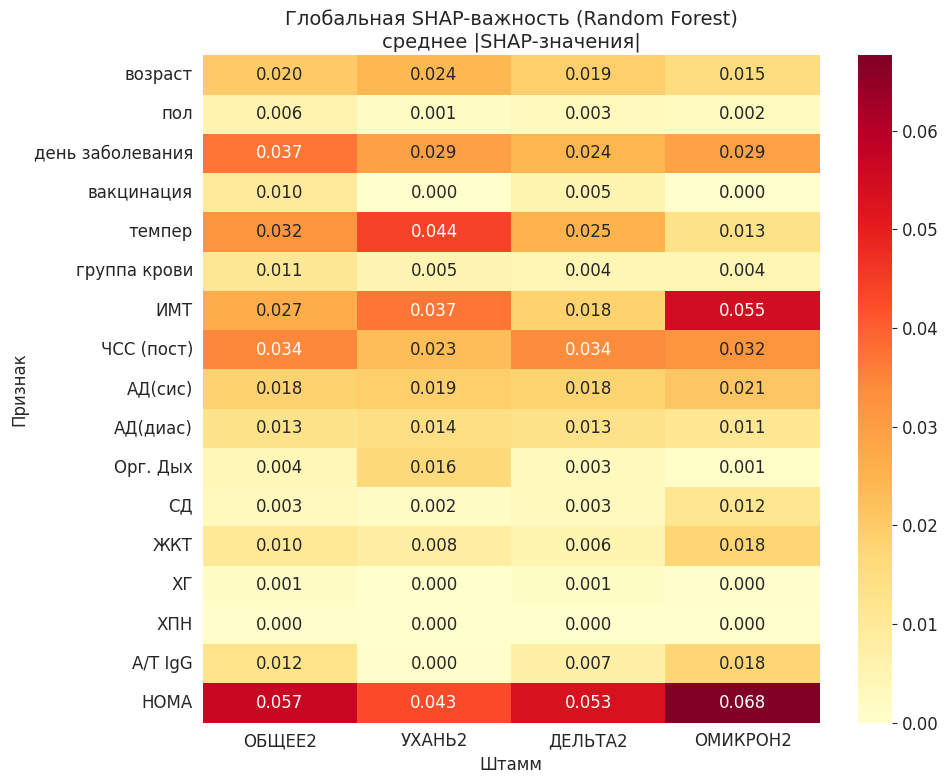


Топ-5 признаков по SHAP-важности (среднее по штаммам):
  HOMA: 0.0551
  ИМТ: 0.0341
  ЧСС (пост): 0.0309
  день заболевания: 0.0299
  темпер: 0.0287


In [36]:
# Расчёт глобальной важности через SHAP: среднее |shap_value| по всем классам и образцам
def aggregate_shap(sv, n_features):
    """Агрегирует SHAP-значения для multiclass: возвращает (n_features,) — среднее |SHAP|."""
    arr = np.array(sv)
    if arr.ndim == 3:
        # Format: (n_samples, n_features, n_classes) — sklearn 1.x
        if arr.shape[1] == n_features:
            return np.abs(arr).mean(axis=(0, 2))
        # Format: (n_classes, n_samples, n_features) — старые версии
        elif arr.shape[2] == n_features:
            return np.abs(arr).mean(axis=(0, 1))
    elif isinstance(sv, list):
        return np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    return np.abs(arr).mean(axis=0)

shap_global_imp = pd.DataFrame(index=feature_cols, columns=SHEET_NAMES, dtype=float)
for name in SHEET_NAMES:
    sv = shap_data[name]['shap_values']
    shap_global_imp[name] = aggregate_shap(sv, len(feature_cols))

fig, ax = plt.subplots(figsize=(10, max(8, len(feature_cols) * 0.4)))
sns.heatmap(shap_global_imp, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Глобальная SHAP-важность (Random Forest)\nсреднее |SHAP-значения|', fontsize=14)
ax.set_xlabel('Штамм')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

print('\nТоп-5 признаков по SHAP-важности (среднее по штаммам):')
overall = shap_global_imp.mean(axis=1).sort_values(ascending=False)
for feat, val in overall.head(5).items():
    print(f'  {feat}: {val:.4f}')

### 11.2 Summary plots — направление влияния признаков

В отличие от bar-чарта, **beeswarm summary plot** показывает каждого пациента (точку) и направление влияния. Цвет — значение признака (красный = высокое, синий = низкое); ось X — SHAP-значение (вклад в предсказание).

Покажем для **ОБЩЕЕ2** (наибольшая выборка) для класса **КТ-3** (тяжёлое поражение) — какие признаки повышают/понижают риск тяжёлого исхода.

SHAP summary для класса КТ-3 (Random Forest, ОБЩЕЕ2)


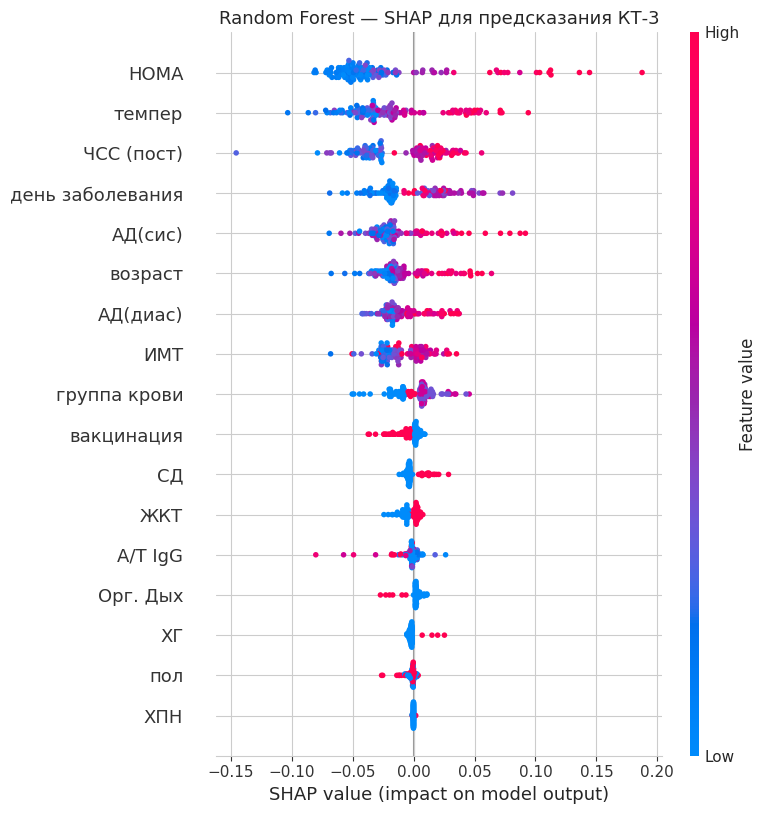

In [37]:
# Summary plot для класса КТ-3 (тяжёлое поражение) на ОБЩЕЕ2
TARGET_CLASS = 3

sv = shap_data['ОБЩЕЕ2']['shap_values']
X_test = shap_data['ОБЩЕЕ2']['X_test']
arr = np.array(sv)
n_feat = len(feature_cols)

# Извлекаем SHAP-значения для класса TARGET_CLASS
if arr.ndim == 3:
    if arr.shape[1] == n_feat:  # (n_samples, n_features, n_classes)
        sv_class = arr[:, :, min(TARGET_CLASS, arr.shape[2]-1)]
    else:  # (n_classes, n_samples, n_features)
        sv_class = arr[min(TARGET_CLASS, arr.shape[0]-1)]
elif isinstance(sv, list):
    sv_class = sv[min(TARGET_CLASS, len(sv)-1)]
else:
    sv_class = arr

print(f'SHAP summary для класса КТ-{TARGET_CLASS} (Random Forest, ОБЩЕЕ2)')
fig = plt.figure(figsize=(10, max(8, n_feat * 0.35)))
shap.summary_plot(sv_class, X_test, feature_names=list(feature_cols), show=False)
plt.title(f'Random Forest — SHAP для предсказания КТ-{TARGET_CLASS}', fontsize=13)
plt.tight_layout()
plt.show()

### 11.3 Индивидуальные объяснения (waterfall plots)

Самое практически ценное применение SHAP — объяснение конкретного предсказания. **Waterfall plot** показывает, как каждый признак двигает предсказание от базового ожидания (среднего по выборке) к итоговому значению для данного пациента.

Покажем 5 примеров из ОБЩЕЕ2: пациент с КТ-0 (норма), КТ-1 (минимальное), КТ-2 (умеренное), КТ-3 (тяжёлое), КТ-4 (критическое) — на модели Random Forest. Класс КТ-4 представлен в выборке очень редко (1–4 пациента в test), поэтому если в test-выборке нет такого пациента, ищем его в train (SHAP пересчитываем по запросу).


=== Пациент 6 (test) с истинным классом КТ-0 ===


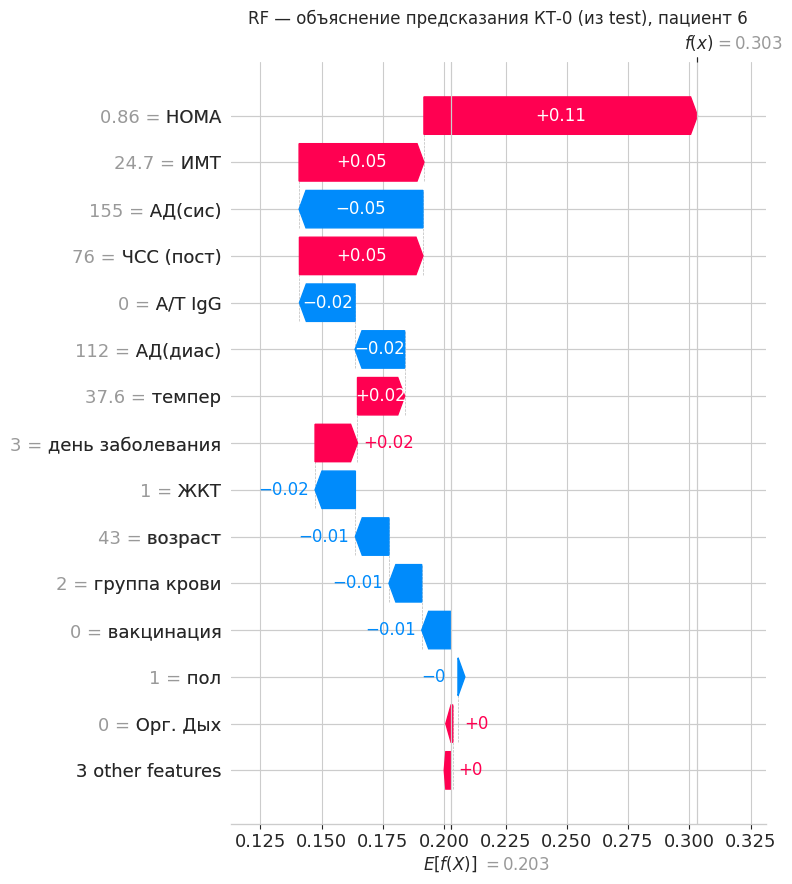


=== Пациент 1 (test) с истинным классом КТ-1 ===


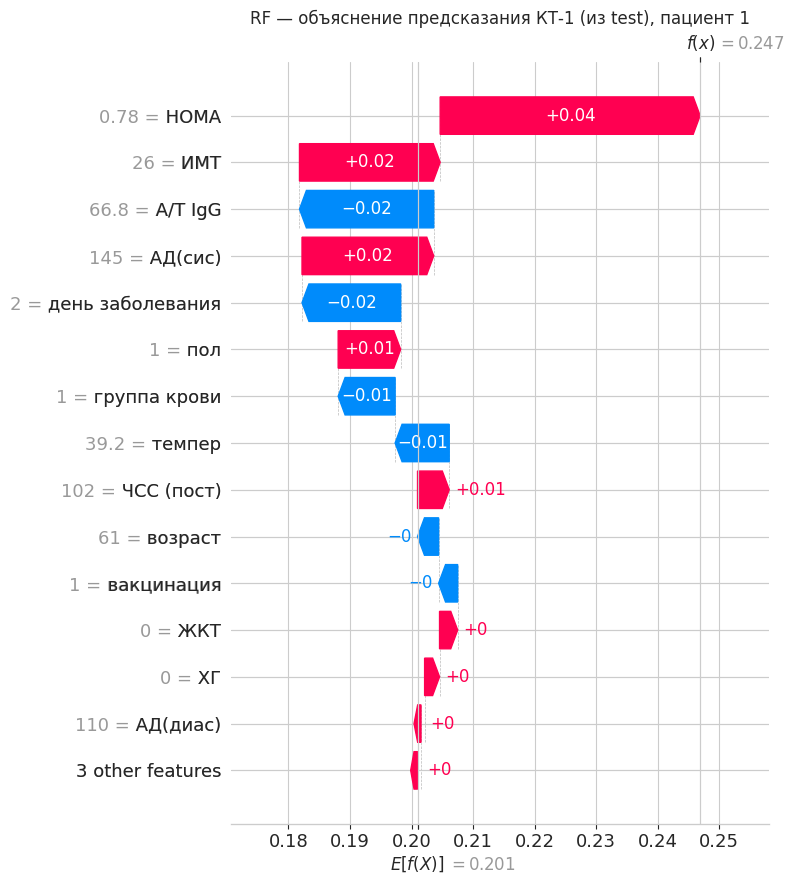


=== Пациент 0 (test) с истинным классом КТ-2 ===


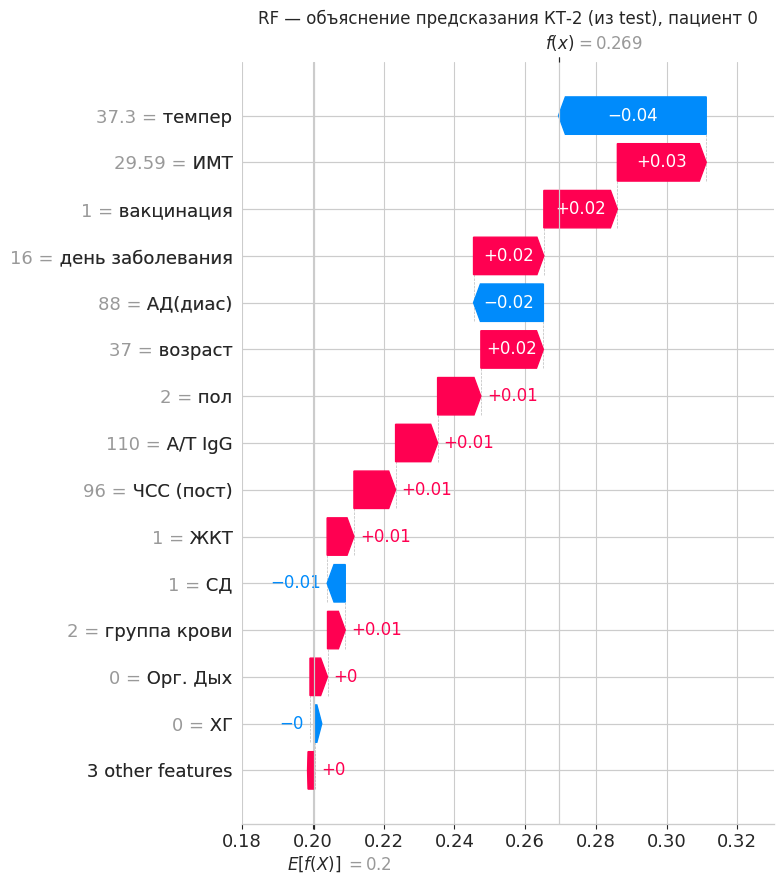


=== Пациент 2 (test) с истинным классом КТ-3 ===


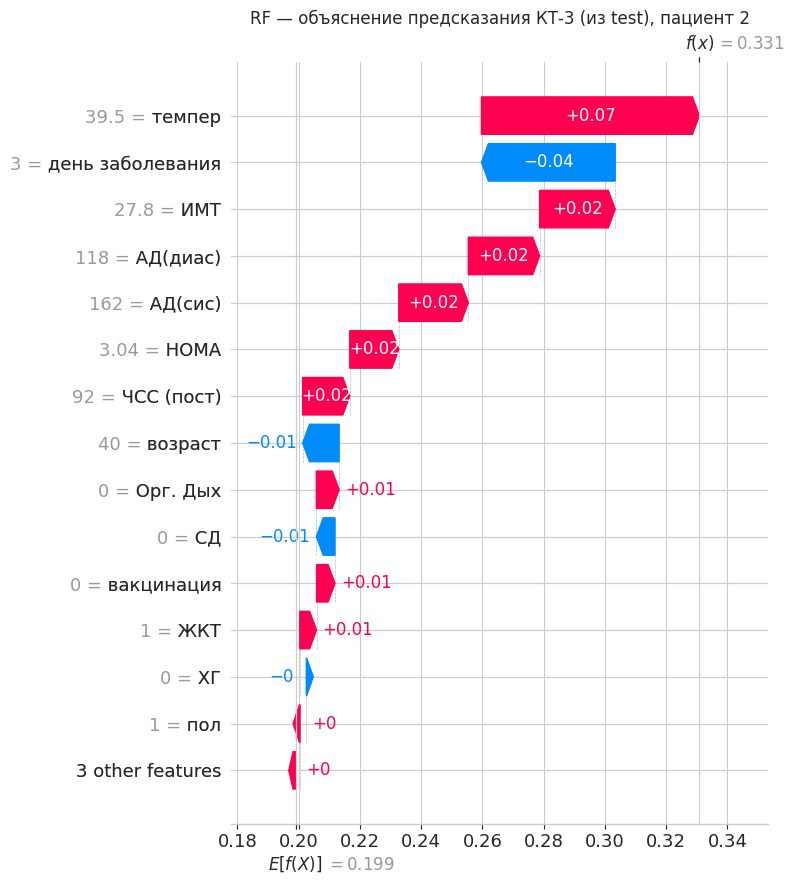


=== Пациент 46 (test) с истинным классом КТ-4 ===


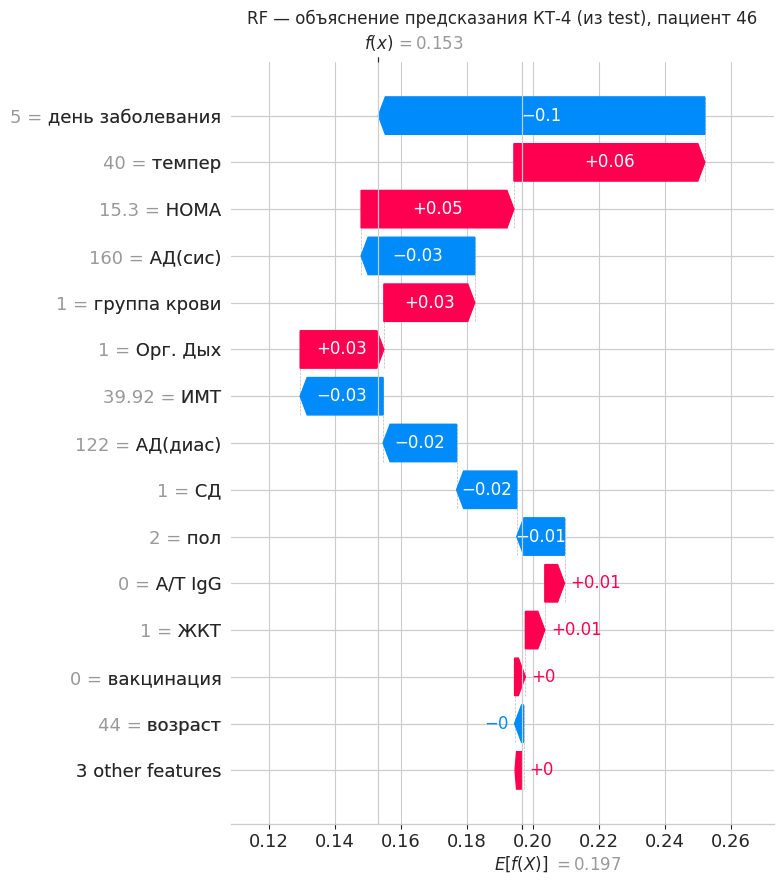

In [38]:
# Waterfall plots: 5 типичных пациентов из ОБЩЕЕ2 (по одному на класс КТ-0..КТ-4)
X_train_общ, X_test, y_train_общ, y_test = splits['ОБЩЕЕ2']
sv = shap_data['ОБЩЕЕ2']['shap_values']
expected = shap_data['ОБЩЕЕ2']['expected_value']
arr = np.array(sv)
exp_arr = np.array(expected) if not np.isscalar(expected) else expected
n_feat = len(feature_cols)

# Поиск примера: сначала в test, при отсутствии — в train (с пересчётом SHAP для одного объекта)
def find_example(cls):
    mask_test = (y_test.values == cls)
    if mask_test.any():
        return 'test', np.where(mask_test)[0][0], None
    mask_train = (y_train_общ.values == cls)
    if mask_train.any():
        train_idx = np.where(mask_train)[0][0]
        return 'train', train_idx, X_train_общ.iloc[[train_idx]]
    return None, None, None

examples = {cls: find_example(cls) for cls in [0, 1, 2, 3, 4]}

# Если для какого-то класса пример найден только в train — пересчитаем SHAP под него
extra_explainer = None
for cls, (src, idx, X_one) in examples.items():
    if src is None:
        print(f'  КТ-{cls}: пример отсутствует и в test, и в train — пропуск')
        continue

    if src == 'test':
        if arr.ndim == 3:
            if arr.shape[1] == n_feat:
                class_idx = min(cls, arr.shape[2] - 1)
                patient_shap = arr[idx, :, class_idx]
            else:
                class_idx = min(cls, arr.shape[0] - 1)
                patient_shap = arr[class_idx, idx, :]
        elif isinstance(sv, list):
            class_idx = min(cls, len(sv) - 1)
            patient_shap = sv[class_idx][idx]
        else:
            patient_shap = arr[idx]
            class_idx = 0
        data_row = X_test.iloc[idx].values
    else:
        if extra_explainer is None:
            extra_explainer = shap.TreeExplainer(rf_models['ОБЩЕЕ2'])
        sv_one = extra_explainer.shap_values(X_one)
        arr_one = np.array(sv_one)
        if arr_one.ndim == 3:
            if arr_one.shape[1] == n_feat:
                class_idx = min(cls, arr_one.shape[2] - 1)
                patient_shap = arr_one[0, :, class_idx]
            else:
                class_idx = min(cls, arr_one.shape[0] - 1)
                patient_shap = arr_one[class_idx, 0, :]
        elif isinstance(sv_one, list):
            class_idx = min(cls, len(sv_one) - 1)
            patient_shap = sv_one[class_idx][0]
        else:
            patient_shap = arr_one[0]
            class_idx = 0
        data_row = X_one.values[0]

    if hasattr(exp_arr, '__len__'):
        base = float(exp_arr[class_idx])
    else:
        base = float(exp_arr)

    print(f'\n=== Пациент {idx} ({src}) с истинным классом КТ-{cls} ===')

    explanation = shap.Explanation(
        values=patient_shap,
        base_values=base,
        data=data_row,
        feature_names=list(feature_cols)
    )
    fig = plt.figure(figsize=(10, max(6, n_feat * 0.3)))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    suffix = f' (из {src})'
    plt.title(f'RF — объяснение предсказания КТ-{cls}{suffix}, пациент {idx}', fontsize=12)
    plt.tight_layout()
    plt.show()

### 11.4 Сравнение SHAP с другими метриками важности

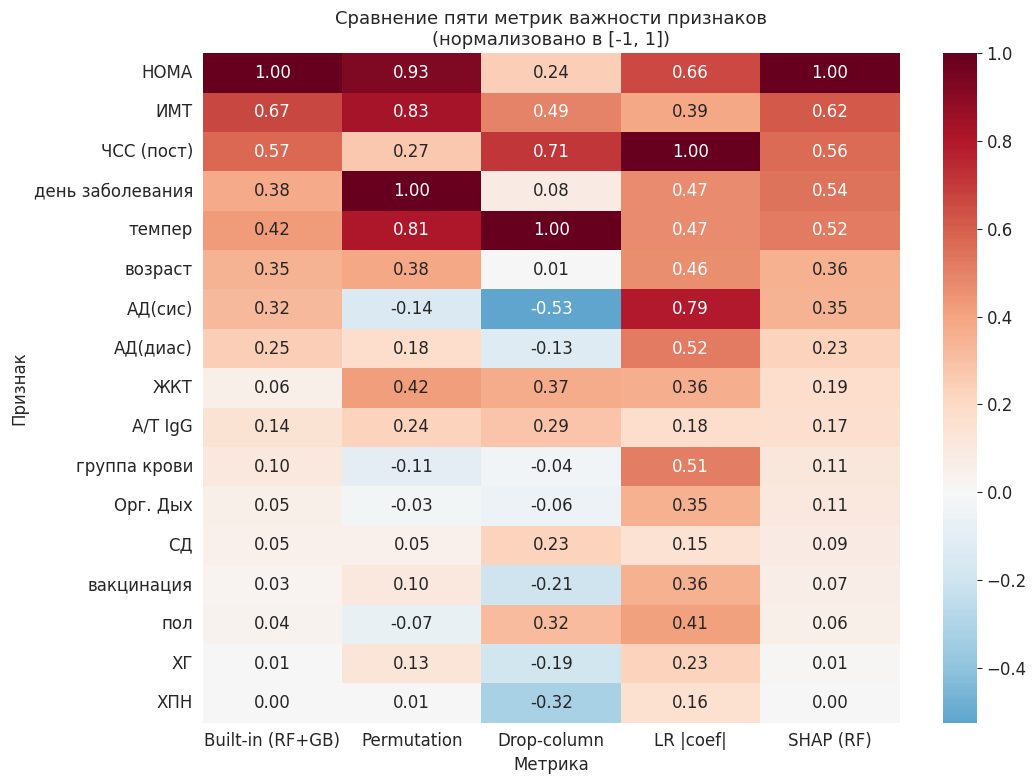


Исходные значения (отсортировано по SHAP):


,Built-in (RF+GB),Permutation,Drop-column,LR |coef|,SHAP (RF)
HOMA,0.2252,0.0351,0.0046,0.8877,0.0551
ИМТ,0.1498,0.0313,0.0093,0.5273,0.0341
ЧСС (пост),0.1292,0.0101,0.0133,1.3547,0.0309
день заболевания,0.0850,0.0377,0.0015,0.6417,0.0299
темпер,0.0952,0.0304,0.0187,0.6425,0.0287
возраст,0.0788,0.0144,0.0002,0.6267,0.0196
АД(сис),0.0727,-0.0054,-0.0098,1.0725,0.0192
АД(диас),0.0553,0.0068,-0.0024,0.7065,0.0129
ЖКТ,0.0125,0.0158,0.0070,0.4881,0.0104
А/Т IgG,0.0322,0.0089,0.0054,0.2458,0.0094


In [39]:
# Добавляем SHAP к сводной таблице метрик
summary_with_shap = summary.copy()
summary_with_shap['SHAP (RF)'] = shap_global_imp.mean(axis=1)

# Нормализуем для сравнения
summary_norm_shap = summary_with_shap.copy()
for col in summary_norm_shap.columns:
    vmax = summary_norm_shap[col].abs().max()
    if vmax > 0:
        summary_norm_shap[col] = summary_norm_shap[col] / vmax

summary_norm_shap = summary_norm_shap.sort_values('SHAP (RF)', ascending=False)

fig, ax = plt.subplots(figsize=(11, max(8, len(feature_cols) * 0.4)))
sns.heatmap(summary_norm_shap, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Сравнение пяти метрик важности признаков\n(нормализовано в [-1, 1])', fontsize=13)
ax.set_xlabel('Метрика')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

print('\nИсходные значения (отсортировано по SHAP):')
display(summary_with_shap.sort_values('SHAP (RF)', ascending=False).round(4))

## 12. Эмпирическая формула для КТ(max)

В отличие от классификации (КТ(ИТОГ), 5 классов), здесь используем **числовую переменную КТ(max)** (столбец AN, 0–95% поражения лёгких) — это позволит вывести **одну компактную линейную формулу** для расчёта степени поражения, которую может применить врач у постели пациента.

**План:**
1. Обучаем Ridge-регрессию на стандартизованных признаках (даёт устойчивые коэффициенты при коллинеарности)
2. Выводим формулу в двух видах: стандартизованная (для сравнения значимости признаков) и в исходных единицах (для практического применения)
3. Валидация: R², MAE, scatter plot предсказание vs истинное значение
4. Конвертация числового предсказания в категории КТ(ИТОГ) по медицинским порогам — сравнение с реальной классификацией
5. Упрощённая формула из топ-5 признаков (для запоминания)

In [40]:
# Загрузка КТ(max) — числовой target
KT_MAX_IDX = 39  # AN — КТ(МАКС)

reg_splits = {}
for sheet in SHEET_NAMES:
    df_raw = pd.read_excel(FILE_PATH, sheet_name=sheet)
    df = df_raw.iloc[:, FEATURE_COLS_IDX + [KT_MAX_IDX]].copy()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')

    feat_cols_reg = list(df.columns[:-1])
    target_reg = df.columns[-1]

    X = df[feat_cols_reg].copy()
    y = df[target_reg].copy()
    mask = y.notna()
    X, y = X[mask], y[mask].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    train_median = X_train.median()
    X_train = X_train.fillna(train_median)
    X_test = X_test.fillna(train_median)

    reg_splits[sheet] = (X_train, X_test, y_train, y_test)
    print(f'{sheet:>10s}: train={len(X_train)}, test={len(X_test)}, КТ(max) range [{y.min():.0f}, {y.max():.0f}], mean={y.mean():.1f}')

    ОБЩЕЕ2: train=515, test=129, КТ(max) range [0, 95], mean=18.0


    УХАНЬ2: train=168, test=43, КТ(max) range [0, 95], mean=16.9


   ДЕЛЬТА2: train=217, test=55, КТ(max) range [0, 95], mean=21.9


  ОМИКРОН2: train=128, test=33, КТ(max) range [0, 70], mean=12.7


### 12.1 Обучение и вывод формулы

Для **ОБЩЕЕ2** обучаем Ridge-регрессию (с кросс-валидацией для выбора α). Признаки стандартизуются — это даёт **сопоставимые коэффициенты** (вес признака = его влияние при изменении на 1 стандартное отклонение).

In [41]:
TARGET_SHEET = 'ОБЩЕЕ2'
X_train, X_test, y_train, y_test = reg_splits[TARGET_SHEET]
feat_names = list(X_train.columns)

# Стандартизация
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_test_z = scaler.transform(X_test)

# Ridge с CV-подбором alpha
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge.fit(X_train_z, y_train)

print(f'Выбранная alpha: {ridge.alpha_}')
print(f'Intercept (стандартизованная форма): {ridge.intercept_:.2f}')

# === Стандартизованная формула ===
print(f'\n=== Формула (стандартизованные признаки) ===')
print(f'КТ(max) = {ridge.intercept_:.2f}')
for feat, coef in sorted(zip(feat_names, ridge.coef_), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    print(f'         {sign} {abs(coef):.3f} · z({feat})')
print(f'где z(x) = (x - mean) / std')

# === Формула в исходных единицах ===
# y = a0 + sum(coef_i * (x_i - mean_i) / std_i)
#   = (a0 - sum(coef_i * mean_i / std_i)) + sum(coef_i / std_i * x_i)
real_coefs = ridge.coef_ / scaler.scale_
real_intercept = ridge.intercept_ - np.sum(ridge.coef_ * scaler.mean_ / scaler.scale_)

print(f'\n=== Формула (исходные единицы) ===')
print(f'КТ(max) = {real_intercept:.2f}')
for feat, coef in sorted(zip(feat_names, real_coefs), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    print(f'         {sign} {abs(coef):.4f} · {feat}')

Выбранная alpha: 100.0
Intercept (стандартизованная форма): 17.77

=== Формула (стандартизованные признаки) ===
КТ(max) = 17.77
         + 4.145 · z(HOMA)
         + 4.000 · z(темпер)
         + 3.069 · z(ЧСС (пост))
         + 2.384 · z(день заболевания)
         + 2.030 · z(ЖКТ)
         + 1.937 · z(возраст)
         + 1.820 · z(АД(сис))
         - 1.174 · z(А/Т IgG)
         - 1.114 · z(вакцинация)
         + 1.030 · z(ХГ)
         + 0.866 · z(АД(диас))
         + 0.499 · z(пол)
         + 0.484 · z(ИМТ)
         + 0.414 · z(СД)
         - 0.409 · z(ХПН)
         - 0.337 · z(Орг. Дых)
         - 0.219 · z(группа крови)
где z(x) = (x - mean) / std

=== Формула (исходные единицы) ===
КТ(max) = -216.30
         + 5.6090 · ХГ
         + 4.6913 · темпер
         + 4.1006 · ЖКТ
         - 2.8307 · ХПН
         + 2.4461 · HOMA
         - 2.3163 · вакцинация
         - 1.5139 · Орг. Дых
         + 1.1323 · СД
         + 1.0121 · пол
         + 0.7629 · день заболевания
         - 0.2326 · г

### 12.2 Валидация формулы

Точность в числовой форме: **R²** (доля объяснённой дисперсии), **MAE** (средняя ошибка в %).

R² (test): 0.567
MAE (test): 10.66% поражения лёгких


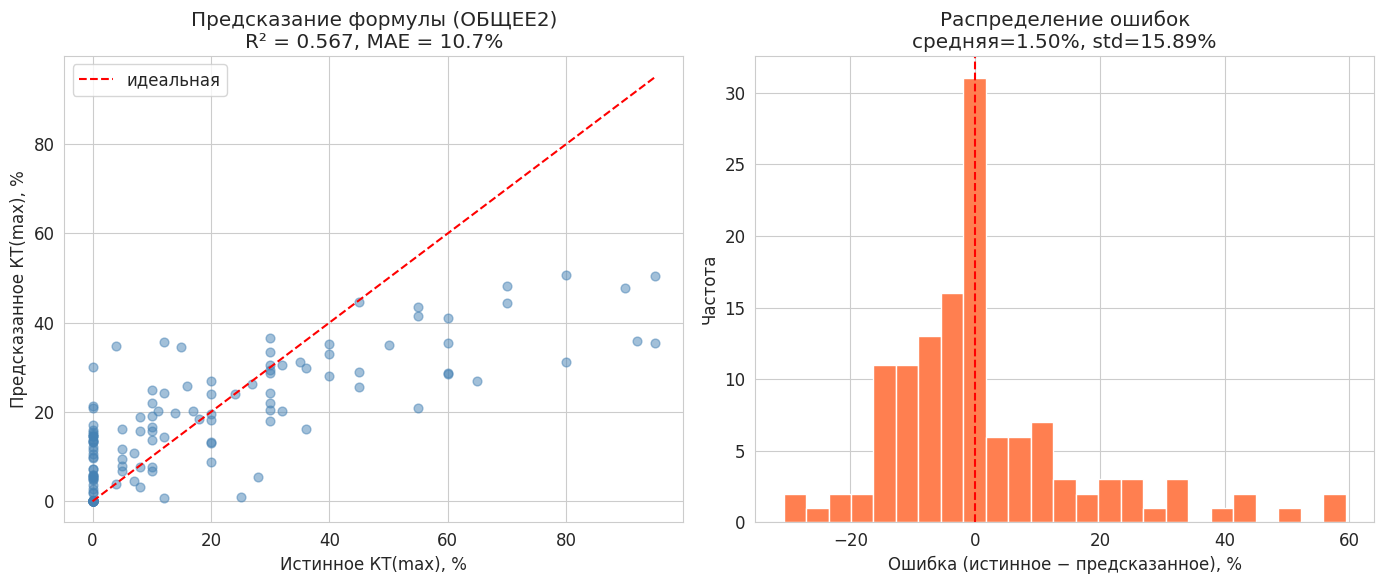

In [42]:
y_pred = ridge.predict(X_test_z)
y_pred = np.clip(y_pred, 0, 100)  # ограничиваем разумным диапазоном

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R² (test): {r2:.3f}')
print(f'MAE (test): {mae:.2f}% поражения лёгких')

# Scatter: предсказанное vs истинное
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.5, s=40, edgecolor='steelblue', facecolor='steelblue')
lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], 'r--', label='идеальная')
ax.set_xlabel('Истинное КТ(max), %')
ax.set_ylabel('Предсказанное КТ(max), %')
ax.set_title(f'Предсказание формулы ({TARGET_SHEET})\nR² = {r2:.3f}, MAE = {mae:.1f}%')
ax.legend()

# Распределение остатков
ax = axes[1]
residuals = y_test - y_pred
ax.hist(residuals, bins=25, color='coral', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Ошибка (истинное − предсказанное), %')
ax.set_ylabel('Частота')
ax.set_title(f'Распределение ошибок\nсредняя={residuals.mean():.2f}%, std={residuals.std():.2f}%')

plt.tight_layout()
plt.show()

### 12.3 Конвертация в категории КТ(ИТОГ)

Применяем стандартные медицинские пороги к предсказанному КТ(max) и сравниваем с реальной КТ(ИТОГ):
- 0% → КТ-0 (норма)
- 1–25% → КТ-1 (минимальное)
- 26–50% → КТ-2 (умеренное)
- 51–75% → КТ-3 (тяжёлое)
- 76–100% → КТ-4 (критическое)

Точность по категориям после конвертации: 0.483

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.18      0.31        11
           1       0.53      0.77      0.62        13
           2       0.29      1.00      0.44         2
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1

    accuracy                           0.48        29
   macro avg       0.36      0.39      0.28        29
weighted avg       0.63      0.48      0.43        29



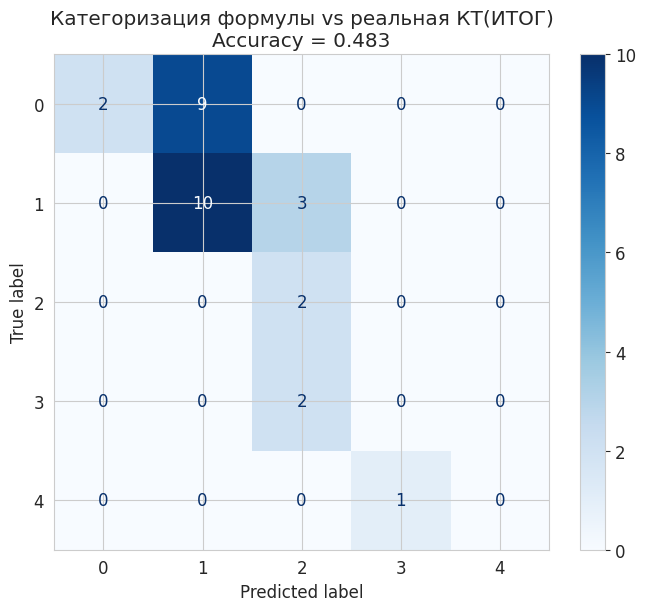


Для сравнения — лучшая модель классификации:
  лучшая classification (RF/GB/LR/DT) на ОБЩЕЕ2: Accuracy = 0.581


In [43]:
def kt_max_to_category(values):
    """Конвертация численного КТ(max) в категорию КТ(ИТОГ)."""
    cats = np.zeros_like(values, dtype=int)
    cats[(values > 0) & (values <= 25)] = 1
    cats[(values > 25) & (values <= 50)] = 2
    cats[(values > 50) & (values <= 75)] = 3
    cats[values > 75] = 4
    return cats

# Истинные КТ(ИТОГ) — берём из splits (классификация)
_, _, _, y_test_cat = splits[TARGET_SHEET]
# Совмещаем индексы: y_test (regression) и y_test_cat должны соответствовать одним пациентам
# Поскольку train_test_split использует один RANDOM_STATE и одни данные — индексы совпадают
common_idx = y_test.index.intersection(y_test_cat.index)
y_test_aligned = y_test.loc[common_idx]
y_test_cat_aligned = y_test_cat.loc[common_idx]
y_pred_aligned = pd.Series(y_pred, index=y_test.index).loc[common_idx]

y_pred_cat = kt_max_to_category(y_pred_aligned.values)

from sklearn.metrics import accuracy_score, classification_report
acc_cat = accuracy_score(y_test_cat_aligned, y_pred_cat)
print(f'Точность по категориям после конвертации: {acc_cat:.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test_cat_aligned, y_pred_cat, zero_division=0))

# Confusion matrix
all_labels = sorted(set(y_test_cat_aligned.unique()) | set(np.unique(y_pred_cat)))
cm = confusion_matrix(y_test_cat_aligned, y_pred_cat, labels=all_labels)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=all_labels).plot(ax=ax, cmap='Blues')
ax.set_title(f'Категоризация формулы vs реальная КТ(ИТОГ)\nAccuracy = {acc_cat:.3f}')
plt.tight_layout()
plt.show()

print('\nДля сравнения — лучшая модель классификации:')
for r in results_summary:
    pass
best_classif_acc = all_results_df[all_results_df['Штамм']==TARGET_SHEET]['Accuracy (test)'].max()
print(f'  лучшая classification (RF/GB/LR/DT) на {TARGET_SHEET}: Accuracy = {best_classif_acc:.3f}')

### 12.4 Упрощённая формула — топ-5 признаков

Для **практического применения** часто нужна формула из 3–5 признаков, которые врач сможет запомнить и применить «у постели». Берём топ-5 по консенсус permutation importance и переобучаем.

In [44]:
# Топ-5 признаков по permutation importance (consensus_imp посчитан в разделе 10)
top5_features = consensus_imp.mean(axis=1).sort_values(ascending=False).head(5).index.tolist()
print(f'Топ-5 признаков: {top5_features}\n')

X_train_top5 = X_train[top5_features]
X_test_top5 = X_test[top5_features]

scaler_simple = StandardScaler()
X_train_top5_z = scaler_simple.fit_transform(X_train_top5)
X_test_top5_z = scaler_simple.transform(X_test_top5)

ridge_simple = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_simple.fit(X_train_top5_z, y_train)

y_pred_simple = np.clip(ridge_simple.predict(X_test_top5_z), 0, 100)
r2_simple = r2_score(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)

# Формула в исходных единицах
real_coefs_simple = ridge_simple.coef_ / scaler_simple.scale_
real_intercept_simple = ridge_simple.intercept_ - np.sum(ridge_simple.coef_ * scaler_simple.mean_ / scaler_simple.scale_)

print(f'=== Упрощённая формула (5 признаков, исходные единицы) ===')
print(f'КТ(max) ≈ {real_intercept_simple:.2f}')
for feat, coef in sorted(zip(top5_features, real_coefs_simple), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    print(f'           {sign} {abs(coef):.3f} · {feat}')

print(f'\nR²:  {r2_simple:.3f}  (полная: {r2:.3f})')
print(f'MAE: {mae_simple:.2f}%  (полная: {mae:.2f}%)')

# Сравнительная таблица
print(f'\n=== Сравнение полной vs упрощённой формулы ===')
comp = pd.DataFrame({
    'Полная (16 признаков)': [r2, mae, len(feat_names)],
    'Упрощённая (5 признаков)': [r2_simple, mae_simple, 5]
}, index=['R²', 'MAE (%)', 'Число признаков']).round(3)
display(comp)

Топ-5 признаков: ['день заболевания', 'HOMA', 'ИМТ', 'темпер', 'ЖКТ']

=== Упрощённая формула (5 признаков, исходные единицы) ===
КТ(max) ≈ -291.68
           + 7.344 · темпер
           + 5.935 · ЖКТ
           + 3.516 · HOMA
           + 1.195 · день заболевания
           + 0.562 · ИМТ

R²:  0.565  (полная: 0.567)
MAE: 10.53%  (полная: 10.66%)

=== Сравнение полной vs упрощённой формулы ===


,Полная (16 признаков),Упрощённая (5 признаков)
R²,0.567,0.565
MAE (%),10.665,10.530
Число признаков,17.000,5.000


### 12.6 Логарифмирование скошенных признаков

Многие лабораторные и метаболические показатели имеют **лог-нормальное распределение** (хвост в сторону больших значений): цитокины, ферритин, д-димер, ЛДГ, СРБ, HOMA. Линейная Ridge-регрессия на исходных значениях недооценивает крайние значения — а именно они отличают тяжёлые случаи КТ-3/КТ-4.

**Идея:** заменить `x` на `log(1 + x)` для признаков с асимметрией > 1.5. Формула остаётся линейной по log-признакам, что клинически интерпретируется как «риск растёт мультипликативно при росте маркера».

In [45]:
from scipy.stats import skew

# Авто-детекция скошенных признаков по skewness > 1.5 (только неотрицательные)
log_features = []
for col in X_train.columns:
    s_vals = X_train[col].dropna()
    if (s_vals.nunique() > 5) and (s_vals.min() >= 0) and (skew(s_vals) > 1.5):
        log_features.append(col)

print(f'Признаков с log-преобразованием ({len(log_features)}): {log_features}')

# Применяем log1p
X_train_log = X_train.copy()
X_test_log = X_test.copy()
for f in log_features:
    X_train_log[f] = np.log1p(X_train_log[f].clip(lower=0))
    X_test_log[f] = np.log1p(X_test_log[f].clip(lower=0))

# Стандартизация и обучение
scaler_log = StandardScaler()
X_train_log_z = scaler_log.fit_transform(X_train_log)
X_test_log_z = scaler_log.transform(X_test_log)

ridge_log = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_log.fit(X_train_log_z, y_train)
y_pred_log = np.clip(ridge_log.predict(X_test_log_z), 0, 100)

r2_log = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)

# Точность по категориям
y_pred_log_aligned = pd.Series(y_pred_log, index=y_test.index).loc[common_idx].values
y_pred_log_cat = kt_max_to_category(y_pred_log_aligned)
acc_log_cat = accuracy_score(y_test_cat_aligned, y_pred_log_cat)
f1_log_macro = f1_score(y_test_cat_aligned, y_pred_log_cat, average='macro', zero_division=0)

print(f'\nRidge на log-признаках:')
print(f'  alpha: {ridge_log.alpha_}')
print(f'  R²:  {r2_log:.3f}  (без log: {r2:.3f}, Δ={r2_log-r2:+.3f})')
print(f'  MAE: {mae_log:.2f}%  (без log: {mae:.2f}%, Δ={mae_log-mae:+.2f})')
print(f'  Точность КТ-категорий: {acc_log_cat:.3f}  (без log: {acc_cat:.3f})')
print(f'  Macro-F1 КТ-категорий: {f1_log_macro:.3f}')

# === Стандартизованная формула ===
print(f'\n=== Формула 12.6 (log + стандартизованные признаки) ===')
print(f'КТ(max) = {ridge_log.intercept_:.2f}')
for feat, coef in sorted(zip(X_train_log.columns, ridge_log.coef_), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    wrap = f'log(1 + {feat})' if feat in log_features else feat
    print(f'         {sign} {abs(coef):.3f} · z({wrap})')
print(f'где z(·) = (· - mean) / std (по train)')

# === Формула в исходных единицах ===
real_coefs_log = ridge_log.coef_ / scaler_log.scale_
real_intercept_log = ridge_log.intercept_ - np.sum(ridge_log.coef_ * scaler_log.mean_ / scaler_log.scale_)

print(f'\n=== Формула 12.6 (исходные единицы) ===')
print(f'КТ(max) = {real_intercept_log:.2f}')
for feat, coef in sorted(zip(X_train_log.columns, real_coefs_log), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    if feat in log_features:
        print(f'         {sign} {abs(coef):.4f} · log(1 + {feat})')
    else:
        print(f'         {sign} {abs(coef):.4f} · {feat}')

Признаков с log-преобразованием (2): ['А/Т IgG', 'HOMA']



Ridge на log-признаках:
  alpha: 100.0
  R²:  0.573  (без log: 0.567, Δ=+0.006)
  MAE: 10.57%  (без log: 10.66%, Δ=-0.10)
  Точность КТ-категорий: 0.448  (без log: 0.483)
  Macro-F1 КТ-категорий: 0.253

=== Формула 12.6 (log + стандартизованные признаки) ===
КТ(max) = 17.77
         + 4.677 · z(log(1 + HOMA))
         + 3.904 · z(темпер)
         + 2.904 · z(ЧСС (пост))
         + 2.325 · z(день заболевания)
         + 1.840 · z(АД(сис))
         + 1.794 · z(ЖКТ)
         + 1.785 · z(возраст)
         - 1.151 · z(вакцинация)
         + 1.029 · z(ХГ)
         - 0.907 · z(log(1 + А/Т IgG))
         + 0.713 · z(АД(диас))
         + 0.529 · z(пол)
         - 0.409 · z(ХПН)
         + 0.360 · z(СД)
         + 0.203 · z(ИМТ)
         - 0.170 · z(Орг. Дых)
         - 0.132 · z(группа крови)
где z(·) = (· - mean) / std (по train)

=== Формула 12.6 (исходные единицы) ===
КТ(max) = -213.34
         + 10.8368 · log(1 + HOMA)
         + 5.6010 · ХГ
         + 4.5785 · темпер
         + 3.6243 · Ж

### 12.7 Sample weights — фокус на тяжёлых случаях

Стандартная Ridge минимизирует MSE равномерно по всем пациентам. При перекосе классов (КТ-1/КТ-2 — большинство, КТ-3/КТ-4 — единицы) это приводит к **усадке предсказаний к среднему** ≈18% — крайние значения недостижимы, формула почти никогда не предсказывает >50%.

**Решение:** взвесить наблюдения по обратной частоте КТ-категории. Тяжёлые пациенты получают больший вес — формула учится предсказывать высокие значения, ценой небольшой потери точности на массовых КТ-1.

In [46]:
# Категоризация тренировочных значений КТ(max) для расчёта весов
y_train_cat = pd.cut(y_train, bins=[-0.1, 0, 25, 50, 75, 100],
                      labels=[0, 1, 2, 3, 4]).astype(int)
class_counts = y_train_cat.value_counts().to_dict()
print('Распределение категорий в train:')
for c in sorted(class_counts.keys()):
    print(f'  КТ-{c}: {class_counts[c]} пациентов')

# Веса обратно пропорциональны частоте категории
inv_freq = {c: 1.0 / n for c, n in class_counts.items()}
sample_weights = y_train_cat.map(inv_freq).values
sample_weights = sample_weights / sample_weights.mean()  # нормировка

# Обучаем Ridge с весами (на исходных стандартизованных признаках)
ridge_w = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_w.fit(X_train_z, y_train, sample_weight=sample_weights)
y_pred_w = np.clip(ridge_w.predict(X_test_z), 0, 100)

r2_w = r2_score(y_test, y_pred_w)
mae_w = mean_absolute_error(y_test, y_pred_w)

y_pred_w_aligned = pd.Series(y_pred_w, index=y_test.index).loc[common_idx].values
y_pred_w_cat = kt_max_to_category(y_pred_w_aligned)
acc_w_cat = accuracy_score(y_test_cat_aligned, y_pred_w_cat)
f1_w_macro = f1_score(y_test_cat_aligned, y_pred_w_cat, average='macro', zero_division=0)

print(f'\nRidge с sample_weight:')
print(f'  R²:  {r2_w:.3f}  (без весов: {r2:.3f}, Δ={r2_w-r2:+.3f})')
print(f'  MAE: {mae_w:.2f}%  (без весов: {mae:.2f}%, Δ={mae_w-mae:+.2f})')
print(f'  Точность КТ-категорий: {acc_w_cat:.3f}  (без весов: {acc_cat:.3f})')
print(f'  Macro-F1 КТ-категорий: {f1_w_macro:.3f}')

# Confusion matrix — теперь должна лучше «доставать» КТ-3/КТ-4
print('\nClassification report (с sample_weight):')
print(classification_report(y_test_cat_aligned, y_pred_w_cat, zero_division=0))

Распределение категорий в train:
  КТ-0: 198 пациентов
  КТ-1: 167 пациентов
  КТ-2: 104 пациентов
  КТ-3: 40 пациентов
  КТ-4: 6 пациентов



Ridge с sample_weight:
  R²:  0.530  (без весов: 0.567, Δ=-0.037)
  MAE: 12.89%  (без весов: 10.66%, Δ=+2.22)
  Точность КТ-категорий: 0.345  (без весов: 0.483)
  Macro-F1 КТ-категорий: 0.304

Classification report (с sample_weight):
              precision    recall  f1-score   support

           0       0.67      0.18      0.29        11
           1       0.38      0.38      0.38        13
           2       0.11      0.50      0.18         2
           3       0.50      1.00      0.67         2
           4       0.00      0.00      0.00         1

    accuracy                           0.34        29
   macro avg       0.33      0.41      0.30        29
weighted avg       0.47      0.34      0.34        29



### 12.8 Квантильная регрессия (τ=0.9) — верхняя граница риска

Линейная регрессия предсказывает **условное среднее** КТ(max). Для клиники полезнее знать **потенциал тяжести** — какая степень поражения возможна с вероятностью 90%? Это даёт **квантильная регрессия** с τ=0.9: предсказание накрывает 90% реальных значений сверху.

Возвращаем три формулы: τ=0.5 (медиана, аналог Ridge), τ=0.9 (верхняя граница), τ=0.1 (нижняя граница) — это формирует **прогностический интервал** вместо точечного числа.

Квантильная регрессия:
  τ=0.1: R²=-0.608, MAE=18.84%, доля под кривой=1.00
  τ=0.5: R²=0.510, MAE=10.75%, доля под кривой=0.59
  τ=0.9: R²=0.165, MAE=18.55%, доля под кривой=0.88

Категоризация τ=0.9 vs реальная КТ(ИТОГ):
  Accuracy: 0.241
  Macro-F1: 0.395


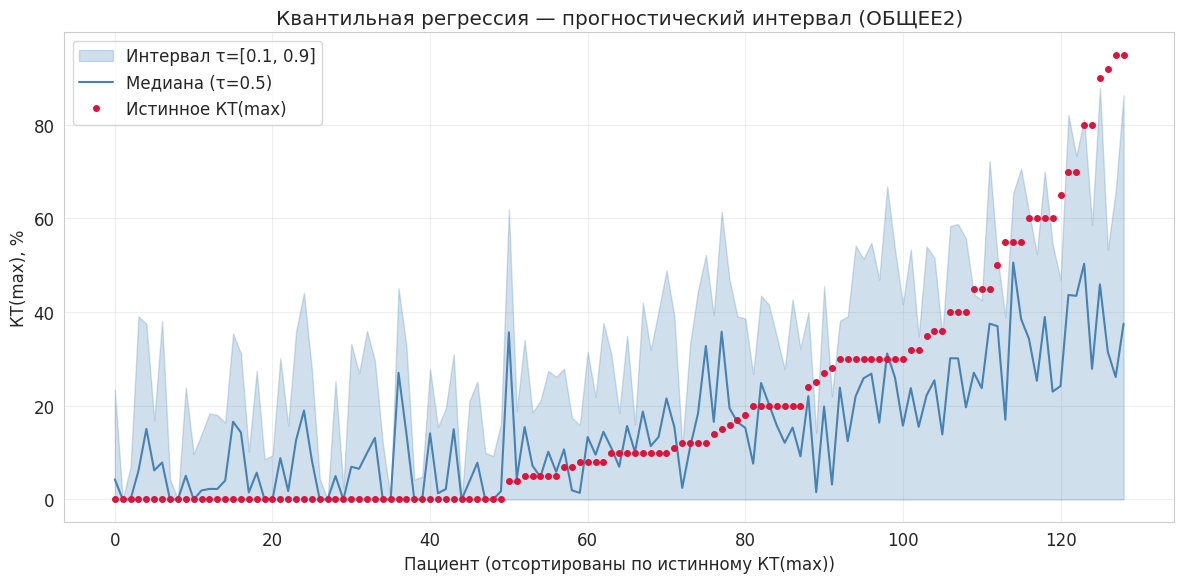


=== Формула верхней границы τ=0.9 (исходные единицы), топ-7 ===
КТ(max, τ=0.9) ≈ -342.85
             + 7.8288 · темпер
             + 5.2974 · ЖКТ
             + 3.4095 · Орг. Дых
             + 3.4007 · HOMA
             - 2.5685 · вакцинация
             - 0.5647 · группа крови
             + 0.4858 · ХГ


In [47]:
from sklearn.linear_model import QuantileRegressor

quantiles = [0.1, 0.5, 0.9]
qr_models = {}
qr_preds = {}

for tau in quantiles:
    qr = QuantileRegressor(quantile=tau, alpha=0.01, solver='highs')
    qr.fit(X_train_z, y_train)
    qr_models[tau] = qr
    qr_preds[tau] = np.clip(qr.predict(X_test_z), 0, 100)

# Метрики
print('Квантильная регрессия:')
for tau in quantiles:
    yp = qr_preds[tau]
    r2_q = r2_score(y_test, yp)
    mae_q = mean_absolute_error(y_test, yp)
    coverage = ((y_test.values <= yp).mean()) if tau >= 0.5 else ((y_test.values >= yp).mean())
    print(f'  τ={tau}: R²={r2_q:.3f}, MAE={mae_q:.2f}%, доля под кривой={coverage:.2f}')

# Точность КТ-категорий по τ=0.9 (как «прогноз тяжести»)
y_pred_q90_aligned = pd.Series(qr_preds[0.9], index=y_test.index).loc[common_idx].values
y_pred_q90_cat = kt_max_to_category(y_pred_q90_aligned)
acc_q90_cat = accuracy_score(y_test_cat_aligned, y_pred_q90_cat)
f1_q90_macro = f1_score(y_test_cat_aligned, y_pred_q90_cat, average='macro', zero_division=0)
print(f'\nКатегоризация τ=0.9 vs реальная КТ(ИТОГ):')
print(f'  Accuracy: {acc_q90_cat:.3f}')
print(f'  Macro-F1: {f1_q90_macro:.3f}')

# Визуализация прогностического интервала
order = np.argsort(y_test.values)
fig, ax = plt.subplots(figsize=(12, 6))
x_idx = np.arange(len(y_test))
ax.fill_between(x_idx,
                qr_preds[0.1][order],
                qr_preds[0.9][order],
                alpha=0.25, color='steelblue', label='Интервал τ=[0.1, 0.9]')
ax.plot(x_idx, qr_preds[0.5][order], '-', color='steelblue', lw=1.5, label='Медиана (τ=0.5)')
ax.plot(x_idx, y_test.values[order], 'o', color='crimson', ms=4, label='Истинное КТ(max)')
ax.set_xlabel('Пациент (отсортированы по истинному КТ(max))')
ax.set_ylabel('КТ(max), %')
ax.set_title(f'Квантильная регрессия — прогностический интервал ({TARGET_SHEET})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Формула для τ=0.9 в исходных единицах
real_coefs_q90 = qr_models[0.9].coef_ / scaler.scale_
real_intercept_q90 = qr_models[0.9].intercept_ - np.sum(qr_models[0.9].coef_ * scaler.mean_ / scaler.scale_)
print(f'\n=== Формула верхней границы τ=0.9 (исходные единицы), топ-7 ===')
top_q90 = pd.Series(real_coefs_q90, index=X_train.columns).sort_values(key=abs, ascending=False).head(7)
print(f'КТ(max, τ=0.9) ≈ {real_intercept_q90:.2f}')
for f, c in top_q90.items():
    sign = '+' if c >= 0 else '-'
    print(f'             {sign} {abs(c):.4f} · {f}')

### 12.9 Комбинированная формула: log + sample_weight + квантиль

Объединяем три приёма: log-преобразование скошенных лабораторных показателей, sample weights для редких категорий, и параллельно квантильную регрессию для верхней границы. Это итоговая клинически применимая модель.

=== Комбинированная Ridge (log + sample_weight) ===
  alpha: 100.0
  R²: 0.566, MAE: 12.15%
  Acc категорий: 0.345, Macro-F1: 0.288

=== Формула 12.9 (log + веса, стандартизованные признаки) ===
КТ(max) = 24.52
         + 8.030 · z(log(1 + HOMA))
         + 6.135 · z(темпер)
         + 5.883 · z(ЧСС (пост))
         + 3.628 · z(ЖКТ)
         - 3.002 · z(группа крови)
         + 2.413 · z(возраст)
         + 1.973 · z(АД(диас))
         + 1.789 · z(АД(сис))
         - 1.589 · z(вакцинация)
         - 1.271 · z(log(1 + А/Т IgG))
         - 0.843 · z(ХПН)
         - 0.808 · z(пол)
         - 0.784 · z(СД)
         + 0.738 · z(Орг. Дых)
         - 0.729 · z(ИМТ)
         - 0.232 · z(ХГ)
         + 0.153 · z(день заболевания)
где z(·) = (· - mean) / std (по train)

=== Формула 12.9 (исходные единицы) ===
КТ(max) = -320.59
         + 18.6069 · log(1 + HOMA)
         + 7.3294 · ЖКТ
         + 7.1952 · темпер
         - 5.8314 · ХПН
         + 3.3122 · Орг. Дых
         - 3.3038 · вакцинация
 

,Базовая Ridge,12.6 +log,12.7 +веса,12.8 квантиль τ=0.9,12.9 log+веса,12.9 log+веса+τ=0.9,12.9 упрощённая (5 призн.)
R²,0.567,0.573,0.530,0.165,0.566,-0.505,0.561
MAE (%),10.665,10.568,12.888,18.545,12.148,25.567,12.235
Точность категорий,0.483,0.448,0.345,0.241,0.345,0.103,0.345
Macro-F1,0.275,0.253,0.304,0.395,0.288,0.147,0.289


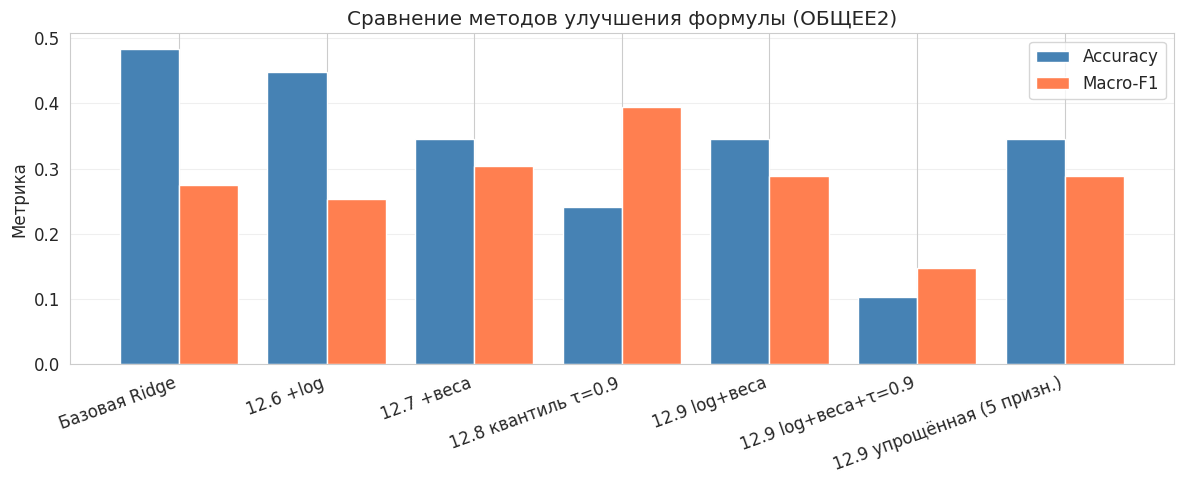


Лучшая формула 12.9 по Macro-F1: 12.9 упрощённая (5 призн.)
  Accuracy: 0.345, Macro-F1: 0.289


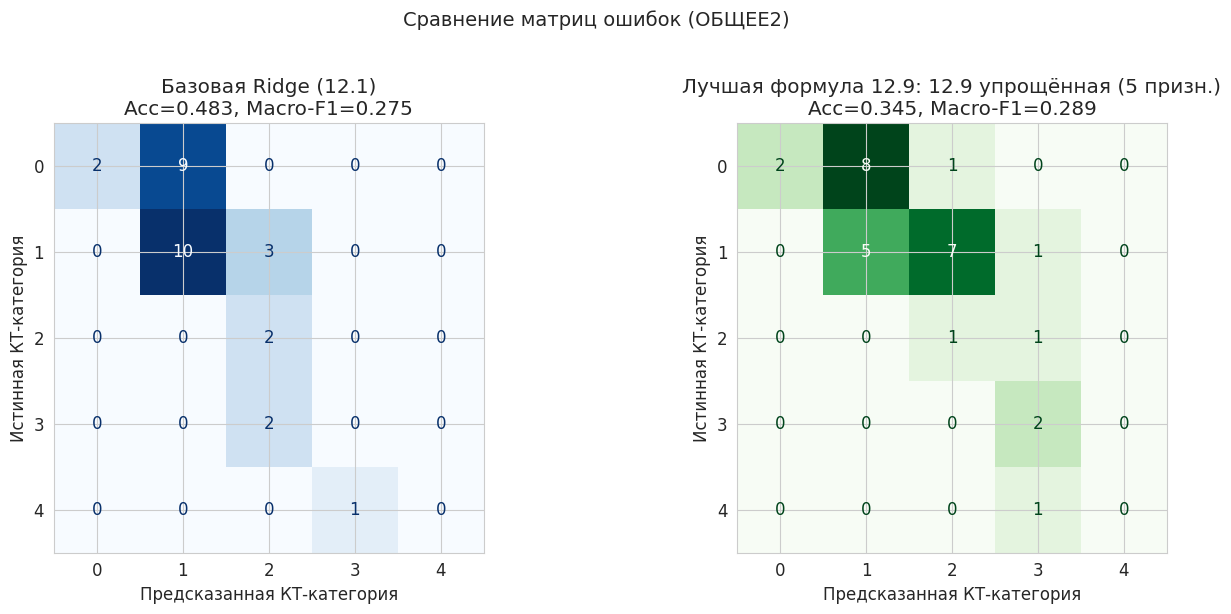


Classification report (12.9 упрощённая (5 призн.)):
              precision    recall  f1-score   support

           0       1.00      0.18      0.31        11
           1       0.38      0.38      0.38        13
           2       0.11      0.50      0.18         2
           3       0.40      1.00      0.57         2
           4       0.00      0.00      0.00         1

    accuracy                           0.34        29
   macro avg       0.38      0.41      0.29        29
weighted avg       0.59      0.34      0.34        29



In [48]:
# Комбинация: log-features + sample_weight
ridge_combo = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_combo.fit(X_train_log_z, y_train, sample_weight=sample_weights)
y_pred_combo = np.clip(ridge_combo.predict(X_test_log_z), 0, 100)

r2_combo = r2_score(y_test, y_pred_combo)
mae_combo = mean_absolute_error(y_test, y_pred_combo)

y_pred_combo_aligned = pd.Series(y_pred_combo, index=y_test.index).loc[common_idx].values
y_pred_combo_cat = kt_max_to_category(y_pred_combo_aligned)
acc_combo_cat = accuracy_score(y_test_cat_aligned, y_pred_combo_cat)
f1_combo_macro = f1_score(y_test_cat_aligned, y_pred_combo_cat, average='macro', zero_division=0)

# Параллельно — квантильная τ=0.9 на log-признаках с весами
qr90_combo = QuantileRegressor(quantile=0.9, alpha=0.01, solver='highs')
qr90_combo.fit(X_train_log_z, y_train, sample_weight=sample_weights)
y_pred_q90_combo = np.clip(qr90_combo.predict(X_test_log_z), 0, 100)
y_pred_q90_combo_aligned = pd.Series(y_pred_q90_combo, index=y_test.index).loc[common_idx].values
y_pred_q90_combo_cat = kt_max_to_category(y_pred_q90_combo_aligned)
acc_q90_combo_cat = accuracy_score(y_test_cat_aligned, y_pred_q90_combo_cat)
f1_q90_combo_macro = f1_score(y_test_cat_aligned, y_pred_q90_combo_cat, average='macro', zero_division=0)

print('=== Комбинированная Ridge (log + sample_weight) ===')
print(f'  alpha: {ridge_combo.alpha_}')
print(f'  R²: {r2_combo:.3f}, MAE: {mae_combo:.2f}%')
print(f'  Acc категорий: {acc_combo_cat:.3f}, Macro-F1: {f1_combo_macro:.3f}')

# === Полная формула 12.9 в стандартизованных признаках ===
print(f'\n=== Формула 12.9 (log + веса, стандартизованные признаки) ===')
print(f'КТ(max) = {ridge_combo.intercept_:.2f}')
for feat, coef in sorted(zip(X_train_log.columns, ridge_combo.coef_), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    wrap = f'log(1 + {feat})' if feat in log_features else feat
    print(f'         {sign} {abs(coef):.3f} · z({wrap})')
print(f'где z(·) = (· - mean) / std (по train)')

# === Формула в исходных единицах ===
real_coefs_combo = ridge_combo.coef_ / scaler_log.scale_
real_intercept_combo = ridge_combo.intercept_ - np.sum(ridge_combo.coef_ * scaler_log.mean_ / scaler_log.scale_)

print(f'\n=== Формула 12.9 (исходные единицы) ===')
print(f'КТ(max) = {real_intercept_combo:.2f}')
for feat, coef in sorted(zip(X_train_log.columns, real_coefs_combo), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    if feat in log_features:
        print(f'         {sign} {abs(coef):.4f} · log(1 + {feat})')
    else:
        print(f'         {sign} {abs(coef):.4f} · {feat}')

# === Упрощённая формула 12.9 — топ-5 признаков по |стандарт. коэф.| ===
top5_combo = pd.Series(ridge_combo.coef_, index=X_train_log.columns).sort_values(key=abs, ascending=False).head(5).index.tolist()
print(f'\n=== Упрощённая формула 12.9 — топ-5 признаков ===')
print(f'(топ-5 по |стандартизованному коэф.|: {top5_combo})')
X_train_simple = X_train_log[top5_combo]
X_test_simple = X_test_log[top5_combo]
sc5 = StandardScaler()
X_train_simple_z = sc5.fit_transform(X_train_simple)
X_test_simple_z = sc5.transform(X_test_simple)
ridge_simple_combo = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_simple_combo.fit(X_train_simple_z, y_train, sample_weight=sample_weights)
y_pred_simple_combo = np.clip(ridge_simple_combo.predict(X_test_simple_z), 0, 100)
r2_sc = r2_score(y_test, y_pred_simple_combo)
mae_sc = mean_absolute_error(y_test, y_pred_simple_combo)
y_pred_sc_aligned = pd.Series(y_pred_simple_combo, index=y_test.index).loc[common_idx].values
y_pred_sc_cat = kt_max_to_category(y_pred_sc_aligned)
acc_sc = accuracy_score(y_test_cat_aligned, y_pred_sc_cat)
f1_sc = f1_score(y_test_cat_aligned, y_pred_sc_cat, average='macro', zero_division=0)

real_coefs_sc = ridge_simple_combo.coef_ / sc5.scale_
real_intercept_sc = ridge_simple_combo.intercept_ - np.sum(ridge_simple_combo.coef_ * sc5.mean_ / sc5.scale_)
print(f'КТ(max) ≈ {real_intercept_sc:.2f}')
for feat, coef in sorted(zip(top5_combo, real_coefs_sc), key=lambda x: -abs(x[1])):
    sign = '+' if coef >= 0 else '-'
    if feat in log_features:
        print(f'           {sign} {abs(coef):.3f} · log(1 + {feat})')
    else:
        print(f'           {sign} {abs(coef):.3f} · {feat}')
print(f'\nR²: {r2_sc:.3f}, MAE: {mae_sc:.2f}%, Acc: {acc_sc:.3f}, Macro-F1: {f1_sc:.3f}')

print('\n=== Comparison: все варианты ===')
comparison = pd.DataFrame({
    'Базовая Ridge': [r2, mae, acc_cat,
                       f1_score(y_test_cat_aligned, kt_max_to_category(pd.Series(y_pred, index=y_test.index).loc[common_idx].values), average='macro', zero_division=0)],
    '12.6 +log': [r2_log, mae_log, acc_log_cat, f1_log_macro],
    '12.7 +веса': [r2_w, mae_w, acc_w_cat, f1_w_macro],
    '12.8 квантиль τ=0.9': [r2_score(y_test, qr_preds[0.9]), mean_absolute_error(y_test, qr_preds[0.9]), acc_q90_cat, f1_q90_macro],
    '12.9 log+веса': [r2_combo, mae_combo, acc_combo_cat, f1_combo_macro],
    '12.9 log+веса+τ=0.9': [r2_score(y_test, y_pred_q90_combo), mean_absolute_error(y_test, y_pred_q90_combo), acc_q90_combo_cat, f1_q90_combo_macro],
    '12.9 упрощённая (5 призн.)': [r2_sc, mae_sc, acc_sc, f1_sc],
}, index=['R²', 'MAE (%)', 'Точность категорий', 'Macro-F1']).round(3)
display(comparison)

# Сравнительная гистограмма
fig, ax = plt.subplots(figsize=(12, 5))
methods = list(comparison.columns)
f1_vals = comparison.loc['Macro-F1'].values
acc_vals = comparison.loc['Точность категорий'].values
xpos = np.arange(len(methods))
w = 0.4
ax.bar(xpos - w/2, acc_vals, w, label='Accuracy', color='steelblue')
ax.bar(xpos + w/2, f1_vals, w, label='Macro-F1', color='coral')
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=20, ha='right')
ax.set_ylabel('Метрика')
ax.set_title(f'Сравнение методов улучшения формулы ({TARGET_SHEET})')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# === Матрицы ошибок: базовая vs лучшая формула 12.9 ===
y_pred_base_aligned = pd.Series(y_pred, index=y_test.index).loc[common_idx].values
y_pred_base_cat = kt_max_to_category(y_pred_base_aligned)

# Выбор лучшего варианта 12.9 по Macro-F1
candidates = {
    '12.9 log + веса':       (y_pred_combo_cat, acc_combo_cat, f1_combo_macro),
    '12.9 log + веса + τ=0.9': (y_pred_q90_combo_cat, acc_q90_combo_cat, f1_q90_combo_macro),
    '12.9 упрощённая (5 призн.)': (y_pred_sc_cat, acc_sc, f1_sc),
}
best_name = max(candidates, key=lambda k: candidates[k][2])
best_pred_cat, best_acc, best_f1 = candidates[best_name]
print(f'\nЛучшая формула 12.9 по Macro-F1: {best_name}')
print(f'  Accuracy: {best_acc:.3f}, Macro-F1: {best_f1:.3f}')

# Базовая Ridge (12.1) для сравнения
acc_base = accuracy_score(y_test_cat_aligned, y_pred_base_cat)
f1_base = f1_score(y_test_cat_aligned, y_pred_base_cat, average='macro', zero_division=0)

all_labels = sorted(set(y_test_cat_aligned.unique()) | set(np.unique(y_pred_base_cat)) | set(np.unique(best_pred_cat)))
cm_base = confusion_matrix(y_test_cat_aligned, y_pred_base_cat, labels=all_labels)
cm_best = confusion_matrix(y_test_cat_aligned, best_pred_cat, labels=all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(cm_base, display_labels=all_labels).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Базовая Ridge (12.1)\nAcc={acc_base:.3f}, Macro-F1={f1_base:.3f}')
ConfusionMatrixDisplay(cm_best, display_labels=all_labels).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Лучшая формула 12.9: {best_name}\nAcc={best_acc:.3f}, Macro-F1={best_f1:.3f}')
for ax in axes:
    ax.set_xlabel('Предсказанная КТ-категория')
    ax.set_ylabel('Истинная КТ-категория')
plt.suptitle(f'Сравнение матриц ошибок ({TARGET_SHEET})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nClassification report ({best_name}):')
print(classification_report(y_test_cat_aligned, best_pred_cat, zero_division=0))

## 13. Выводы

In [49]:
# Итоговые выводы
print('=' * 70)
print('  ИТОГОВЫЕ ВЫВОДЫ')
print('=' * 70)

# Лучшая модель по каждому штамму
print('\n1. Лучшая модель по Accuracy для каждого штамма:')
for name in SHEET_NAMES:
    subset = all_results_df[all_results_df['Штамм'] == name]
    best = subset.loc[subset['Accuracy (test)'].idxmax()]
    print(f"   {name:>10s}: {best['Модель']} (Accuracy={best['Accuracy (test)']:.4f}, "
          f"F1w={best['F1 test (weighted)']:.4f})")

# Лучшая модель в среднем
print('\n2. Средние метрики по всем штаммам:')
avg = all_results_df.groupby('Модель')[['Accuracy (test)', 'F1 test (weighted)', 'F1 test (macro)']].mean()
display(avg.round(4).sort_values('F1 test (weighted)', ascending=False))

# Топ-5 признаков по консенсус permutation importance
print('\n3. Топ-5 признаков по консенсус permutation importance (LR + RF + GB):')
overall_consensus = consensus_imp.mean(axis=1).sort_values(ascending=False)
for feat, val in overall_consensus.head(5).items():
    print(f'   {feat}: {val:.4f}')

# Топ-3 признака по штаммам
print('\n4. Топ-3 признаков по консенсус-важности для каждого штамма:')
for name in SHEET_NAMES:
    top3 = consensus_imp[name].sort_values(ascending=False).head(3)
    features_str = ', '.join([f'{feat} ({val:.3f})' for feat, val in top3.items()])
    print(f'   {name:>10s}: {features_str}')

  ИТОГОВЫЕ ВЫВОДЫ

1. Лучшая модель по Accuracy для каждого штамма:
       ОБЩЕЕ2: Random Forest (Accuracy=0.5814, F1w=0.5748)
       УХАНЬ2: Random Forest (Accuracy=0.5581, F1w=0.5645)
      ДЕЛЬТА2: Gradient Boosting (Accuracy=0.4909, F1w=0.4692)
     ОМИКРОН2: Logistic Regression (Accuracy=0.6667, F1w=0.6824)

2. Средние метрики по всем штаммам:


,Accuracy (test),F1 test (weighted),F1 test (macro)
Модель,,,
Random Forest,0.5606,0.5552,0.4270
Logistic Regression,0.5523,0.5526,0.4544
Gradient Boosting,0.5434,0.5447,0.4152
Decision Tree,0.4650,0.4790,0.3390



3. Топ-5 признаков по консенсус permutation importance (LR + RF + GB):
   день заболевания: 0.0377
   HOMA: 0.0351
   ИМТ: 0.0313
   темпер: 0.0304
   ЖКТ: 0.0158

4. Топ-3 признаков по консенсус-важности для каждого штамма:
       ОБЩЕЕ2: день заболевания (0.058), HOMA (0.053), темпер (0.033)
       УХАНЬ2: день заболевания (0.072), темпер (0.053), возраст (0.033)
      ДЕЛЬТА2: день заболевания (0.028), темпер (0.026), АД(сис) (0.026)
     ОМИКРОН2: ИМТ (0.094), HOMA (0.062), ЧСС (пост) (0.058)
